# Automobile Data Analysis and Preprocessing  

---

This notebook is designed to analyze the **1985 Automobile Imports Database**, which consists of various attributes of different car models. We'll load the data, preprocess it, and perform **exploratory data analysis (EDA)** to prepare it for machine learning algorithms. The notebooks takes care of:

1️⃣ **Loading the Data**: We will load the dataset and add appropriate column headers for better readability.  
2️⃣ **Handling Missing Values**: Missing values will be imputed using the **median**, but we can experiment with other techniques such as the **mean** or predictive imputation.  
3️⃣ **Exploratory Data Analysis (EDA)**: Different plots that will give you a solid understanding of the dataset we are dealing with.

💡 Feel free to **experiment with different EDA techniques** and **add more visualizations** :)

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.neighbors import KNeighborsRegressor

import scipy.stats as stats

from sklearn.linear_model import LinearRegression, Ridge

#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_validate

from sklearn.decomposition import PCA

#from skopt import BayesSearchCV

import warnings

import scipy.stats as stats
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor , plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style('whitegrid')  
plt.rcParams['figure.figsize'] = (12, 8)

### Loading the Data

Based on the metadata in `imports-85.names`, we know this dataset has 26 attributes. Let's define the column names and load the data.

In [8]:
# Define column names from the metadata file
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Load the data
data = pd.read_csv('../data/imports-85.data', header=None, names=columns)

# Display first few rows
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [9]:
# Replace '?' with NaN
data = data.replace('?', np.nan)

# Check initial data types
print("Data types before conversion:")
print(data.dtypes)

Data types before conversion:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object


In [10]:
# Count missing values before any processing
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


### Preliminary Data Type Conversions

Before splitting, we need to convert string columns to numeric where appropriate.

In [11]:
# Numeric columns that need to be converted
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check data types after conversion
print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


### Train-Test Split

It's crucial to split the data into training and test sets before performing any further preprocessing or analysis to prevent data leakage.

In [12]:
# Define the target variable (assuming we're predicting price)
X = data.drop('price', axis=1)
y = data['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a full training dataset (including the target variable) for EDA
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (164, 25)
Testing set shape: (41, 25)


_________________

## Data Preprocessing

Now we'll preprocess the data, making sure to fit preprocessing operations only on the training set.

### Handling Missing Values

In [13]:
# Calculate percentage of missing values in training set
missing_percentage = train_data.isnull().sum() / len(train_data) * 100

# Create a dataframe to display columns with missing values
missing_data = pd.DataFrame({'Column': train_data.columns,
                            'Missing Value Count': train_data.isnull().sum(),
                            'Missing Percentage': missing_percentage})

# Sort by percentage of missing values
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)
missing_data = missing_data[missing_data['Missing Value Count'] > 0]
missing_data

,Column,Missing Value Count,Missing Percentage
normalized-losses,normalized-losses,66,33.502538
stroke,stroke,36,18.274112
bore,bore,36,18.274112
price,price,35,17.766497
peak-rpm,peak-rpm,35,17.766497
num-of-doors,num-of-doors,35,17.766497
horsepower,horsepower,35,17.766497
engine-type,engine-type,33,16.751269
highway-mpg,highway-mpg,33,16.751269
city-mpg,city-mpg,33,16.751269


In [14]:
# Create a copy of numeric_cols without 'price' for imputation
# since price is our target variable and has been removed from X_train and X_test
numeric_features_for_imputation = [col for col in numeric_cols if col != 'price']

# Impute missing values based on training data only
# For numeric columns, use median
numeric_imputer = SimpleImputer(strategy='median')

X_train_numeric = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features_for_imputation]),
    columns=numeric_features_for_imputation,
    index=X_train.index
)

# Apply the SAME imputer to test set (using parameters learned from training)
X_test_numeric = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features_for_imputation]), 
    columns=numeric_features_for_imputation, 
    index=X_test.index
)

# For categorical columns with missing values, use most frequent value
cat_cols_with_missing = ['num-of-doors']
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on training data
X_train_cat_missing = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_train.index
)

# Transform test data
X_test_cat_missing = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols_with_missing]), 
    columns=cat_cols_with_missing, 
    index=X_test.index
)

# Update the imputed columns in our datasets
X_train[numeric_features_for_imputation] = X_train_numeric
X_test[numeric_features_for_imputation] = X_test_numeric
X_train[cat_cols_with_missing] = X_train_cat_missing
X_test[cat_cols_with_missing] = X_test_cat_missing

# Update training data for EDA
train_data[numeric_features_for_imputation] = X_train_numeric
train_data[cat_cols_with_missing] = X_train_cat_missing

# Verify no missing values remain
print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

#Dropping the nan rows in the y and the corresponding x
X_train = X_train[y_train.notna()]
y_train = y_train.dropna()

X_test = X_test[y_test.notna()]
y_test = y_test.dropna()

#Final verification

print("Missing values after imputation in training set:", X_train.isnull().sum().sum())
print("Missing values after imputation in test set:", X_test.isnull().sum().sum())
print("Missing values in y_train", y_train.isnull().sum().sum())
print("Missing values in y_test", y_test.isnull().sum().sum())

Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 2
Missing values in y_test 2
Missing values after imputation in training set: 0
Missing values after imputation in test set: 0
Missing values in y_train 0
Missing values in y_test 0


_________

## Exploratory Data Analysis (EDA)

Now we'll perform EDA on the **training data only** to understand the relationships between variables without leaking information from the test set.

### Distribution of Continuous Variables

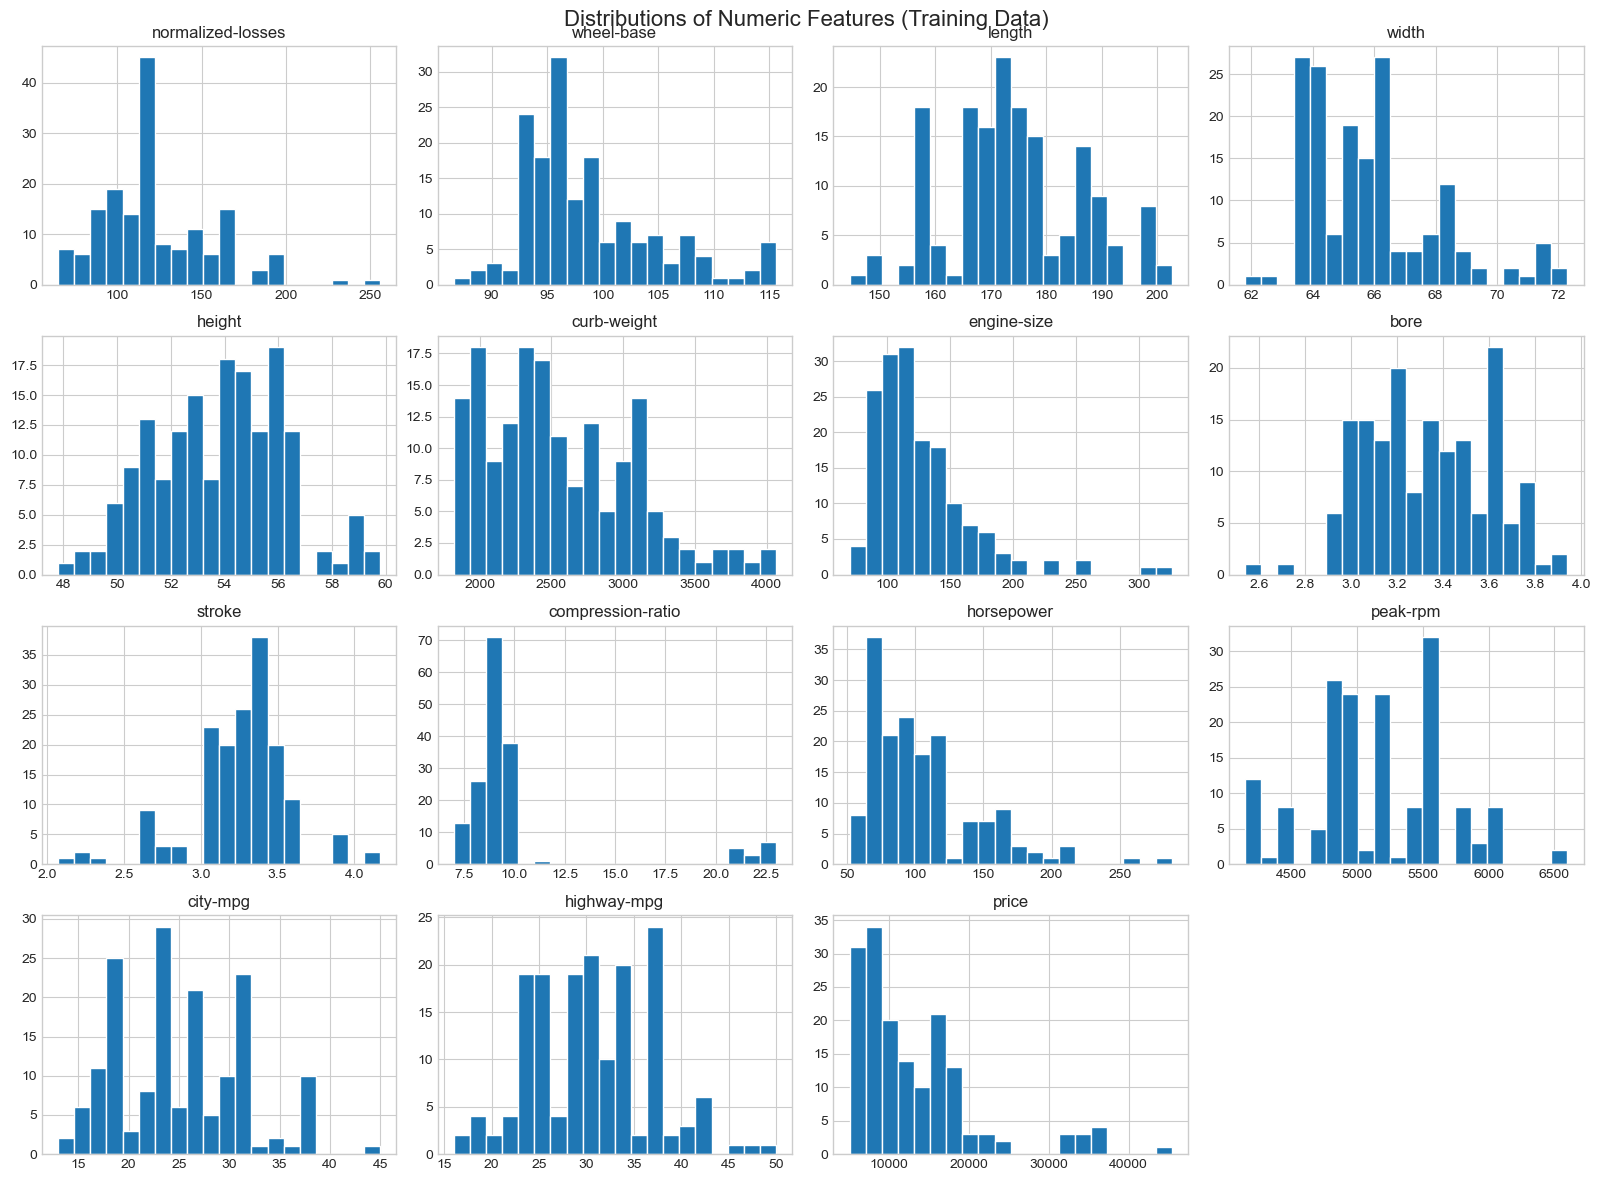

In [15]:
# Use numeric features for imputation plus 'price' for the histograms
numeric_cols_for_eda = numeric_features_for_imputation + ['price']

# Histogram of all numeric variables (training data only)
train_data[numeric_cols_for_eda].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.suptitle("Distributions of Numeric Features (Training Data)", fontsize=16)
plt.subplots_adjust(top=0.95)
plt.show()

### Car Makes Analysis

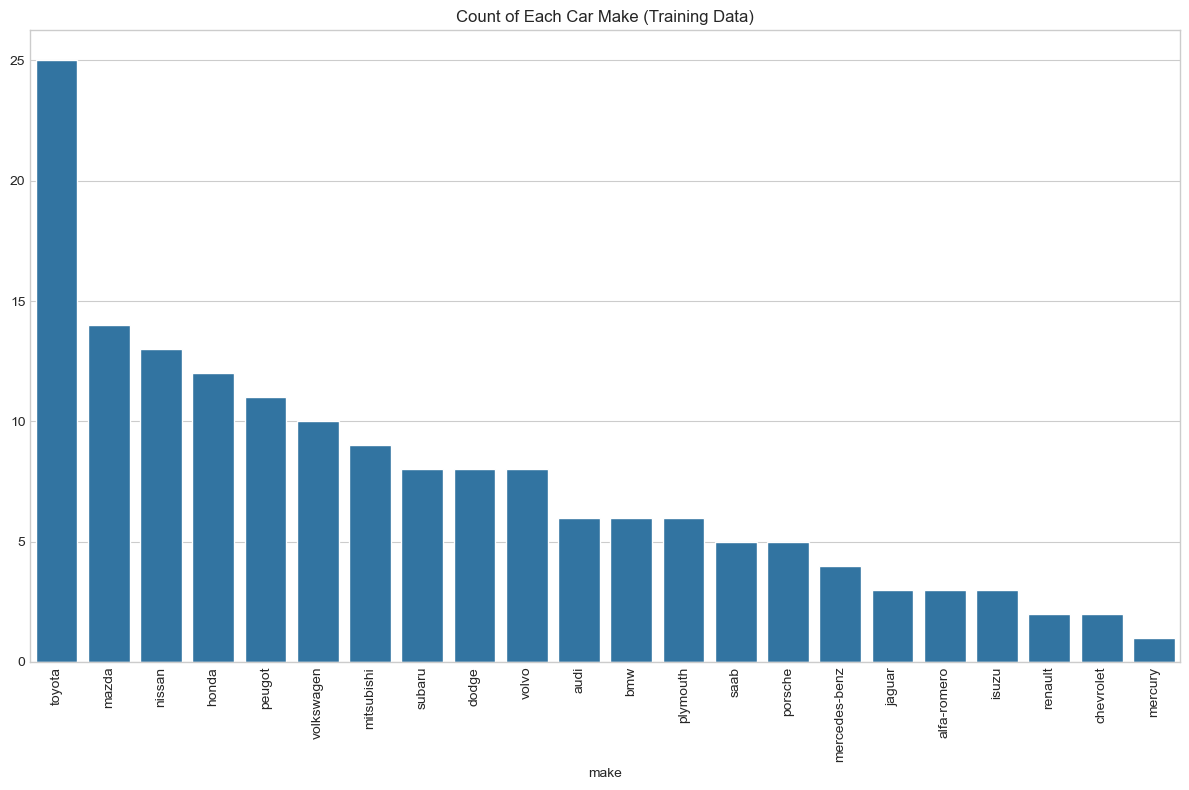

In [16]:
# Count of each car make (training data only)
plt.figure(figsize=(12, 8))
count_make = train_data['make'].value_counts()
sns.barplot(x=count_make.index, y=count_make.values)
plt.title('Count of Each Car Make (Training Data)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

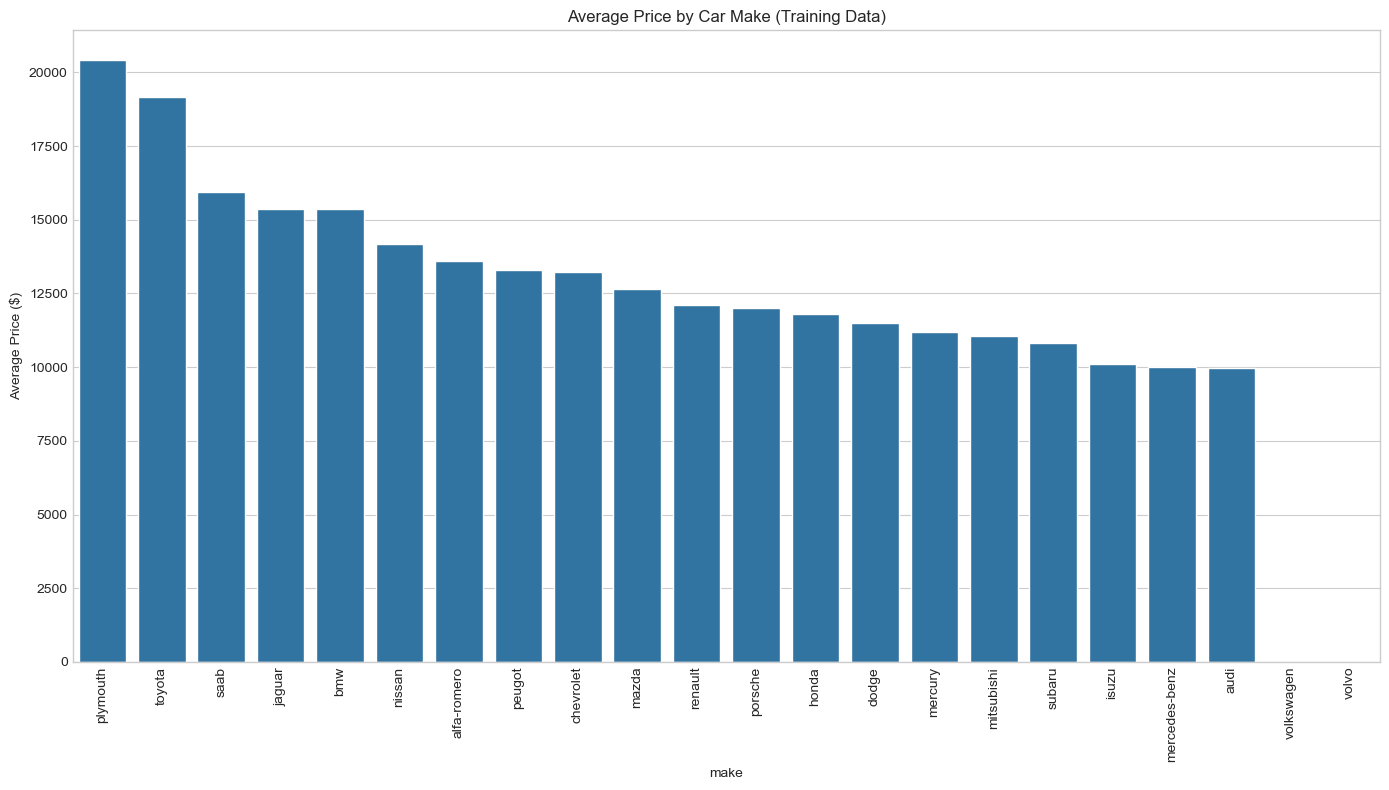

In [17]:
# Average price by make (training data only)
plt.figure(figsize=(14, 8))
avg_price = train_data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Car Make (Training Data)')
plt.xticks(rotation=90)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

### Price Analysis

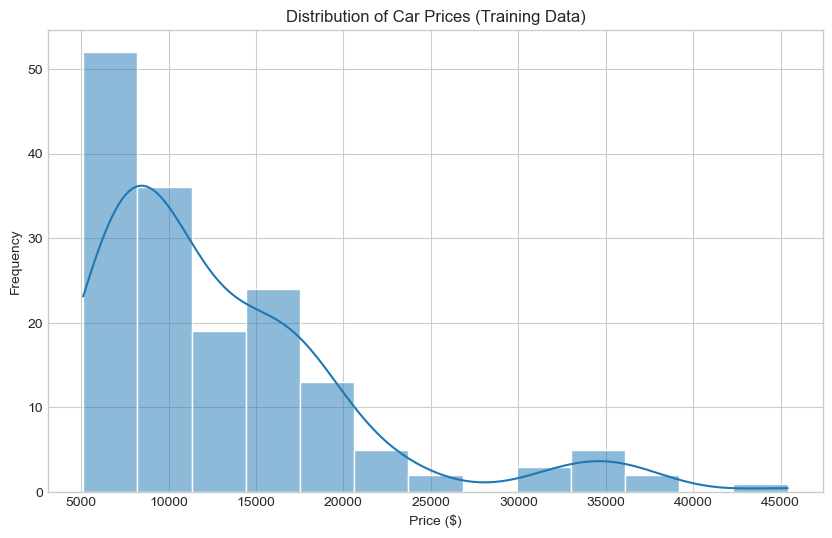

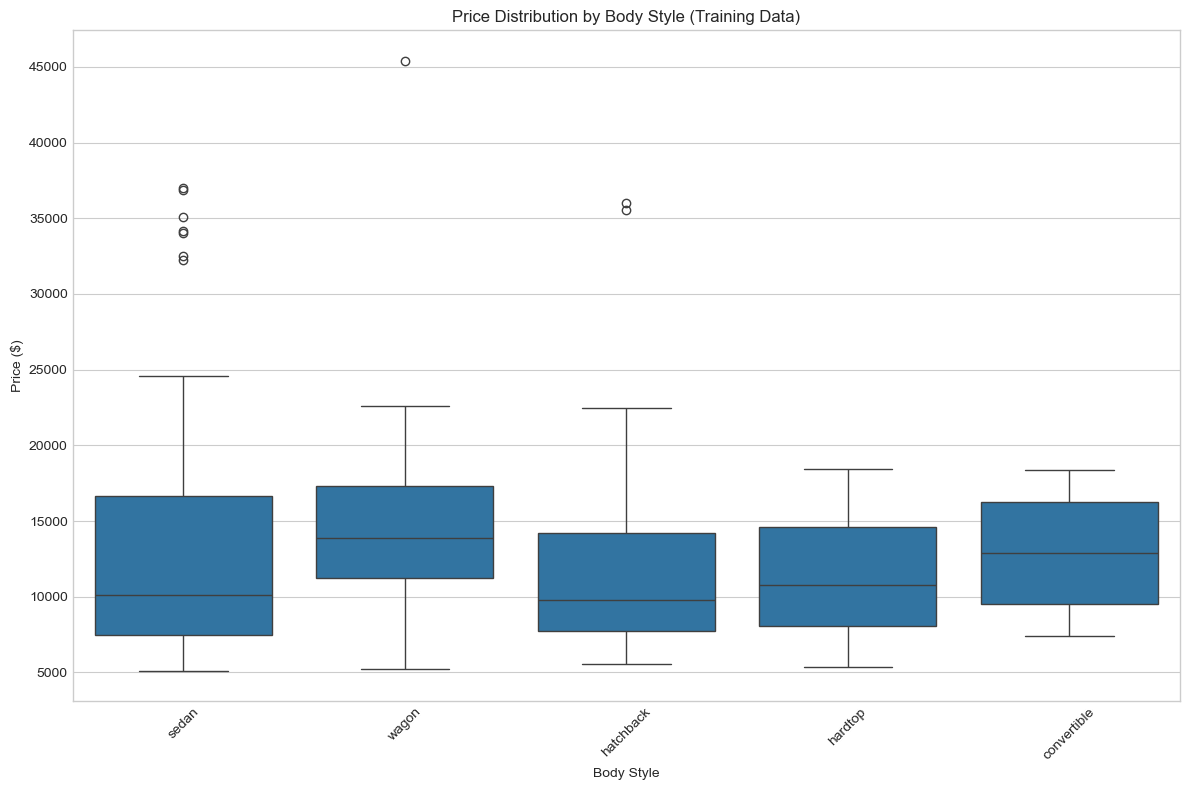

In [18]:
# Distribution of Price (training data only)
plt.figure(figsize=(10, 6))
sns.histplot(train_data['price'], kde=True)
plt.title('Distribution of Car Prices (Training Data)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot of price by body style (training data only)
plt.figure(figsize=(12, 8))
sns.boxplot(x='body-style', y='price', data=train_data)
plt.title('Price Distribution by Body Style (Training Data)')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis

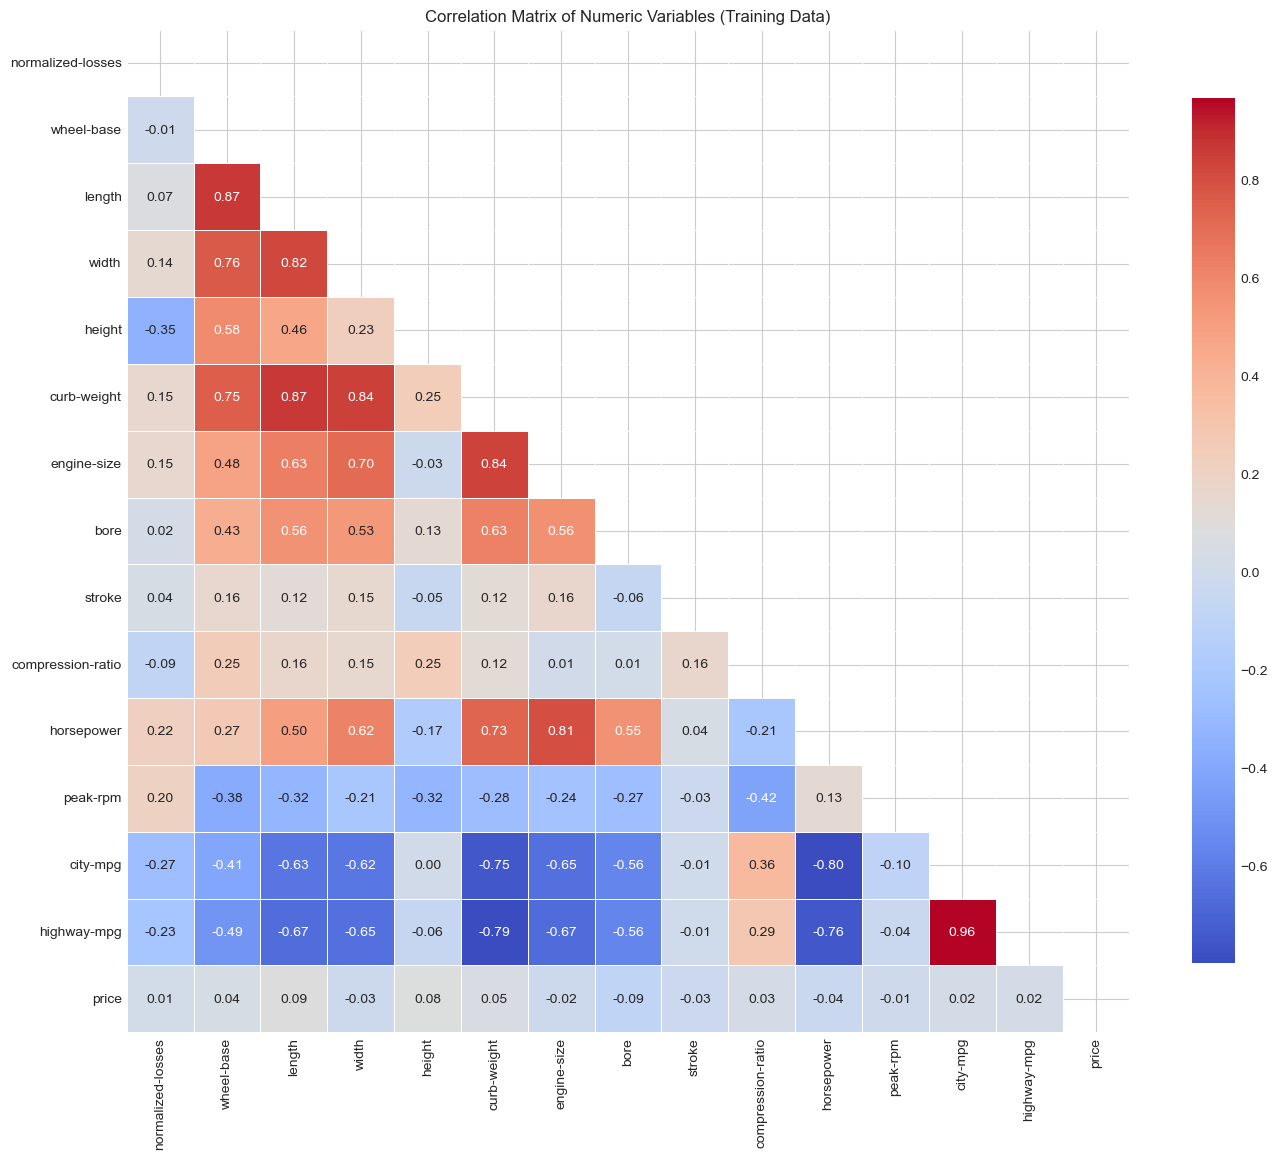

In [ ]:
# Calculate correlation matrix for numeric variables (training data only)
corr_matrix = train_data[numeric_cols_for_eda].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables (Training Data)')
plt.tight_layout()
plt.show()

### Key Feature Relationships

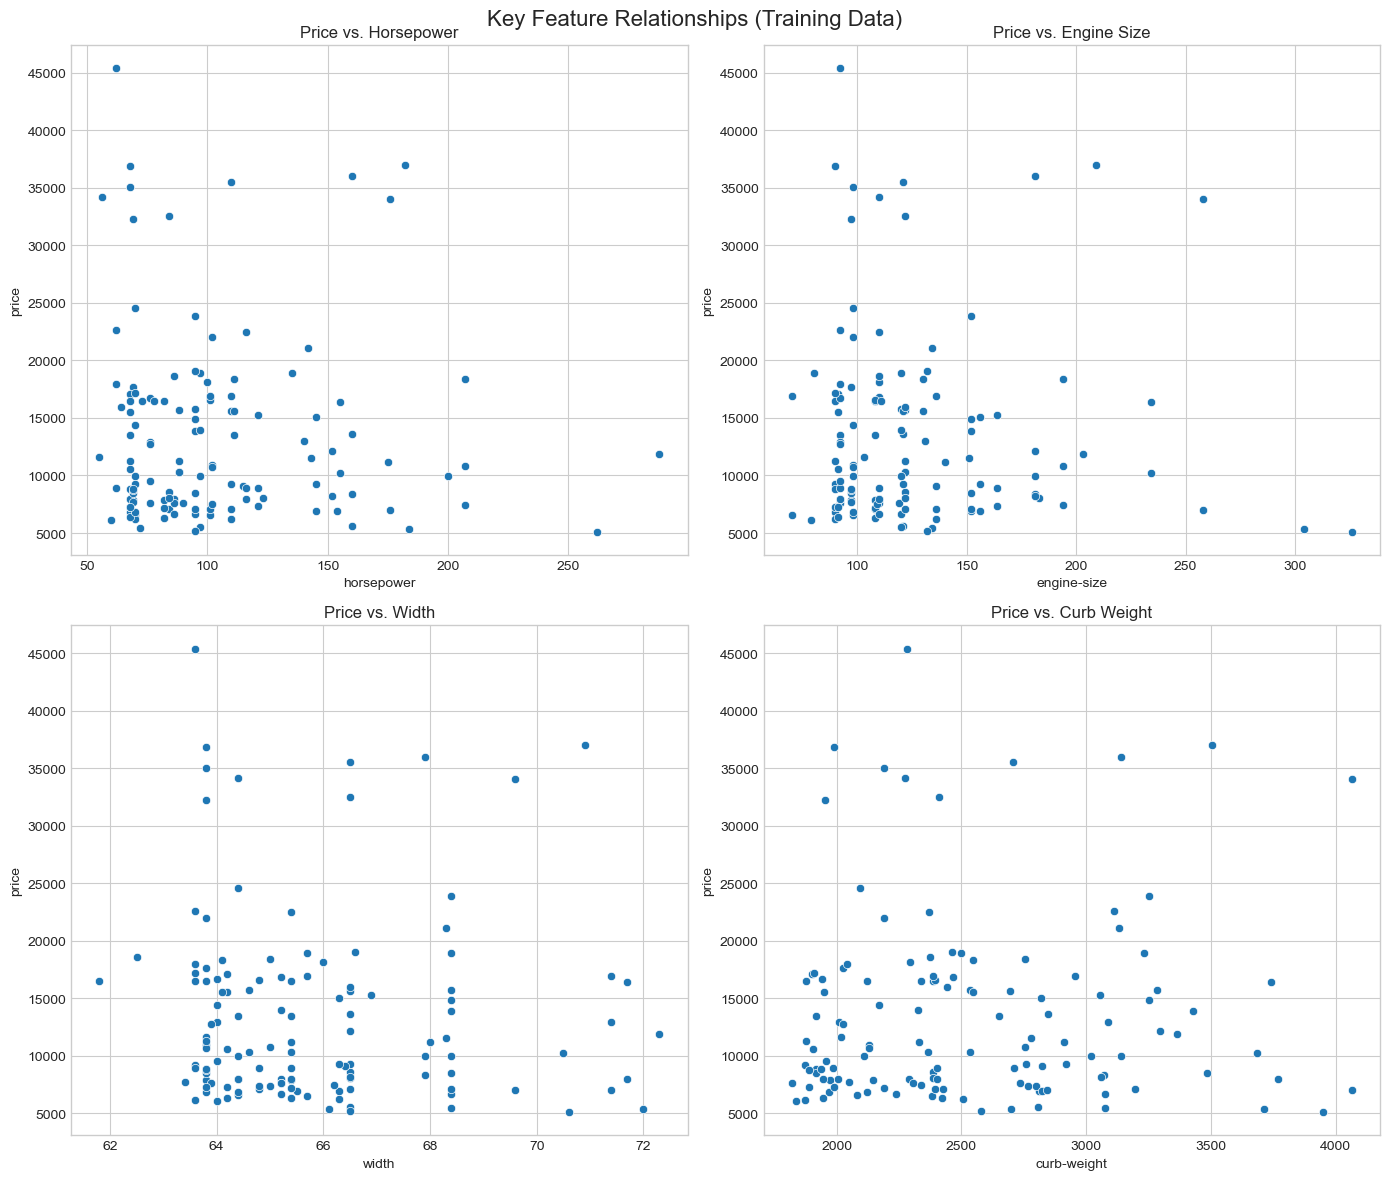

In [19]:
# Scatter plots for key feature relationships (training data only)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Price vs. horsepower
sns.scatterplot(x='horsepower', y='price', data=train_data, ax=axes[0, 0])
axes[0, 0].set_title('Price vs. Horsepower')

# Price vs. engine-size
sns.scatterplot(x='engine-size', y='price', data=train_data, ax=axes[0, 1])
axes[0, 1].set_title('Price vs. Engine Size')

# Price vs. width
sns.scatterplot(x='width', y='price', data=train_data, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Width')

# Price vs. curb-weight
sns.scatterplot(x='curb-weight', y='price', data=train_data, ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Curb Weight')

plt.suptitle("Key Feature Relationships (Training Data)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

### Specific Analysis of Width and Horsepower

Based on the 'misc' file, there seems to be a special interest in the relationship between width and horsepower.

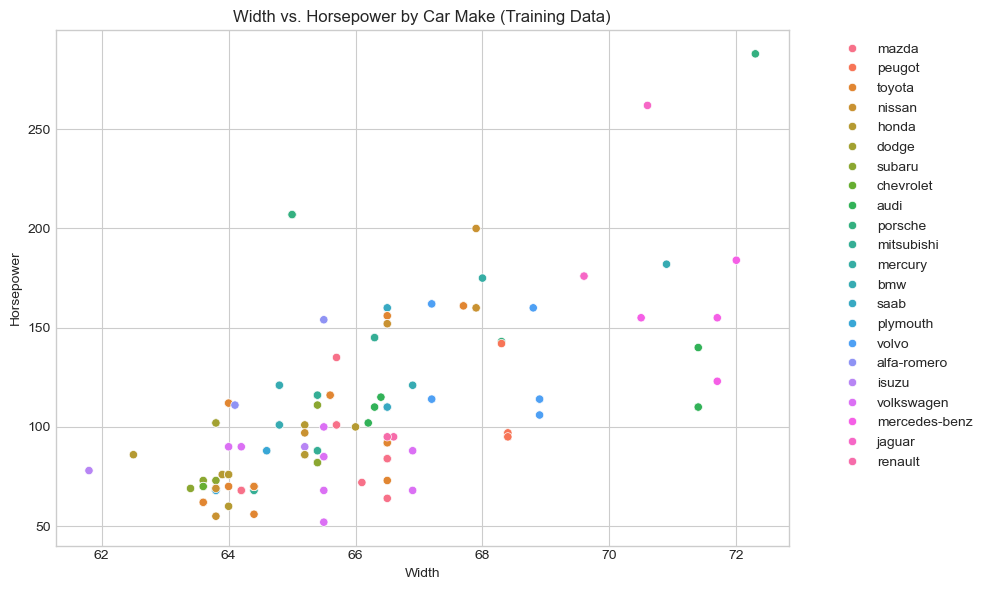

In [20]:
# Scatter plot with width and horsepower (training data only)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='horsepower', data=train_data, hue='make')
plt.title('Width vs. Horsepower by Car Make (Training Data)')
plt.xlabel('Width')
plt.ylabel('Horsepower')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

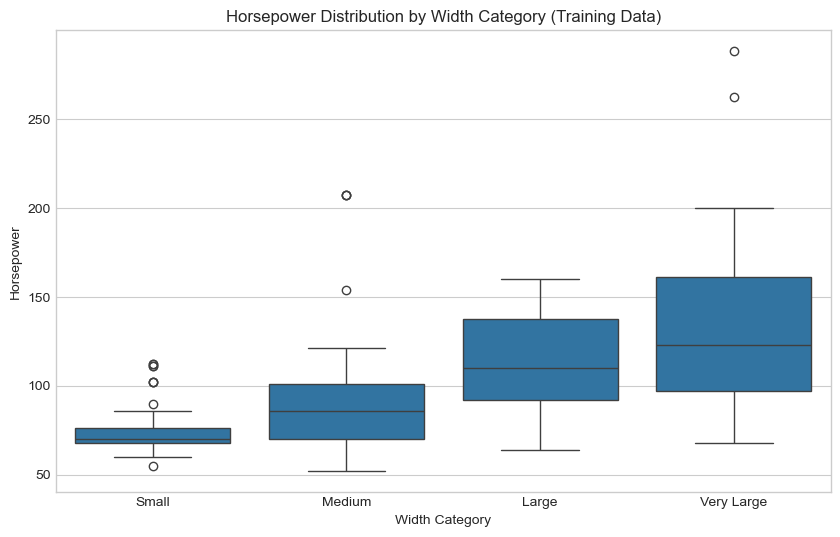

In [21]:
# Compare horsepower across different width ranges (training data only)
train_data['width_category'] = pd.qcut(train_data['width'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='width_category', y='horsepower', data=train_data)
plt.title('Horsepower Distribution by Width Category (Training Data)')
plt.xlabel('Width Category')
plt.ylabel('Horsepower')
plt.show()

## Feature Engineering

We'll create new features based on our understanding of the data, keeping the training/test separation intact.

In [22]:
# Create feature engineering functions to apply to both training and test sets
def engineer_features(df):
    """Apply feature engineering to the dataset"""
    # Create a power-to-weight ratio feature
    df['power_to_weight'] = df['horsepower'] / df['curb-weight']
    
    # Create a feature for engine size per cylinder
    # First, convert num-of-cylinders to numeric
    cylinder_map = {
        'two': 2,
        'three': 3,
        'four': 4,
        'five': 5,
        'six': 6,
        'eight': 8,
        'twelve': 12
    }
    df['num_cylinders'] = df['num-of-cylinders'].map(cylinder_map)
    df['engine_size_per_cylinder'] = df['engine-size'] / df['num_cylinders']
    
    # Create fuel efficiency feature (combined MPG)
    df['combined_mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2
    
    return df

# Apply feature engineering to both sets
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

# Update training data for continued analysis
train_data = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)

# Display new features
train_data[['power_to_weight', 'engine_size_per_cylinder', 'combined_mpg']].describe()

,power_to_weight,engine_size_per_cylinder,combined_mpg
count,162.000000,162.000000,162.000000
mean,0.040079,28.794856,27.777778
std,0.009358,4.934102,6.188800
min,0.019936,19.750000,15.000000
25%,0.034346,24.500000,22.125000
50%,0.037961,27.500000,27.000000
75%,0.043848,30.500000,32.000000
max,0.075109,43.000000,47.500000


## Preparing for Machine Learning

Now we'll prepare our data for machine learning by encoding categorical variables and scaling numeric features, maintaining our train/test separation.

In [24]:
# Identify feature types
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Remove width_category created during EDA if it exists
if 'width_category' in X_train.columns:
    X_train = X_train.drop('width_category', axis=1)
if 'width_category' in X_test.columns:
    X_test = X_test.drop('width_category', axis=1)

# Update feature lists if needed
if 'width_category' in numeric_features:
    numeric_features.remove('width_category')
if 'width_category' in categorical_features:
    categorical_features.remove('width_category')

In [25]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', pd.get_dummies)
])

# Apply one-hot encoding to categorical features
X_train_cat = pd.get_dummies(X_train[categorical_features], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_features], drop_first=True)

# Ensure test set has the same columns as train set
missing_cols = set(X_train_cat.columns) - set(X_test_cat.columns)
for col in missing_cols:
    X_test_cat[col] = 0
X_test_cat = X_test_cat[X_train_cat.columns]

# Scale numeric features
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), 
                         columns=numeric_features, 
                         index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[numeric_features]), 
                        columns=numeric_features, 
                        index=X_test.index)


# Scale target variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))



# Convert scaled y values back to pandas Series/DataFrame for consistency
y_train_scaled = pd.DataFrame(y_train_scaled, index=y_train.index, columns=['price'])
y_test_scaled = pd.DataFrame(y_test_scaled, index=y_test.index, columns=['price'])

# Combine processed features
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

Processed training data shape: (162, 67)
Processed test data shape: (39, 67)


In [26]:
# View sample of processed data
X_train_processed.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
66,-0.721994,-0.145503,1.027648,0.063977,0.098189,0.264626,0.284858,0.195626,0.420606,1.201459,...,False,False,False,False,False,True,False,False,False,False
111,-0.721994,1.155615,1.529494,1.036401,1.213595,1.195688,1.024898,-0.154003,0.533730,-3.351254,...,False,False,False,False,False,False,False,True,False,False
153,-0.721994,-1.386103,-0.511346,-0.376523,-1.114208,2.167232,-0.543987,-0.853261,-1.012294,-0.713820,...,False,False,False,True,False,False,False,False,False,False
96,0.079123,-0.024468,-0.712084,-0.742222,-1.017216,0.305107,-1.153780,-0.728394,-0.635215,0.102528,...,False,False,False,True,False,False,False,False,False,False
38,-0.721994,-0.508605,-0.377520,-0.559373,-0.338274,-0.180665,-0.526226,-0.403738,-0.635215,1.013071,...,False,False,False,False,False,False,False,False,False,False


Non scalled data

In [27]:
X_train_processed_not_stand = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
X_test_processed_not_stand = pd.concat([X_test[numeric_features], X_test_cat], axis=1)

X_test_processed_not_stand.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_six,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
15,0,118.0,103.5,189.0,66.9,55.7,3230.0,209.0,3.62,3.39,...,True,0,False,False,False,False,0,True,False,0
100,0,106.0,97.2,173.4,65.2,54.7,2302.0,120.0,3.33,3.47,...,False,0,False,True,False,False,0,False,False,0
132,3,150.0,99.1,186.6,66.5,56.1,2658.0,121.0,3.54,3.07,...,False,0,False,False,False,False,0,True,False,0
68,-1,93.0,110.0,190.9,70.3,58.7,3750.0,183.0,3.58,3.64,...,False,0,False,False,False,True,0,False,False,0
95,1,128.0,94.5,165.6,63.8,53.3,2028.0,97.0,3.15,3.29,...,False,0,False,True,False,False,0,False,False,0


___________________

# Training the models

#### Preparing the data

In [28]:
#The no
X_train_original_scale = X_train_processed_not_stand.reset_index(drop=True)
y_train_original_scale = y_train.reset_index(drop=True)

X_test_original_scale = X_test_processed_not_stand.reset_index(drop=True)
y_test_original_scale = y_test.reset_index(drop=True)

print(y_test_original_scale)

X_train = X_train_processed.reset_index(drop=True)
y_train = y_train_scaled.reset_index(drop=True)

X_test = X_test_processed.reset_index(drop=True)
y_test = y_test_scaled.reset_index(drop=True)

0     30760.0
1      9549.0
2     11850.0
3     28248.0
4      7799.0
5      7788.0
6      9258.0
7     10198.0
8      7775.0
9     13295.0
10     8238.0
11    18280.0
12     9988.0
13    40960.0
14     6488.0
15     5151.0
16    12629.0
17     8189.0
18     9960.0
19     8495.0
20    13499.0
21     8249.0
22     6479.0
23     6692.0
24    41315.0
25     9639.0
26    13415.0
27     7999.0
28    12940.0
29    25552.0
30     6229.0
31     7898.0
32    21485.0
33     7689.0
34    28176.0
35    11259.0
36    10945.0
37    14489.0
38     7463.0
Name: price, dtype: float64


#### Utility functions

In [29]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [31]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [32]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [33]:
def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.grid(True)
    plt.show()


In [34]:
from tabulate import tabulate

def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_  
    feature_importance = pd.DataFrame({
        "Feature": feature_names, 
        "Importance (%)": importance * 100 
    })
    feature_importance = feature_importance.sort_values(by="Importance (%)", ascending=False)
    print(tabulate(feature_importance, headers="keys", tablefmt="fancy_grid", showindex=False))
    # get features with importance > 0%
    important_features = feature_importance[feature_importance["Importance (%)"] >0]
    plt.figure(figsize=(10, 12))  
    sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")
    
    #  percentage labels
    for index, value in enumerate(feature_importance["Importance (%)"]):
        plt.text(value + 0.5, index, f"{value:.2f}%", va="center")

    plt.title("Feature Importance (%)")
    plt.xlabel("Importance (%)")
    plt.ylabel("Feature Name")
    plt.show()

    return important_features["Feature"].tolist() 


In [35]:
def plot_residuals(y_true, y_predicted, model_name):
    
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.squeeze()  # convert to Series if it's a DataFrame

    # compute residuals
    residuals = y_true - y_predicted

    # plot residuals
    plt.figure(figsize=(10, 10))
    plt.scatter(y_predicted, residuals, color="purple", alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (Errors)")
    plt.title(f"{model_name} - Residual Plot")
    plt.grid()
    plt.show()


______

## Knn regressor

#### Basic training

In [27]:
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor()

#### Prediction and accuracy

In [28]:
knn_predict1 = knn_regressor.predict(X_test)

regression_report(knn_predict1, y_test)

       Regression performance report
   Mean squared error:  0.429 
   Mean absolute error: 0.384 
   Root mean squared error: 0.655 
   R2 score: 0.695


#### Visualization of the regression

* First let's get the prediction in the non scaled format, so that we get plots with meaning and easily interpretable

In [29]:
knn_predict1_not_scaled = scaler_y.inverse_transform(knn_predict1.reshape(-1, 1)).flatten()

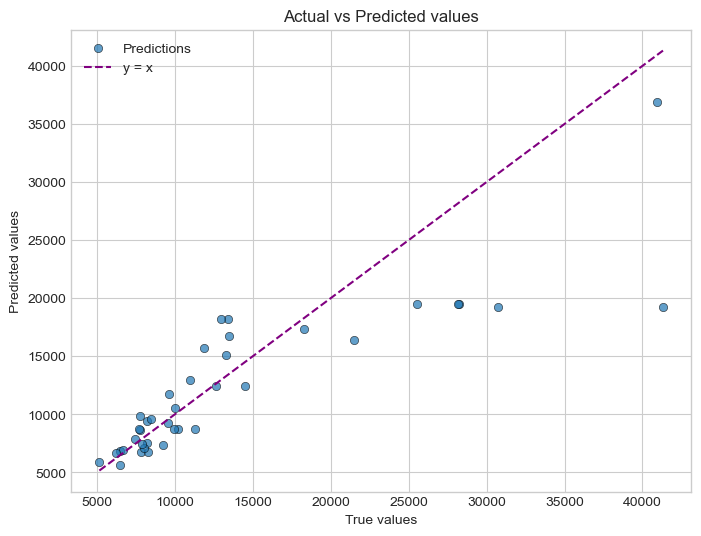

In [30]:
plot_actual_predicted(y_test_original_scale, knn_predict1_not_scaled)

We notice that the points somehow follow a straight line but there is some deviation.

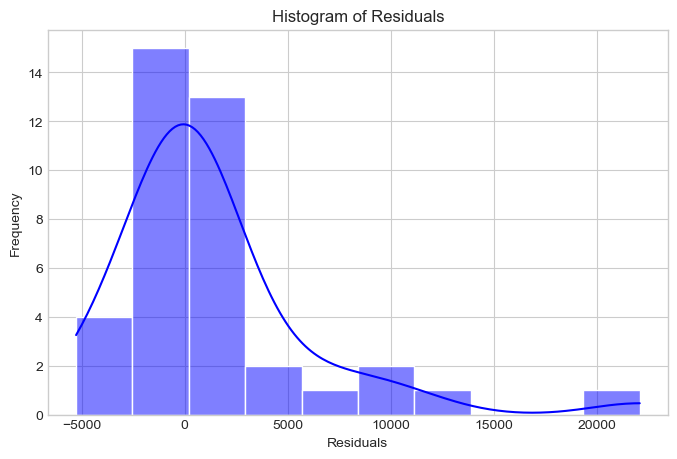

In [31]:
histogram_residuals(y_test_original_scale, knn_predict1_not_scaled)

 The residuals appear to be positively skewed

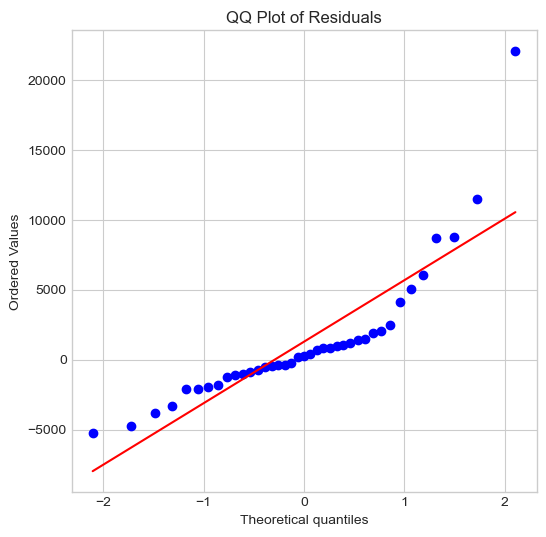

In [32]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict1_not_scaled.flatten()

plot_qq(residuals)

The qq plot suggests that the points somehow follow the straight line, but there is a clear diviation which means the residuals are not normally distributed so the model didn't capture all the information.

#### Let's do some hyperparameter tuning using bayesian search to find the best setup

In [33]:
from skopt.space import Integer

search_space = {
    'n_neighbors': Integer(1, 50),  
    'weights': ['distance'],   #because of the presence of outliers let's choose weighted knn
    'metric': ['euclidean', 'manhattan'], 
}


In [ ]:
bayes_search = BayesSearchCV(
    knn_regressor,
    search_space,
    n_iter=20,  
    cv=5, 
    scoring='neg_mean_absolute_error',  
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

bayes_search.fit(X_train, y_train)

print("Best Parameters setup:", bayes_search.best_params_)

c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 42, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(


Best Parameters setup: OrderedDict({'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'})


From this we see that the best parameters are:  
Distance = manhattan    
k = 4   
weights = distance    

Let's build our knn regressor based on this

In [34]:
knn_regressor2 = KNeighborsRegressor(n_neighbors=4, metric="manhattan",weights="distance")
knn_regressor2.fit(X_train, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

#### Prediction and report

In [35]:
knn_predict2 = knn_regressor2.predict(X_test)

regression_report(knn_predict2, y_test)

       Regression performance report
   Mean squared error:  0.21 
   Mean absolute error: 0.26 
   Root mean squared error: 0.458 
   R2 score: 0.851


#### Visualization of the regression 

* Getting the non scaled prediction for better visualization & interpretability

In [36]:
knn_predict2_not_scaled = scaler_y.inverse_transform(knn_predict2.reshape(-1, 1)).flatten()

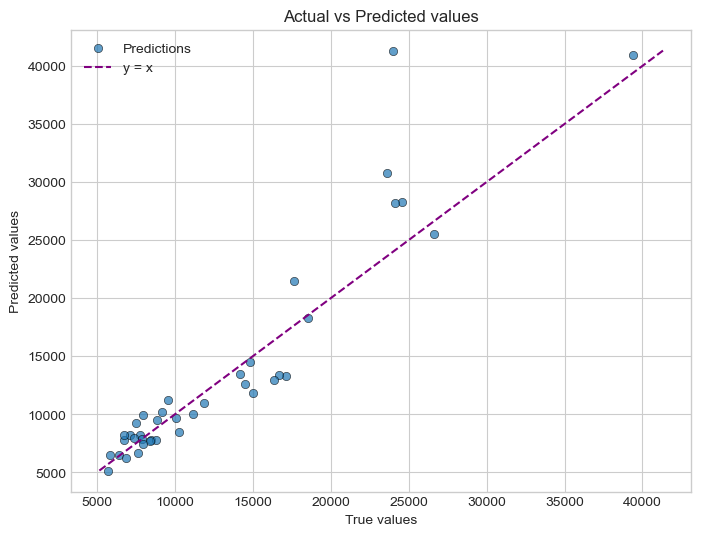

In [37]:
plot_actual_predicted(knn_predict2_not_scaled, y_test_original_scale)

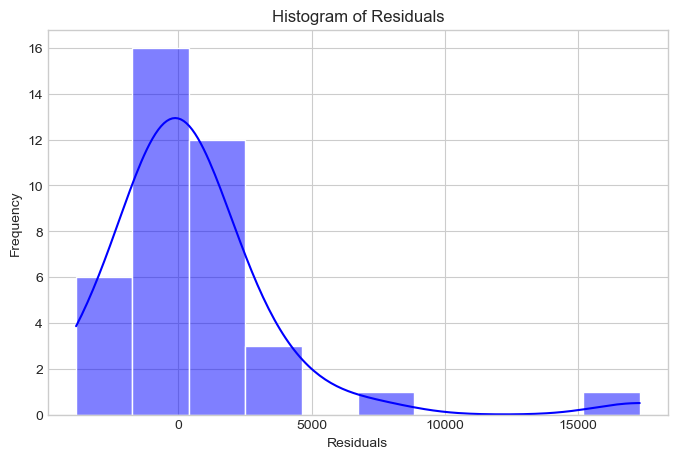

In [38]:
histogram_residuals(y_test_original_scale, knn_predict2_not_scaled)

 The residuals are still positively skewed

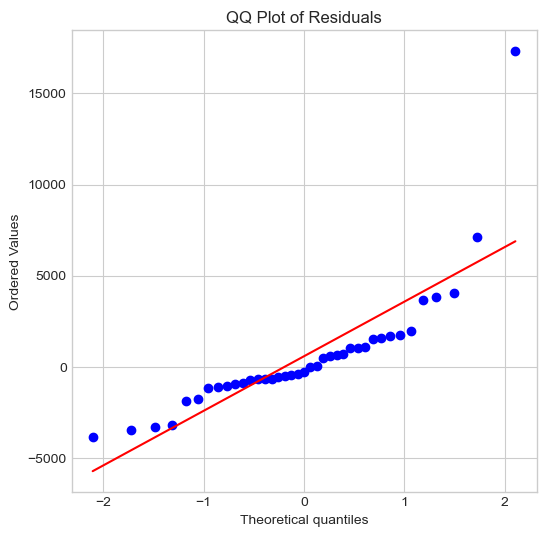

In [39]:
residuals = y_test_original_scale.to_numpy().flatten() - knn_predict2_not_scaled

plot_qq(residuals)

The residuals somehow follow the straight line, but the diviation is still there. Along with the extreme outlier at the top that is not captured by the regressor.

Cross validation

In [40]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# scoring metrics
scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE':make_scorer(mean_squared_error),
    'RMSE':make_scorer(root_mean_squared_error),
    'R2': 'r2'
}

results = cross_validate(knn_regressor2, X_train, y_train, cv=cv, scoring=scoring)

#results
print(f"Test R²: {np.mean(results['test_R2']):.3f} (±{np.std(results['test_R2']):.3f})")
print(f"Test MAE: {np.mean(results['test_MAE']):.3f} (±{np.std(results['test_MAE']):.3f})")
print(f"Test MSE: {np.mean(results['test_MSE']):.3f} (±{np.std(results['test_MSE']):.3f})")
print(f"Test RMSE: {np.mean(results['test_RMSE']):.3f} (±{np.std(results['test_RMSE']):.3f})")



Test R²: 0.832 (±0.118)
Test MAE: 0.229 (±0.059)
Test MSE: 0.122 (±0.086)
Test RMSE: 0.330 (±0.114)


Comparaision between the actual and the predicted prices:

In [41]:
comparaison = pd.DataFrame({
    "Actual price:":y_test_original_scale,
    "Predicted Price: ":knn_predict2_not_scaled
})

print(comparaison)

    Actual price:  Predicted Price: 
0         30760.0       23628.051258
1          9549.0        8835.094110
2         11850.0       15039.820140
3         28248.0       24559.905369
4          7799.0        6705.517048
5          7788.0        8438.462436
6          9258.0        7494.652753
7         10198.0        9165.240064
8          7775.0        8791.401030
9         13295.0       17126.390256
10         8238.0        7764.266593
11        18280.0       18536.989825
12         9988.0       11138.873797
13        40960.0       39367.230674
14         6488.0        6425.119583
15         5151.0        5723.428164
16        12629.0       14475.647314
17         8189.0        7137.050575
18         9960.0        7972.425070
19         8495.0       10245.000000
20        13499.0       14173.995288
21         8249.0        6712.335043
22         6479.0        5856.167403
23         6692.0        7609.000000
24        41315.0       24002.154304
25         9639.0       10051.977141
2

## Conclusion

The KNN regression model has strong predictive performance with an  R² score of 0.851 and a stable one in the cross validation. 

Cross validation results for the other evaluation metrics confirm that the model is generalizing well since they fall within the expected range.    

The visualization of the result (the scatter plot, histogram of the residuals) indicate that the predictions are reliable but there is a presence of outliers.  

The trial of minimizing the impact of these outliers using knn seems to not be totally efficient which indicates that knn algorithm which is a distance based algorithm is not the most suitable one for this task and this data.

__________________________________________________________

## Linear Regression

#### Basic training

In [371]:
linear_regressor = LinearRegression()

linear_regressor.fit(X_train, y_train)

LinearRegression()

Coefficients of the model

In [372]:
print('Coefficients: \n', linear_regressor.coef_)

Coefficients: 
 [[-4.51083471e-02  1.67516121e-02  1.48928417e-01 -1.66711921e-01
   9.08595416e-02 -8.00750255e-02  1.92028300e-01  1.85836893e+00
  -1.33041932e-01  5.84439565e-02  9.00246280e-02  6.25242899e-01
   7.06726638e-02 -2.67065211e+12 -2.80729718e+12 -4.99741731e-01
   6.01713695e+11 -8.47010598e-01  5.43181903e+12  3.67686543e-02
   5.38649732e-01 -4.67102674e-01 -7.19614363e-01 -2.95155543e-01
  -7.97915269e-01 -1.16654685e+00 -3.11476900e-01  3.07273918e-02
  -3.85445916e-01 -7.34001858e-01 -3.69279793e-01  5.12725316e+12
  -7.32603601e-01  6.03203375e-01 -5.98615234e-01  2.02976714e-01
  -1.60132514e+12 -5.66390699e-01 -4.90276390e-01 -2.77008904e-01
   2.63305268e+12  3.23276601e-01 -5.43385233e-02 -4.98582434e-01
  -3.86337315e-01 -3.79945860e-01 -4.72263956e-01  8.04366460e-02
   2.76474029e-01 -1.60132514e+12 -5.12725316e+12  5.82968407e-02
   1.60132514e+12 -3.97065180e-01  2.36851986e+12  1.67666601e+12
   2.23555468e+12  1.11777734e+12 -2.23555468e+12  9.8481215

#### Prediction

In [374]:
prediction1 = linear_regressor.predict(X_test)


regression_report(prediction1, y_test)

       Regression performance report
   Mean squared error:  2.0022855493049682e+23 
   Mean absolute error: 71652393617.205 
   Root mean squared error: 447469054718.309 
   R2 score: -1.4220244132095717e+23


#### Cross validation

In [375]:
scores = cross_validate(linear_regressor, X_train, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, prediction1):.3f}")

Training Mean R²: -59471099934135025664000.000
Test Mean R²:  -142202441320957174874112.000


#### Visualization

* Getting the non standard predictions

In [376]:
prediction1_non_scaled = scaler_y.inverse_transform(prediction1.reshape(-1, 1)).flatten()

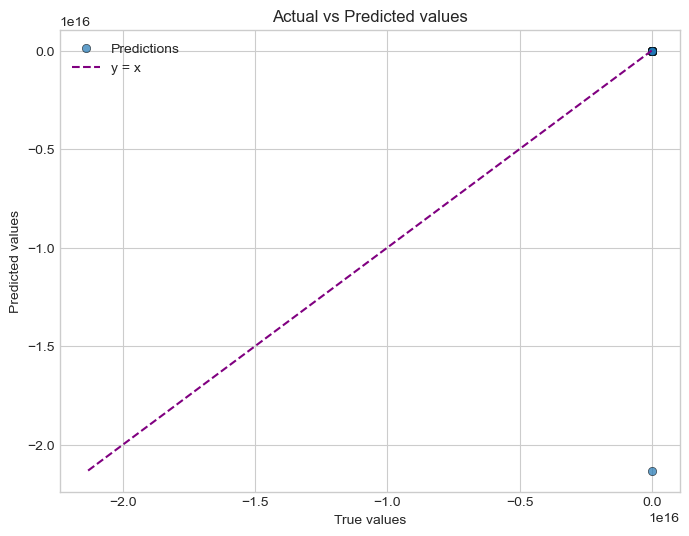

In [377]:
plot_actual_predicted(y_test_original_scale, prediction1_non_scaled)

This is not good, and the cause of this is the multi colinearity between the features (as indicated in the heatmap of the EDA)

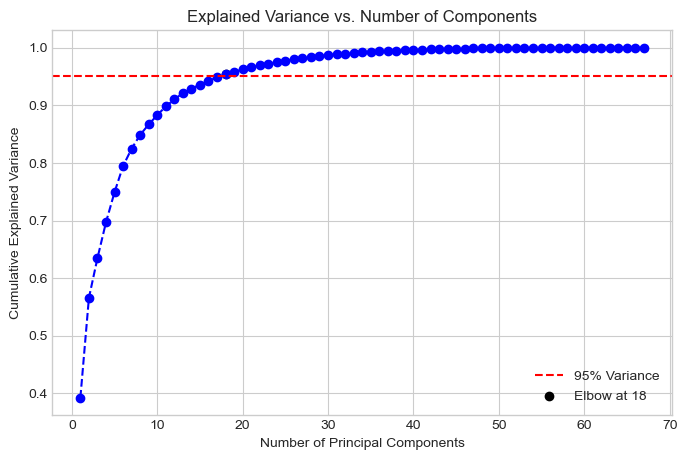

Optimal number of components: 18


In [378]:
pca = PCA()
X_pca = pca.fit_transform(X_train)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#visualisation

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")


plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")


optimal_components = np.argmax(explained_variance >= 0.95) + 1
plt.scatter(optimal_components, explained_variance[optimal_components - 1], color='black', label=f"Elbow at {optimal_components}")
plt.legend()
plt.show()

print(f"Optimal number of components: {optimal_components}")


Applying the PCA

In [379]:
pca = PCA(n_components=18)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.fit_transform(X_test)

In [380]:
linear_regressor.fit(X_train_pca, y_train)
predicted2 = linear_regressor.predict(X_test_pca)

regression_report(predicted2, y_test)

       Regression performance report
   Mean squared error:  4.528 
   Mean absolute error: 1.644 
   Root mean squared error: 2.128 
   R2 score: -2.216


##### Cross validation

In [381]:
scores = cross_validate(linear_regressor, X_train_pca, y_train, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test, predicted2):.3f}")

Training Mean R²: 0.809
Test Mean R²:  -2.216


There is an improvement, but there is a sign of underfitting.

* Getting the non scaled predictions

In [382]:
prediction2_non_scaled = scaler_y.inverse_transform(predicted2.reshape(-1, 1)).flatten()

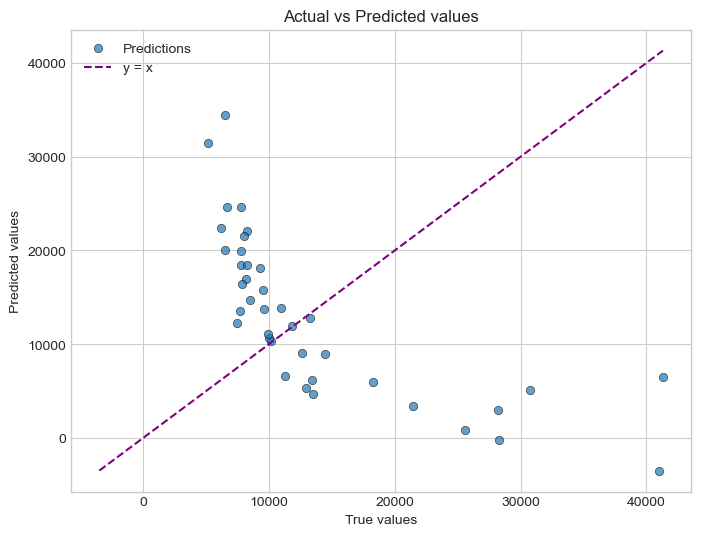

In [383]:
plot_actual_predicted(y_test_original_scale, prediction2_non_scaled)

#### Transforming the features

Training CV R²: 0.602
Test R²: 0.431
       Regression performance report
   Mean squared error:  46655806.884 
   Mean absolute error: 2986.522 
   Root mean squared error: 6830.506 
   R2 score: 0.431


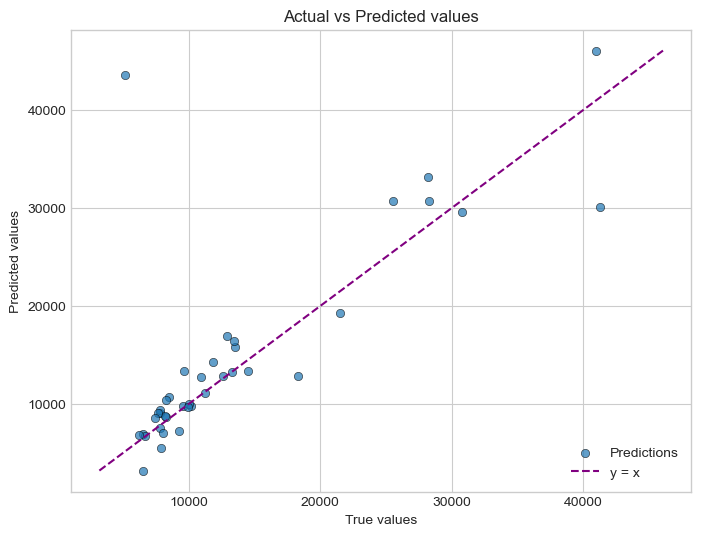

In [384]:
model = make_pipeline(
    PowerTransformer(),
    StandardScaler(),
    LinearRegression()
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)
predicted

plot_actual_predicted(y_test_original_scale, predicted)

### Using Regulization

Training CV R²: 0.881
Test R²: 0.820
       Regression performance report
   Mean squared error:  14778511.372 
   Mean absolute error: 2243.683 
   Root mean squared error: 3844.283 
   R2 score: 0.82


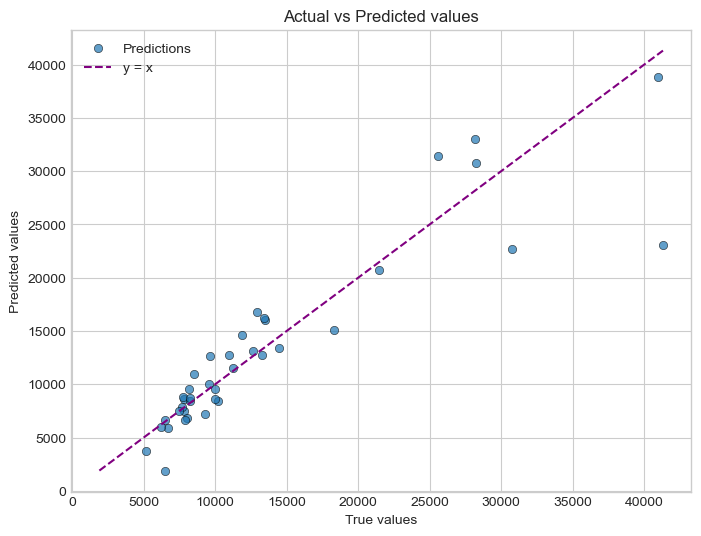

In [385]:
model = make_pipeline(
    PowerTransformer(),
    RobustScaler(),
    Ridge(alpha=1.0)  
)

# cross-validate the training
train_scores = cross_validate(model, X_train_original_scale, y_train_original_scale, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train_original_scale, y_train_original_scale)  
test_r2 = model.score(X_test_original_scale, y_test_original_scale)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test_original_scale)
regression_report(predicted, y_test_original_scale)


plot_actual_predicted(y_test_original_scale, predicted)

### Visualization

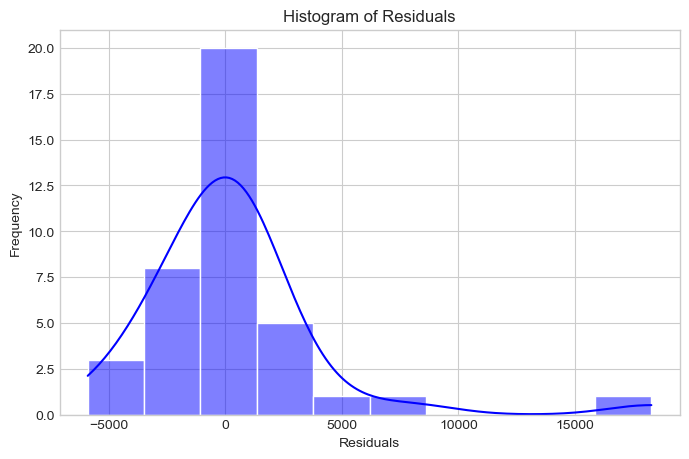

In [386]:
histogram_residuals(y_test_original_scale, predicted)

This histogram indicates that the residuals follow a normal distribution (but has a little right skew to it) which is a good sign since it shows that the model captures all systematic patterns leaving only the white noise.

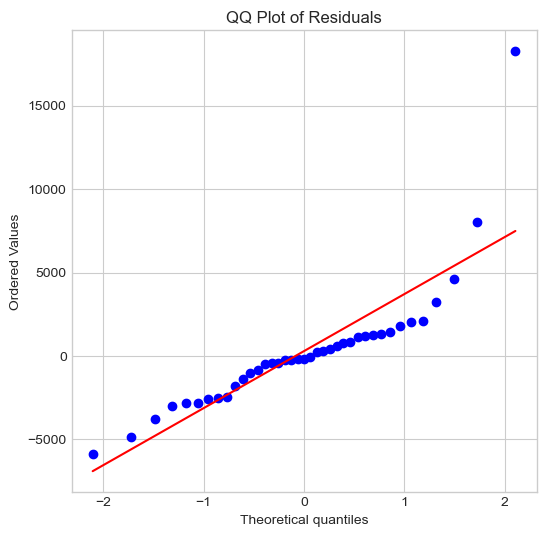

In [387]:
res = y_test_original_scale.to_numpy().flatten() - predicted.flatten()
plot_qq(res)

The qq plot shows that the residuals follow the straight line, which validates our assumption that the residuals are normally distributed.

### Comparaison between the predicted prices and the actual prices

In [388]:
y_test_arr = y_test_original_scale.to_numpy().flatten()
predicted_arr = predicted.flatten()

comparaison = pd.DataFrame({
    "Actual price: ":y_test_arr,
    "Predicted Price: ":predicted_arr
})

print(comparaison)

    Actual price:   Predicted Price: 
0          30760.0       22721.463770
1           9549.0        9989.998449
2          11850.0       14650.059877
3          28248.0       30747.163986
4           7799.0        7505.832095
5           7788.0        8658.265924
6           9258.0        7243.964698
7          10198.0        8397.306052
8           7775.0        8780.000037
9          13295.0       12721.669789
10          8238.0        8462.876127
11         18280.0       15062.483500
12          9988.0        9588.764400
13         40960.0       38879.969496
14          6488.0        6652.060792
15          5151.0        3721.377677
16         12629.0       13073.588509
17          8189.0        9574.220703
18          9960.0        8647.346004
19          8495.0       10975.528816
20         13499.0       16074.004715
21          8249.0        8740.459681
22          6479.0        1895.715144
23          6692.0        5880.565134
24         41315.0       23039.807960
25          

# Conclusion

* The linear regression model at first showed terrible prediction with negative R2 score, and this is because the features were collinear and had no linear relationship with the target.  

* After this, PCA was tried to lower the dimensionality thus delete the collinearity. However after the training and the cross validation the result showed overfitting with bad score. Which suggests that this approach is not suitable. 

* Finally, the approach that showed some improvement was transforming the features using the pipe line and the PowerTransformer transformation, that makes the data more linear.    
But in the end the approach that worked well with 82% R2 score is the Ridge regularization. Which means that for this type of data that shows non linearity the standard Linear Regression model doesn't work well, variation of this model along with the transformation of the features is the solution for better prediction.

_________________________

# Naive Bayes :
Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It is particularly useful for classification tasks and assumes that the features are independent of each other (hence "naive"). Despite this assumption, it often performs well in practice, especially for text classification and spam filtering.

# Initialize the Bayes Naive model

- . Why Gaussian Distribution?
Continuous Data: Gaussian Naive Bayes is specifically designed for continuous data. It assumes that the data for each feature is distributed according to a Gaussian (normal) distribution.
Simplicity: The Gaussian distribution is mathematically simple to work with, as it only requires calculating the mean and variance for each feature.
Common in Real-World Data: Many real-world datasets approximately follow a normal distribution, making the Gaussian assumption reasonable in practice.

- Functions :

In [67]:
def plot_residuals_vs_predicted(y_true, y_pred):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')  
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Predicted Plot")
    plt.grid(True)
    plt.show()

- Naive Bayes Regressor Model :

- The GaussiannNB from scikit-learn is designed for classification tasks.
- We define our model GaussianNaiveBayesRegressor where variance is used to model the Gaussian (normal) distribution of the features for each class.

In [68]:
class GaussianNaiveBayesRegressor:
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.class_means = None
        self.class_vars = None
        self.class_priors = None
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]
        
        self.class_means = np.zeros((n_classes, n_features))
        self.class_vars = np.zeros((n_classes, n_features))
        self.class_priors = np.zeros(n_classes)

        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.class_means[i, :] = X_c.mean(axis=0)
            self.class_vars[i, :] = np.var(X_c, axis=0) + self.epsilon 
            self.class_priors[i] = (X_c.shape[0] + self.epsilon) / (X.shape[0] + len(self.classes) * self.epsilon)

    def predict(self, X):

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes):
            log_prior = np.log(self.class_priors[i])
            log_likelihood = -0.5 * np.sum(
                np.log(2. * np.pi * np.maximum(self.class_vars[i, :], self.epsilon)) +
                ((X - self.class_means[i, :]) ** 2) / np.maximum(self.class_vars[i, :], self.epsilon),
                axis=1
            )
            log_probs[:, i] = log_prior + log_likelihood

        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs) / np.exp(log_probs).sum(axis=1, keepdims=True)

        y_pred = np.zeros(n_samples)
        for i, c in enumerate(self.classes):
            y_pred += probs[:, i] * c

        return y_pred
    
    def get_params(self, deep=True):
        
        return {"epsilon": self.epsilon}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

- Train and evaluate the model

In [69]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [70]:
model = GaussianNaiveBayesRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

regression_report(y_pred, y_test)


       Regression performance report
   Mean squared error:  0.838 
   Mean absolute error: 0.537 
   Root mean squared error: 0.916 
   R2 score: 0.405


* Let's turn the predictions to the original scale for better interpretation

In [71]:
y_pred_not_scaled = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()

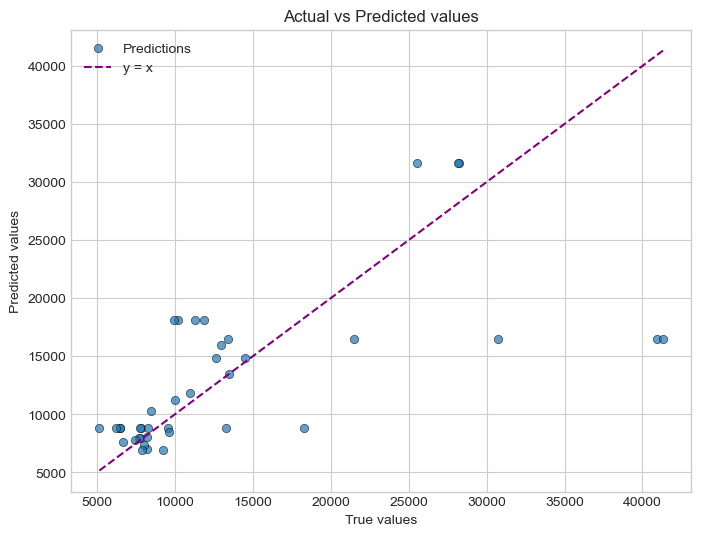

In [72]:
plot_actual_predicted(y_test_original_scale, y_pred_not_scaled)

- Analysis : we notice that the points do not follow the pattern the way we want so we will need some improvement

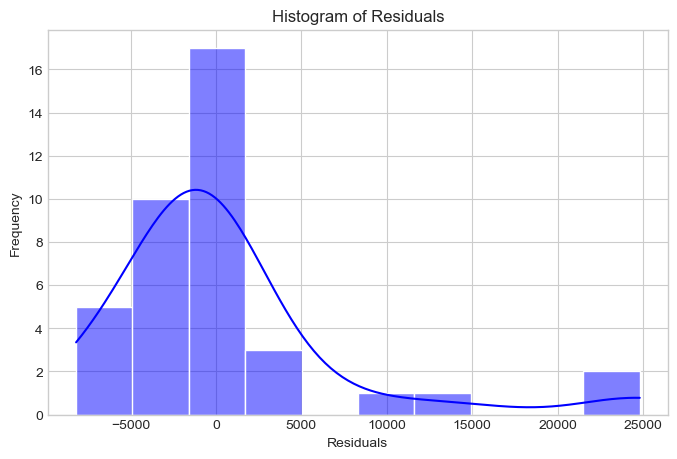

In [73]:
histogram_residuals(y_test_original_scale, y_pred_not_scaled)

- The residuals are right-skewed, indicating the model tends to underestimate some values, with moderate variance and a few outliers, suggesting potential improvements through transformation, feature scaling, or a more robust model.

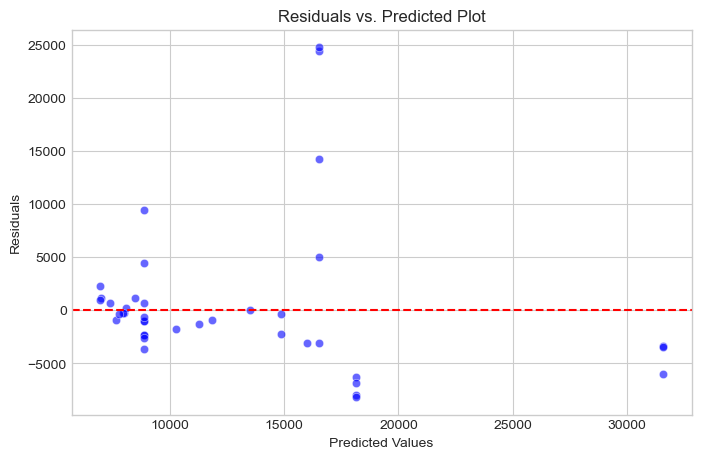

In [74]:
plot_residuals_vs_predicted(y_test_original_scale, y_pred_not_scaled)

- Residuals vs. Predicted Plot: Residuals show patterns, indicating model bias or underfitting.

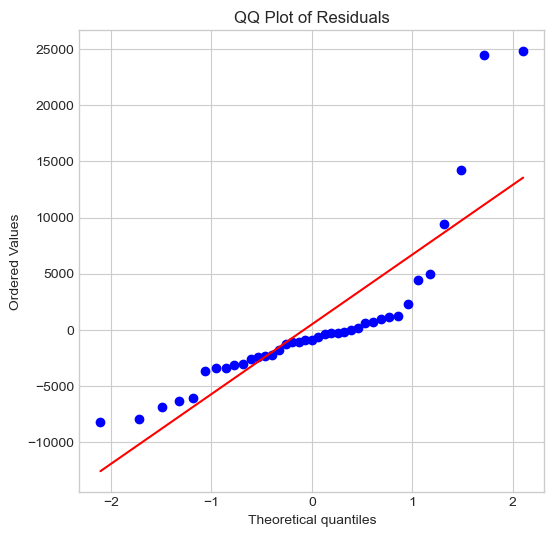

In [75]:
residuals = y_test_original_scale - y_pred_not_scaled
plot_qq(residuals)

Residuals deviate from normality

- Analyze the diffrent results :

According to the performance measures the model is not performing well because of the quite small R2 value and the relatively high value for the error measures.

We can also see that our model does follow the pattern we want but not with the amount we want so we it will need a bit of improvement


- Use hypermarameter tuning to improve the model by selecting the best epsilon value :

In [76]:
from skopt.space import Categorical

pipeline_bayes = make_pipeline(
    GaussianNaiveBayesRegressor()  
)

search_space = {
    'gaussiannaivebayesregressor__epsilon': Categorical([ 2e-3,3e-3,4e-3,5e-3,6e-3,7e-3,8e-3 ,9.4e-3]),
}

bayes_search = BayesSearchCV(
    pipeline_bayes, 
    search_space, 
    n_iter=20,  
    cv=5, 
    scoring="neg_mean_squared_error", 
    n_jobs=-1
)

bayes_search.fit(X_train, y_train)

print(" Bayesian Search Best Parameters: ", bayes_search.best_params_)

best_model_bayes = bayes_search.best_estimator_

y_pred_bayes = best_model_bayes.predict(X_test)

regression_report(y_pred_bayes, y_test)

 Bayesian Search Best Parameters:  OrderedDict([('gaussiannaivebayesregressor__epsilon', 0.0094)])
       Regression performance report
   Mean squared error:  0.189 
   Mean absolute error: 0.275 
   Root mean squared error: 0.434 
   R2 score: 0.866


In [77]:
y_pred_bayes_not_scaled = scaler_y.inverse_transform(y_pred_bayes.reshape(-1, 1)).flatten()

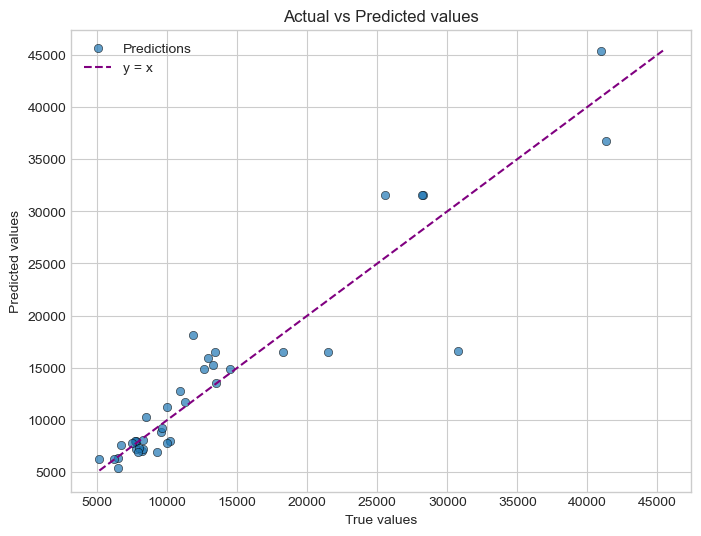

In [78]:
plot_actual_predicted(y_test_original_scale, y_pred_bayes_not_scaled)

 Predictions align well with the diagonal line, but some outliers deviate from the pattern

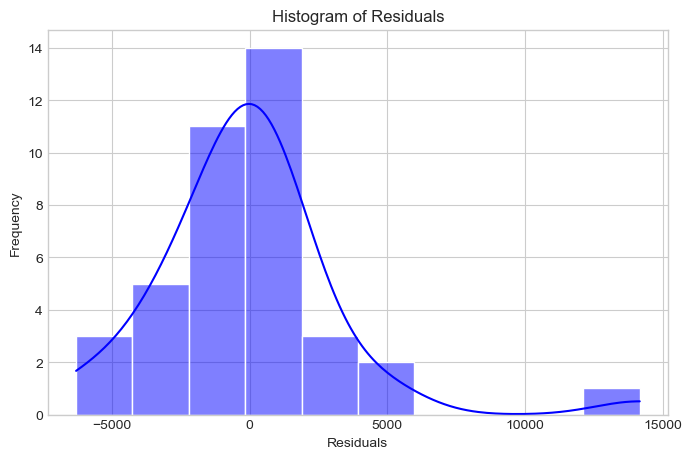

In [79]:
histogram_residuals(y_test_original_scale, y_pred_bayes_not_scaled)

 Residuals are roughly centered around zero, but the distribution is slightly skewed.

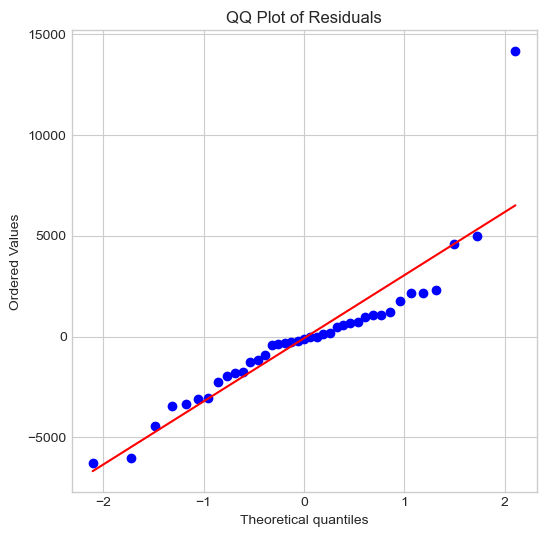

In [80]:
plot_qq(y_test_original_scale - y_pred_bayes_not_scaled)

Residuals mostly follow the red line, but slight deviations at the tails suggest minor non-normality.

- Analyzing the improvement results :
We can see that our model has significantly improved in terms of performance measures and capturing the patterns 

- Comparision between predictions and actual price values

In [82]:
actual = y_test_original_scale
pred = y_pred_bayes_not_scaled

comparaison = pd.DataFrame({
    "Actual price standardized: ":actual,
    "Predicted Price standardized: ":pred
})

print(comparaison)

    Actual price standardized:   Predicted Price standardized: 
0                       30760.0                    16595.204730
1                        9549.0                     8850.950869
2                       11850.0                    18150.000000
3                       28248.0                    31600.000000
4                        7799.0                     7243.274002
5                        7788.0                     7898.000000
6                        9258.0                     6938.000000
7                       10198.0                     8013.000000
8                        7775.0                     7995.000000
9                       13295.0                    15250.000000
10                       8238.0                     8058.000000
11                      18280.0                    16500.000000
12                       9988.0                    11248.000000
13                      40960.0                    45400.000000
14                       6488.0         

- Conclusion :
    - The overall Naive Bayes performance is good , with quite law error performance measures and a high R2 score.
    - The predictions comparisions are quite close with the presence of some outliers that we can see them present in our comparision.
    - Hyper paramter tuning helped in improving the model perfomance noticebally 



# ANN Regression for Car Price Prediction

This notebook focuses exclusively on improving the Artificial Neural Network (ANN) model for car price prediction through:
- Enhanced data preprocessing and feature engineering
- Systematic neural architecture optimization
- Advanced training techniques
- Comprehensive model evaluation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, PReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber
from tensorflow.keras.metrics import RootMeanSquaredError
import time

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

2025-05-10 17:20:26.637230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746894026.653861  519949 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746894026.658631  519949 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746894026.672119  519949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746894026.672141  519949 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746894026.672143  519949 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 2. Load and Explore Data

In [2]:
# Load the data
x_train = pd.read_csv('x_train_not_standard.csv', index_col=0)
y_train = pd.read_csv('y_train_not_standard.csv', index_col=0)
x_test = pd.read_csv('x_test_not_standard.csv', index_col=0)
y_test = pd.read_csv('y_test_not_standard.csv', index_col=0)

print("Training features shape:", x_train.shape)
print("Training target shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test target shape:", y_test.shape)

# Check for missing values
print("\nMissing values in training data:", x_train.isnull().sum().sum())
print("Missing values in test data:", x_test.isnull().sum().sum())

Training features shape: (162, 67)
Training target shape: (162, 1)
Test features shape: (39, 67)
Test target shape: (39, 1)

Missing values in training data: 0
Missing values in test data: 0


## 3. Enhanced Exploratory Data Analysis


Feature Statistics:


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,power_to_weight,num_cylinders,engine_size_per_cylinder,combined_mpg
count,162.000000,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02,1.620000e+02
mean,0.000000,-1.219875e-16,-8.333526e-16,1.359681e-15,-1.359681e-15,-4.468305e-15,-3.618505e-16,-1.096517e-16,-1.368590e-15,-5.592234e-16,1.644775e-16,-1.315820e-16,-6.853229e-16,1.864078e-16,1.315820e-16,-2.302685e-16,7.675616e-17,2.850943e-16,-1.535123e-16
std,1.003101,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00,1.003101e+00
min,-2.324228,-1.749206e+00,-2.033612e+00,-2.462665e+00,-1.987134e+00,-2.407119e+00,-1.453743e+00,-1.402678e+00,-2.935398e+00,-3.728030e+00,-7.999933e-01,-1.380116e+00,-2.009762e+00,-1.985082e+00,-2.275635e+00,-2.159157e+00,-2.201667e+00,-1.838815e+00,-2.071064e+00
25%,-0.721994,-6.523332e-01,-7.120841e-01,-6.175518e-01,-8.232327e-01,-7.069178e-01,-7.526786e-01,-7.034201e-01,-6.352154e-01,-4.076897e-01,-3.861128e-01,-8.410674e-01,-6.903857e-01,-9.961020e-01,-8.643736e-01,-6.144782e-01,-3.440105e-01,-8.731423e-01,-9.162206e-01
50%,0.079123,-1.455025e-01,-3.356998e-01,-9.393847e-02,-1.927861e-01,1.431827e-01,-2.627721e-01,-1.664900e-01,-3.188879e-02,1.025281e-01,-2.826427e-01,-2.354693e-01,1.215379e-01,-1.719522e-01,-8.033931e-02,-2.270405e-01,-3.440105e-01,-2.632436e-01,-1.260648e-01
75%,0.880239,6.714783e-01,5.927150e-01,7.621278e-01,3.285447e-01,7.402771e-01,7.417089e-01,3.704402e-01,8.353932e-01,4.793044e-01,-1.791726e-01,3.235443e-01,7.304807e-01,8.170275e-01,5.468881e-01,4.040039e-01,-3.440105e-01,3.466550e-01,6.843515e-01
max,1.681356,4.030177e+00,2.817565e+00,2.357902e+00,2.959447e+00,2.450598e+00,2.980577e+00,4.990537e+00,2.343710e+00,2.865554e+00,3.338812e+00,4.210020e+00,2.963271e+00,3.289477e+00,3.055798e+00,3.754810e+00,7.086615e+00,2.887900e+00,3.196642e+00



Target Statistics:


,price
count,162.000000
mean,13137.796296
std,7653.384687
min,5118.000000
25%,7641.250000
50%,10646.500000
75%,16512.000000
max,45400.000000


Potential outliers in target: 11


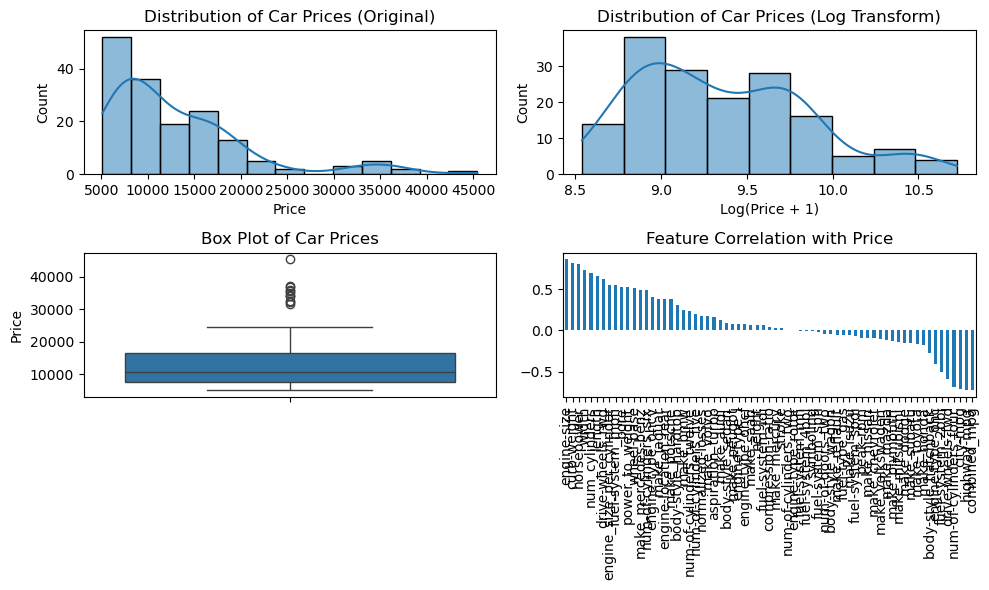

In [3]:
# Feature statistics
print("\nFeature Statistics:")
display(x_train.describe())

# Target statistics
print("\nTarget Statistics:")
display(y_train.describe())

# Check for outliers in the target variable
Q1 = y_train['price'].quantile(0.25)
Q3 = y_train['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Potential outliers in target: {((y_train['price'] < lower_bound) | (y_train['price'] > upper_bound)).sum()}")

# Visualize distribution and transformations
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(y_train['price'], kde=True)
plt.title('Distribution of Car Prices (Original)')
plt.xlabel('Price')

# Log transform for skewed price distribution
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(y_train['price']), kde=True)
plt.title('Distribution of Car Prices (Log Transform)')
plt.xlabel('Log(Price + 1)')

# Boxplot to visualize outliers
plt.subplot(2, 2, 3)
sns.boxplot(y=y_train['price'])
plt.title('Box Plot of Car Prices')
plt.ylabel('Price')

# Feature correlation analysis
plt.subplot(2, 2, 4)
correlation = x_train.corrwith(y_train['price']).sort_values(ascending=False)
correlation.plot(kind='bar', figsize=(10, 6))
plt.title('Feature Correlation with Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [4]:
# Handle outliers in target (capping extreme values)
y_train_processed = y_train.copy()
y_train_processed['price'] = np.where(y_train['price'] > upper_bound, upper_bound, 
                              np.where(y_train['price'] < lower_bound, lower_bound, y_train['price']))

# Feature selection
selector = SelectKBest(f_regression, k='all')
selector.fit(x_train, y_train_processed['price'])
feature_scores = pd.DataFrame({'Feature': x_train.columns, 'Score': selector.scores_})
top_features = feature_scores.sort_values('Score', ascending=False)
print("\nTop 10 important features:")
display(top_features.head(10))

# Create polynomial features for top numerical features
# Identify top numerical features
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns
top_num_features = [col for col in top_features['Feature'].head(5) if col in numerical_features]

# Create a copy of the datasets for feature engineering
x_train_fe = x_train.copy()
x_test_fe = x_test.copy()

for feature in top_num_features:
    x_train_fe[f'{feature}_squared'] = x_train_fe[feature] ** 2
    x_test_fe[f'{feature}_squared'] = x_test_fe[feature] ** 2

# Add interaction terms between top features
if len(top_num_features) >= 2:
    for i in range(len(top_num_features)-1):
        for j in range(i+1, len(top_num_features)):
            feat1, feat2 = top_num_features[i], top_num_features[j]
            x_train_fe[f'{feat1}_x_{feat2}'] = x_train_fe[feat1] * x_train_fe[feat2]
            x_test_fe[f'{feat1}_x_{feat2}'] = x_test_fe[feat1] * x_test_fe[feat2]

print(f"Features after engineering: {x_train_fe.shape[1]}")

# Scaling and transformations
# Standard scaling
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(x_train_fe)
X_test_scaled = scaler_standard.transform(x_test_fe)

# Power transform for potentially better handling of skewed features
power_transformer = PowerTransformer(method='yeo-johnson')
X_train_power = power_transformer.fit_transform(x_train_fe)
X_test_power = power_transformer.transform(x_test_fe)

# Robust scaling (less sensitive to outliers)
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(x_train_fe)
X_test_robust = robust_scaler.transform(x_test_fe)

# For target, try both regular and log transform scaling
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_processed)
y_test_scaled = y_scaler.transform(y_test)

# Log transform version
y_train_log = np.log1p(y_train_processed)
y_test_log = np.log1p(y_test)
y_log_scaler = StandardScaler()
y_train_log_scaled = y_log_scaler.fit_transform(y_train_log)
y_test_log_scaled = y_log_scaler.transform(y_test_log)


Top 10 important features:


,Feature,Score
6,curb-weight,417.126308
7,engine-size,355.022676
11,horsepower,323.655484
4,width,209.455501
18,combined_mpg,206.712397
14,highway-mpg,202.571134
13,city-mpg,195.206119
3,length,152.968420
56,num-of-cylinders_four,149.498621
48,drive-wheels_rwd,125.362874


Features after engineering: 82


## 5. Custom Callbacks and Helpers for Model Training

In [5]:
# Custom callback to save best weights in memory to avoid TensorFlow model loading issues
class BestWeightsCallback(tf.keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', mode='min'):
        super(BestWeightsCallback, self).__init__()
        self.monitor = monitor
        self.best_weights = None
        self.best_epoch = 0
        self.mode = mode
        if mode == 'min':
            self.best = float('inf')
            self.monitor_op = lambda a, b: a < b
        else:  # 'max'
            self.best = float('-inf')
            self.monitor_op = lambda a, b: a > b

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        
        if self.monitor_op(current, self.best):
            self.best = current
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()
            print(f'\nEpoch {epoch+1}: New best {self.monitor} = {current:.6f}')

# Training utility function
def train_model(X_train, y_train, X_val, y_val, model, 
                batch_size=32, epochs=500, optimizer='adam', learning_rate=0.001,
                loss='mse', patience=15):
    
    # Best weights callback
    best_weights_callback = BestWeightsCallback(monitor='val_loss', mode='min')
    
    # Define callbacks
    callbacks = [
        # Early stopping
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            verbose=1,
            min_delta=0.0001
        ),
        # Reduce learning rate when training plateaus
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=1,
            min_delta=0.0001,
            min_lr=1e-6
        ),
        # Custom callback to track best weights
        best_weights_callback
    ]
    
    # Configure optimizer
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9, nesterov=True)
    
    # Configure loss function
    if loss == 'mse':
        loss_fn = MeanSquaredError()
    elif loss == 'mae':
        loss_fn = MeanAbsoluteError()
    elif loss == 'huber':
        loss_fn = Huber(delta=1.0)
    
    # Compile model
    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[RootMeanSquaredError()]
    )
    
    # Train model
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    training_time = time.time() - start_time
    
    # Restore best weights
    if best_weights_callback.best_weights is not None:
        print(f"Restoring best weights from epoch {best_weights_callback.best_epoch}")
        model.set_weights(best_weights_callback.best_weights)
    
    return model, history, training_time

## 6. Neural Architecture Search

In [6]:
# Split validation set
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=42
)

# For log-transformed target
_, _, y_train_log_main, y_val_log = train_test_split(
    X_train_scaled, y_train_log_scaled, test_size=0.15, random_state=42
)

# Define architecture search space
def create_model_architecture(input_dim, architecture_params):
    model = Sequential()
    
    # First layer always includes input shape
    model.add(Dense(architecture_params['layer_sizes'][0], input_shape=(input_dim,)))
    
    # Add batch normalization if specified
    if architecture_params['use_batch_norm']:
        model.add(BatchNormalization())
        
    # Add activation
    if architecture_params['activation'] == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.1))
    elif architecture_params['activation'] == 'prelu':
        model.add(PReLU())
    else:  # Regular ReLU
        model.add(tf.keras.layers.Activation('relu'))
    
    # Add dropout if rate > 0
    if architecture_params['dropout_rates'][0] > 0:
        model.add(Dropout(architecture_params['dropout_rates'][0]))
    
    # Add remaining hidden layers
    for i in range(1, len(architecture_params['layer_sizes'])):
        reg = None
        if architecture_params['use_regularization']:
            reg = l1_l2(l1=1e-5, l2=1e-4)
            
        model.add(Dense(architecture_params['layer_sizes'][i], kernel_regularizer=reg))
        
        if architecture_params['use_batch_norm']:
            model.add(BatchNormalization())
            
        if architecture_params['activation'] == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.1))
        elif architecture_params['activation'] == 'prelu':
            model.add(PReLU())
        else:  # Regular ReLU
            model.add(tf.keras.layers.Activation('relu'))
        
        if i < len(architecture_params['dropout_rates']) and architecture_params['dropout_rates'][i] > 0:
            model.add(Dropout(architecture_params['dropout_rates'][i]))
    
    # Output layer
    model.add(Dense(1))
    
    return model

# Define architectures to try
architecture_search_space = [
    {
        'name': 'Small Network',
        'layer_sizes': [64, 32],
        'dropout_rates': [0.2, 0.1],
        'activation': 'relu',
        'use_batch_norm': False,
        'use_regularization': False
    },
    {
        'name': 'Medium Network with Regularization',
        'layer_sizes': [128, 64, 32],
        'dropout_rates': [0.3, 0.3, 0.2],
        'activation': 'relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Deep Network',
        'layer_sizes': [256, 128, 64, 32],
        'dropout_rates': [0.4, 0.3, 0.3, 0.2],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'Wide Network',
        'layer_sizes': [512, 256, 128],
        'dropout_rates': [0.5, 0.4, 0.3],
        'activation': 'leaky_relu',
        'use_batch_norm': True,
        'use_regularization': True
    },
    {
        'name': 'PReLU Network',
        'layer_sizes': [256, 128, 64],
        'dropout_rates': [0.4, 0.3, 0.2],
        'activation': 'prelu',
        'use_batch_norm': True,
        'use_regularization': True
    }
]

# Training parameters to try
training_params = [
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.0005, 'batch_size': 64, 'loss': 'mse'},
    {'optimizer': 'rmsprop', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'mse'},
    {'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'loss': 'huber'}
]

# Target transformation options
target_options = [
    {'name': 'Standard Scaled', 'X_train': X_train_main, 'y_train': y_train_main, 
     'X_val': X_val, 'y_val': y_val, 'X_test': X_test_scaled, 'y_test': y_test_scaled,
     'inverse_func': lambda y: y_scaler.inverse_transform(y)},
    
    {'name': 'Log Transformed', 'X_train': X_train_main, 'y_train': y_train_log_main,
     'X_val': X_val, 'y_val': y_val_log, 'X_test': X_test_scaled, 'y_test': y_test_log_scaled,
     'inverse_func': lambda y: np.expm1(y_log_scaler.inverse_transform(y))}
]

## 7. Run Architecture Search



Training: Standard Scaled + Small Network + adam (lr=0.001) + mse


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-10 17:20:29.286298: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - loss: 1.7350 - root_mean_squared_error: 1.3172
Epoch 1: New best val_loss = 0.570468
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.3506 - root_mean_squared_error: 1.1598 - val_loss: 0.5705 - val_root_mean_squared_error: 0.7553 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0302 - root_mean_squared_error: 1.0150
Epoch 2: New best val_loss = 0.426070
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9695 - root_mean_squared_error: 0.9844 - val_loss: 0.4261 - val_root_mean_squared_error: 0.6527 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6344 - root_mean_squared_error: 0.7965
Epoch 3: New best val_loss = 0.411473
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5293 - root_mean_squared_error: 0.7266 - val_loss: 0.4115 - val_root_mean_squared_error: 0.6415 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.9531 - root_mean_squared

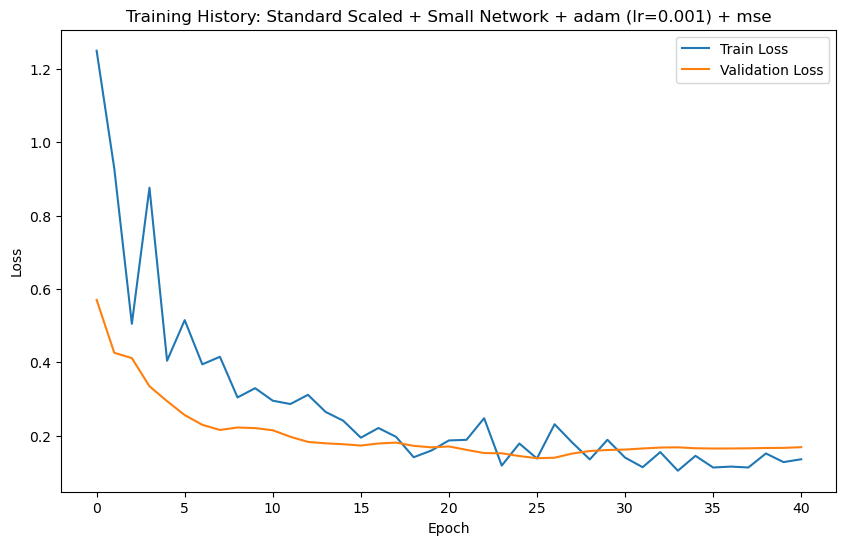



Training: Standard Scaled + Small Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step - loss: 1.7760 - root_mean_squared_error: 1.3327
Epoch 1: New best val_loss = 0.807666
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.6013 - root_mean_squared_error: 1.2648 - val_loss: 0.8077 - val_root_mean_squared_error: 0.8987 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5134 - root_mean_squared_error: 1.2302
Epoch 2: New best val_loss = 0.708212
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3755 - root_mean_squared_error: 1.1723 - val_loss: 0.7082 - val_root_mean_squared_error: 0.8416 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2899 - root_mean_squared_error: 1.1357
Epoch 3: New best val_loss = 0.632891
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1430 - root_mean_squared_error: 1.0684 - val_loss: 0.6329 - val_root_mean_squared_error: 0.7955 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.6759 - root_mean_squared

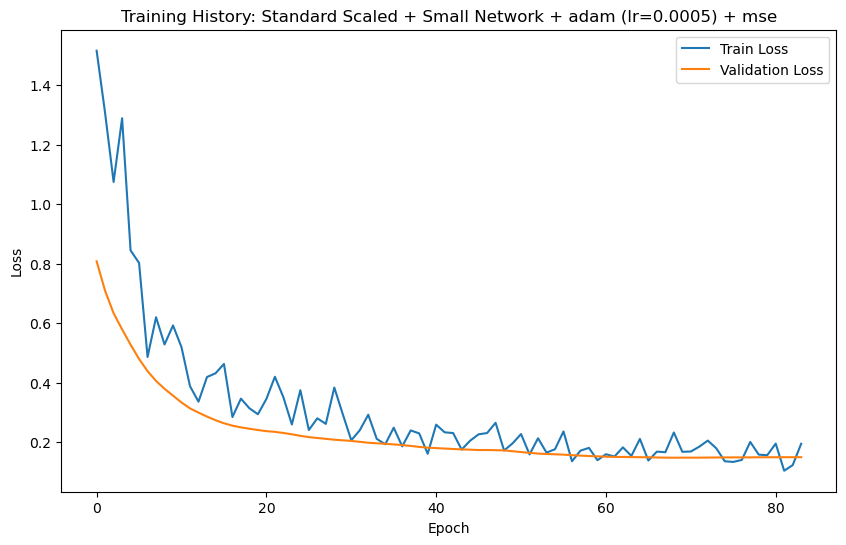



Training: Standard Scaled + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - loss: 2.9180 - root_mean_squared_error: 1.7082
Epoch 1: New best val_loss = 1.153258
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 2.0888 - root_mean_squared_error: 1.4386 - val_loss: 1.1533 - val_root_mean_squared_error: 1.0739 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1591 - root_mean_squared_error: 1.0766
Epoch 2: New best val_loss = 0.834399
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8895 - root_mean_squared_error: 0.9407 - val_loss: 0.8344 - val_root_mean_squared_error: 0.9135 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6523 - root_mean_squared_error: 0.8076
Epoch 3: New best val_loss = 0.649850
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5807 - root_mean_squared_error: 0.7616 - val_loss: 0.6498 - val_root_mean_squared_error: 0.8061 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3199 - root_mean_squared_error: 1.14

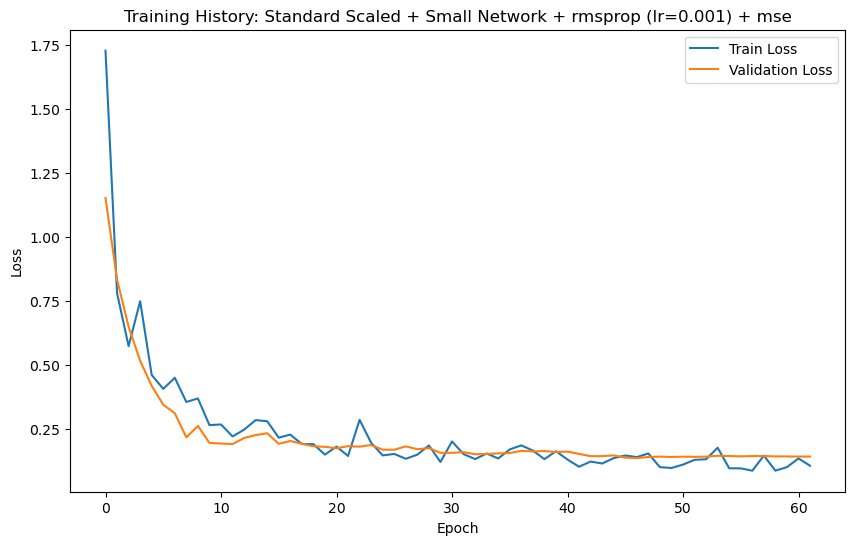



Training: Standard Scaled + Small Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - loss: 0.8328 - root_mean_squared_error: 1.4775
Epoch 1: New best val_loss = 0.342323
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.7165 - root_mean_squared_error: 1.3593 - val_loss: 0.3423 - val_root_mean_squared_error: 0.8548 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5787 - root_mean_squared_error: 1.4063
Epoch 2: New best val_loss = 0.145088
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4739 - root_mean_squared_error: 1.1789 - val_loss: 0.1451 - val_root_mean_squared_error: 0.5387 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3434 - root_mean_squared_error: 0.8751
Epoch 3: New best val_loss = 0.078842
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3151 - root_mean_squared_error: 0.8699 - val_loss: 0.0788 - val_root_mean_squared_error: 0.3971 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4066 - root_mean_squared_error: 1.15

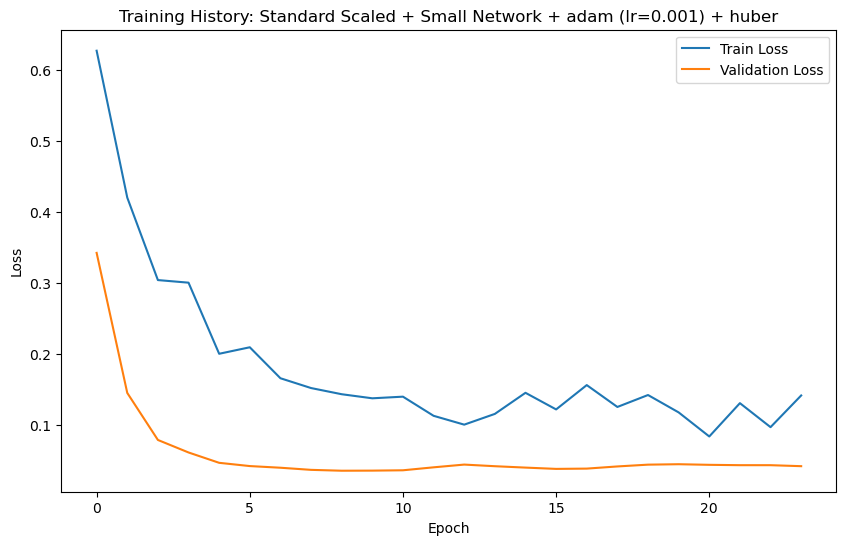



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.6952 - root_mean_squared_error: 1.2933
Epoch 1: New best val_loss = 0.586414
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 1.6507 - root_mean_squared_error: 1.2756 - val_loss: 0.5864 - val_root_mean_squared_error: 0.7509 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0268 - root_mean_squared_error: 1.0021
Epoch 2: New best val_loss = 0.508691
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2925 - root_mean_squared_error: 1.1253 - val_loss: 0.5087 - val_root_mean_squared_error: 0.6972 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7779 - root_mean_squared_error: 0.8691
Epoch 3: New best val_loss = 0.472718
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9471 - root_mean_squared_error: 0.9606 - val_loss: 0.4727 - val_root_mean_squared_error: 0.6709 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1916 - root_mean_squared_error: 1.0812


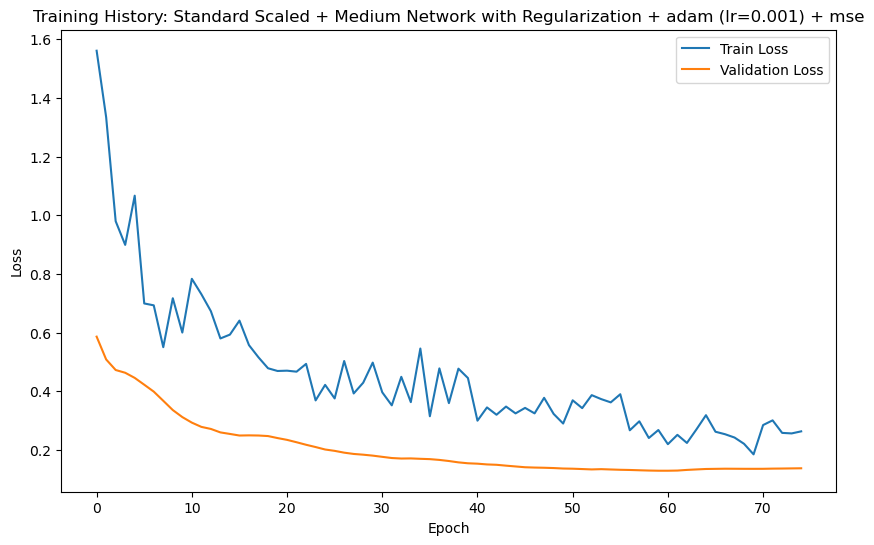



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 4.2259 - root_mean_squared_error: 2.0502
Epoch 1: New best val_loss = 0.859370
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 4.5329 - root_mean_squared_error: 2.1233 - val_loss: 0.8594 - val_root_mean_squared_error: 0.9148 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.9725 - root_mean_squared_error: 1.9874
Epoch 2: New best val_loss = 0.745748
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.0764 - root_mean_squared_error: 2.0133 - val_loss: 0.7457 - val_root_mean_squared_error: 0.8504 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.8107 - root_mean_squared_error: 1.9463
Epoch 3: New best val_loss = 0.643296
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.8508 - root_mean_squared_error: 1.9566 - val_loss: 0.6433 - val_root_mean_squared_error: 0.7879 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.3569 - root_mean_squared_er

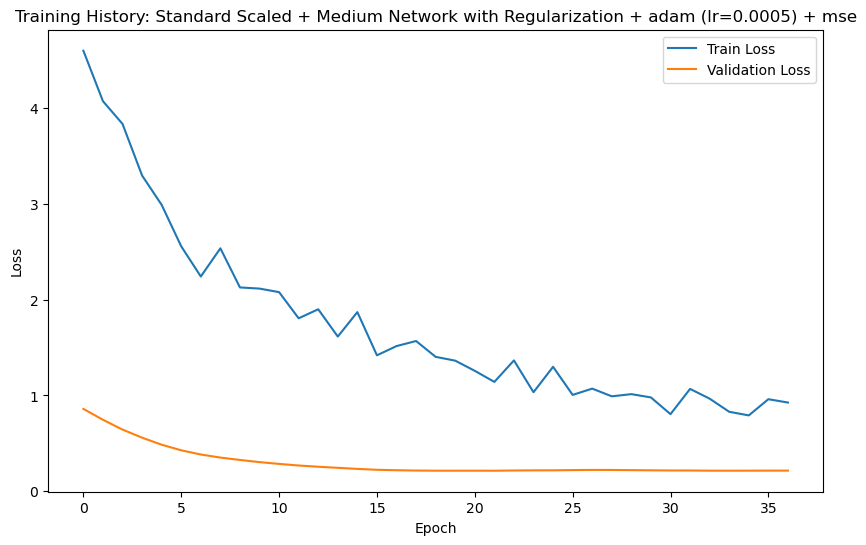



Training: Standard Scaled + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.3694 - root_mean_squared_error: 1.5319
Epoch 1: New best val_loss = 1.098730
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.8900 - root_mean_squared_error: 1.3639 - val_loss: 1.0987 - val_root_mean_squared_error: 1.0374 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9099 - root_mean_squared_error: 0.9420
Epoch 2: New best val_loss = 0.903885
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3434 - root_mean_squared_error: 1.1449 - val_loss: 0.9039 - val_root_mean_squared_error: 0.9388 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7463 - root_mean_squared_error: 0.8507
Epoch 3: New best val_loss = 0.766236
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0008 - root_mean_squared_error: 0.9871 - val_loss: 0.7662 - val_root_mean_squared_error: 0.8623 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8541 - root_mean_squared_error: 0.9119


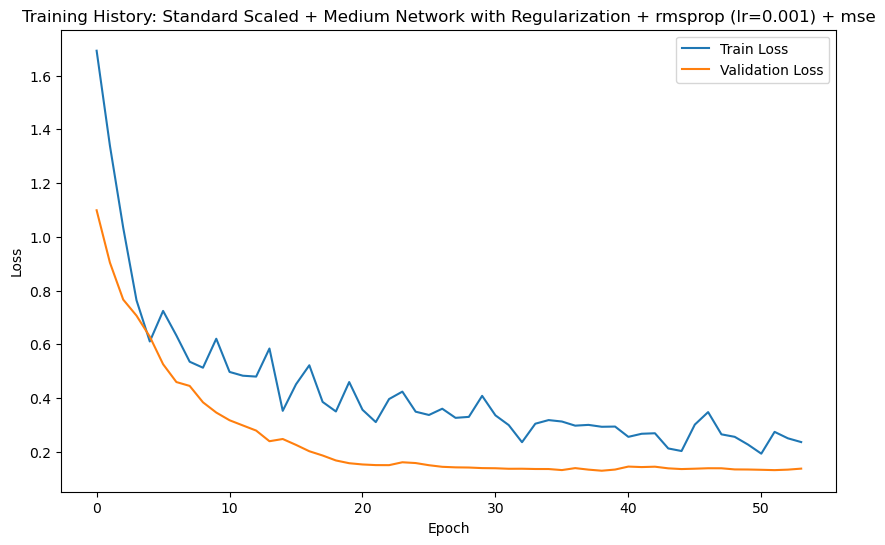



Training: Standard Scaled + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.1375 - root_mean_squared_error: 1.9951
Epoch 1: New best val_loss = 0.298447
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.9148 - root_mean_squared_error: 1.6821 - val_loss: 0.2984 - val_root_mean_squared_error: 0.7591 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6255 - root_mean_squared_error: 1.2587
Epoch 2: New best val_loss = 0.263929
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5742 - root_mean_squared_error: 1.1858 - val_loss: 0.2639 - val_root_mean_squared_error: 0.7029 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6740 - root_mean_squared_error: 1.2969
Epoch 3: New best val_loss = 0.242748
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5905 - root_mean_squared_error: 1.2035 - val_loss: 0.2427 - val_root_mean_squared_error: 0.6685 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4074 - root_mean_squared_error: 1.0211


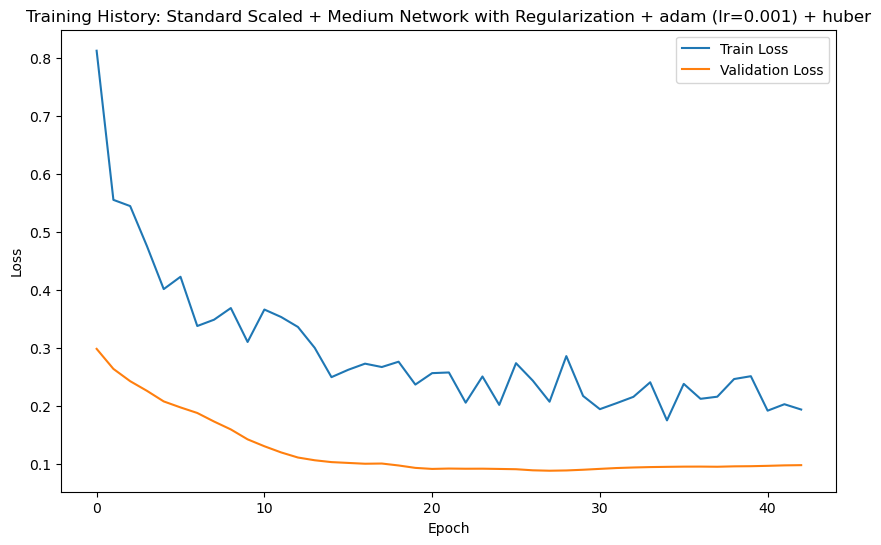



Training: Standard Scaled + Deep Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 2.1464 - root_mean_squared_error: 1.4443
Epoch 1: New best val_loss = 0.548427
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 1.5614 - root_mean_squared_error: 1.2200 - val_loss: 0.5484 - val_root_mean_squared_error: 0.6986 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9156 - root_mean_squared_error: 0.9248
Epoch 2: New best val_loss = 0.484154
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0513 - root_mean_squared_error: 0.9949 - val_loss: 0.4842 - val_root_mean_squared_error: 0.6509 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6723 - root_mean_squared_error: 0.7822
Epoch 3: New best val_loss = 0.405045
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0309 - root_mean_squared_error: 0.9808 - val_loss: 0.4050 - val_root_mean_squared_error: 0.5870 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7054 - root_mean_squared_error: 0.8031


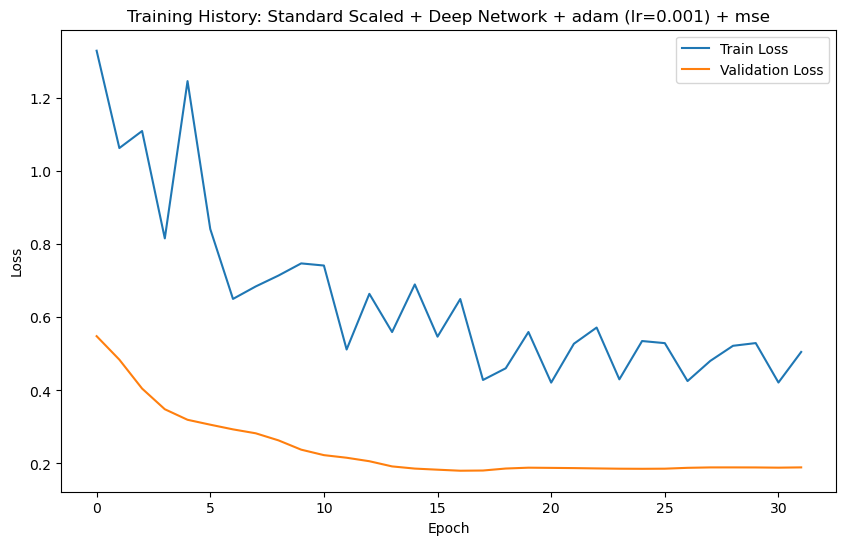



Training: Standard Scaled + Deep Network + adam (lr=0.0005) + mse


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 1.3488 - root_mean_squared_error: 1.1352
Epoch 1: New best val_loss = 0.635212
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 1.6332 - root_mean_squared_error: 1.2524 - val_loss: 0.6352 - val_root_mean_squared_error: 0.7584 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.5513 - root_mean_squared_error: 1.2212
Epoch 2: New best val_loss = 0.616442
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5502 - root_mean_squared_error: 1.2207 - val_loss: 0.6164 - val_root_mean_squared_error: 0.7459 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.6937 - root_mean_squared_error: 1.2781
Epoch 3: New best val_loss = 0.593924
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.5877 - root_mean_squared_error: 1.2357 - val_loss: 0.5939 - val_root_mean_squared_error: 0.7306 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7937 - root_me

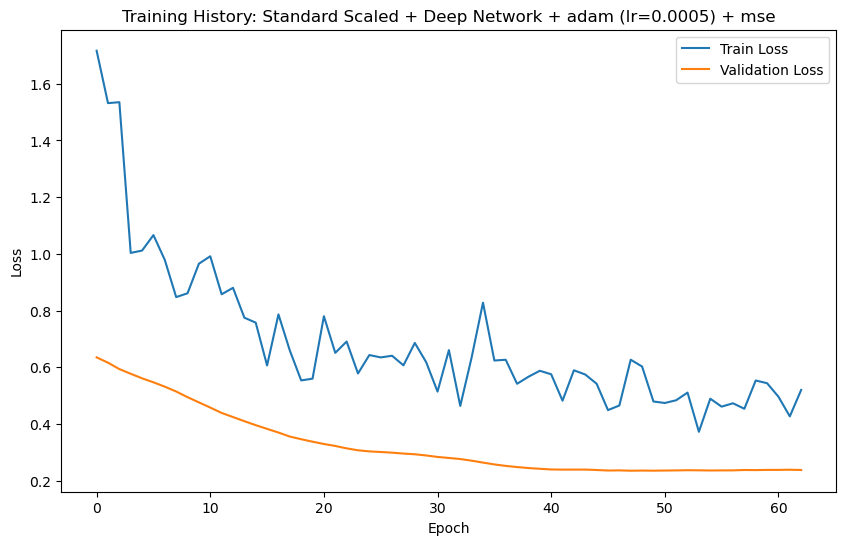



Training: Standard Scaled + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.9144 - root_mean_squared_error: 1.3618
Epoch 1: New best val_loss = 0.774544
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 1.9033 - root_mean_squared_error: 1.3576 - val_loss: 0.7745 - val_root_mean_squared_error: 0.8452 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.3175 - root_mean_squared_error: 1.1213
Epoch 2: New best val_loss = 0.487733
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2474 - root_mean_squared_error: 1.0894 - val_loss: 0.4877 - val_root_mean_squared_error: 0.6539 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2649 - root_mean_squared_error: 1.0976
Epoch 3: New best val_loss = 0.456508
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3333 - root_mean_squared_error: 1.1268 - val_loss: 0.4565 - val_root_mean_squared_error: 0.6295 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1533 - root_mean_squared_error: 1.0455


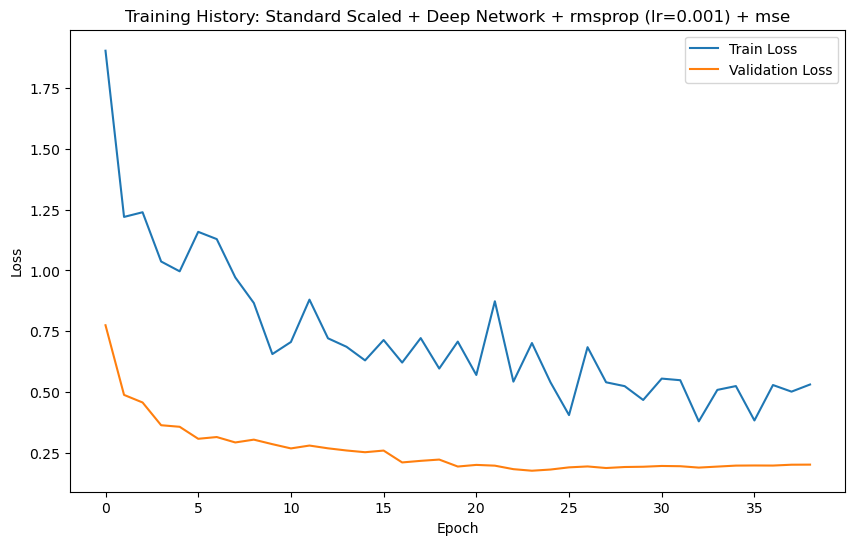



Training: Standard Scaled + Deep Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.7872 - root_mean_squared_error: 1.3519
Epoch 1: New best val_loss = 0.531872
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.7547 - root_mean_squared_error: 1.3468 - val_loss: 0.5319 - val_root_mean_squared_error: 0.9983 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7361 - root_mean_squared_error: 1.2965
Epoch 2: New best val_loss = 0.433486
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6629 - root_mean_squared_error: 1.2509 - val_loss: 0.4335 - val_root_mean_squared_error: 0.8811 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5109 - root_mean_squared_error: 1.0395
Epoch 3: New best val_loss = 0.345926
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5297 - root_mean_squared_error: 1.0898 - val_loss: 0.3459 - val_root_mean_squared_error: 0.7670 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5928 - root_mean_squared_error: 1.2293


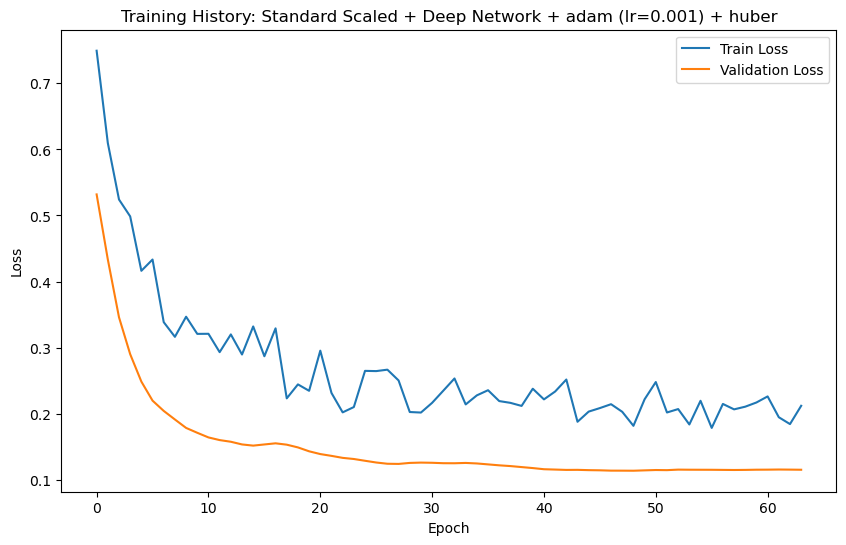



Training: Standard Scaled + Wide Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 3.2320 - root_mean_squared_error: 1.7613
Epoch 1: New best val_loss = 0.466823
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 2.3048 - root_mean_squared_error: 1.4669 - val_loss: 0.4668 - val_root_mean_squared_error: 0.5805 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.3689 - root_mean_squared_error: 1.1131
Epoch 2: New best val_loss = 0.378199
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2619 - root_mean_squared_error: 1.0631 - val_loss: 0.3782 - val_root_mean_squared_error: 0.4982 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9447 - root_mean_squared_error: 0.9022 - val_loss: 0.3786 - val_root_mean_squared_error: 0.4984 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9406 - root_mean_squared_error: 0.8991 - val_loss: 0.4134 - val_root_mean_squared_error: 0.5320 - learning_rate: 0.0010
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms

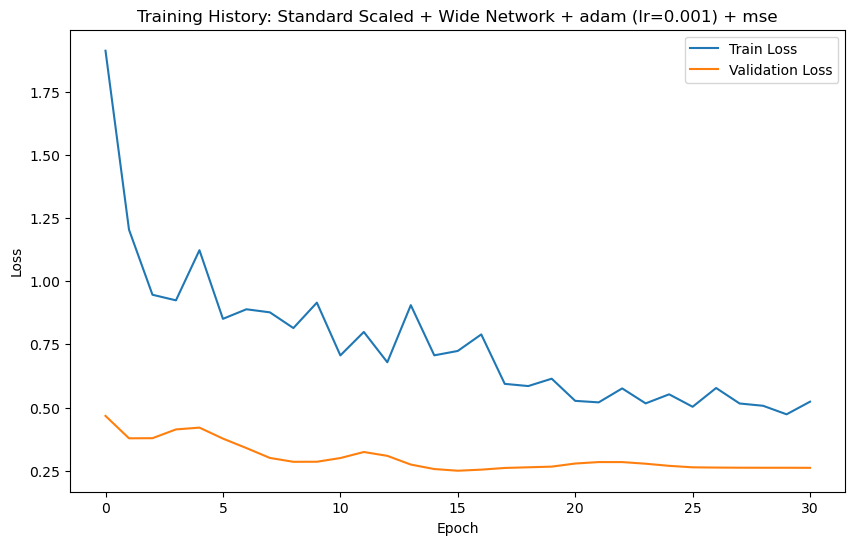



Training: Standard Scaled + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 2.9097 - root_mean_squared_error: 1.6673
Epoch 1: New best val_loss = 0.551639
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 2.7855 - root_mean_squared_error: 1.6294 - val_loss: 0.5516 - val_root_mean_squared_error: 0.6494 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.5200 - root_mean_squared_error: 1.5460
Epoch 2: New best val_loss = 0.486745
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.0331 - root_mean_squared_error: 1.3760 - val_loss: 0.4867 - val_root_mean_squared_error: 0.5973 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9905 - root_mean_squared_error: 0.9277
Epoch 3: New best val_loss = 0.457865
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0429 - root_mean_squared_error: 0.9553 - val_loss: 0.4579 - val_root_mean_squared_error: 0.5726 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1847 - root_mean_squared_e

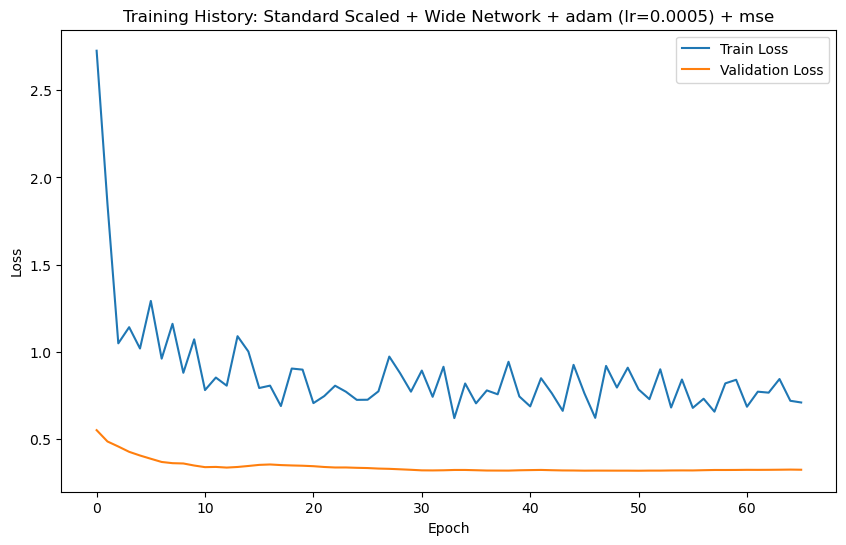



Training: Standard Scaled + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.0883 - root_mean_squared_error: 1.3995
Epoch 1: New best val_loss = 0.671068
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 1.6318 - root_mean_squared_error: 1.2224 - val_loss: 0.6711 - val_root_mean_squared_error: 0.7354 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.4560 - root_mean_squared_error: 1.1514
Epoch 2: New best val_loss = 0.428288
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2845 - root_mean_squared_error: 1.0735 - val_loss: 0.4283 - val_root_mean_squared_error: 0.5458 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9831 - root_mean_squared_error: 0.9234
Epoch 3: New best val_loss = 0.331635
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1179 - root_mean_squared_error: 0.9930 - val_loss: 0.3316 - val_root_mean_squared_error: 0.4485 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0903 - root_mean_squared_error: 0.9776 

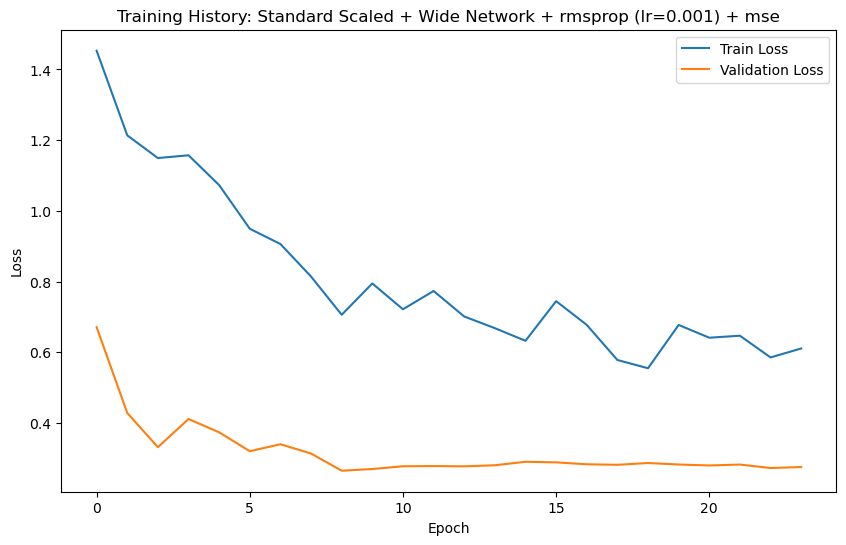



Training: Standard Scaled + Wide Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7080 - root_mean_squared_error: 1.2218
Epoch 1: New best val_loss = 0.385239
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.7034 - root_mean_squared_error: 1.2303 - val_loss: 0.3852 - val_root_mean_squared_error: 0.7222 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6589 - root_mean_squared_error: 1.2419
Epoch 2: New best val_loss = 0.325920
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6502 - root_mean_squared_error: 1.2176 - val_loss: 0.3259 - val_root_mean_squared_error: 0.6312 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5633 - root_mean_squared_error: 1.0519
Epoch 3: New best val_loss = 0.297269
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6331 - root_mean_squared_error: 1.1265 - val_loss: 0.2973 - val_root_mean_squared_error: 0.5815 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4978 - root_mean_squared_error: 0.9026


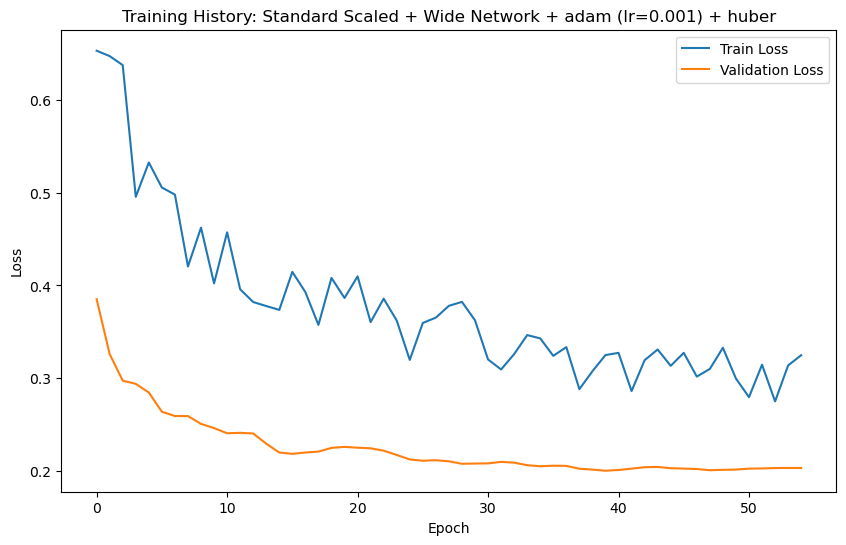



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 4.8021 - root_mean_squared_error: 2.1791
Epoch 1: New best val_loss = 0.564615
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 4.0117 - root_mean_squared_error: 1.9875 - val_loss: 0.5646 - val_root_mean_squared_error: 0.7149 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1542 - root_mean_squared_error: 1.4494
Epoch 2: New best val_loss = 0.427079
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.5056 - root_mean_squared_error: 1.5650 - val_loss: 0.4271 - val_root_mean_squared_error: 0.6111 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3655 - root_mean_squared_error: 1.1454
Epoch 3: New best val_loss = 0.391945
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3965 - root_mean_squared_error: 1.1583 - val_loss: 0.3919 - val_root_mean_squared_error: 0.5816 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1331 - root_mean_squared_error: 1.0355 

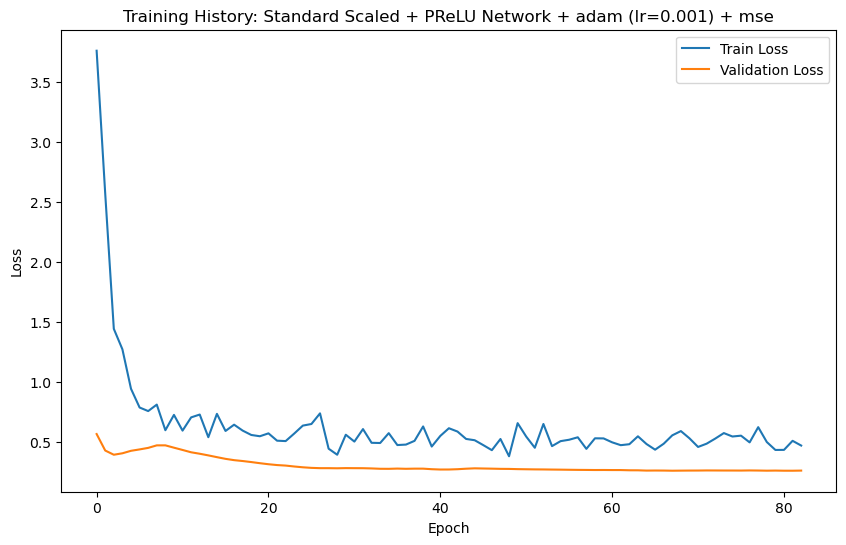



Training: Standard Scaled + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 4.7785 - root_mean_squared_error: 2.1738
Epoch 1: New best val_loss = 0.778404
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 4.2590 - root_mean_squared_error: 2.0495 - val_loss: 0.7784 - val_root_mean_squared_error: 0.8515 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.8227 - root_mean_squared_error: 1.6642
Epoch 2: New best val_loss = 0.608523
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5457 - root_mean_squared_error: 1.5778 - val_loss: 0.6085 - val_root_mean_squared_error: 0.7451 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5348 - root_mean_squared_error: 1.2172
Epoch 3: New best val_loss = 0.483169
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7368 - root_mean_squared_error: 1.2967 - val_loss: 0.4832 - val_root_mean_squared_error: 0.6556 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.0540 - root_mean_squared_e

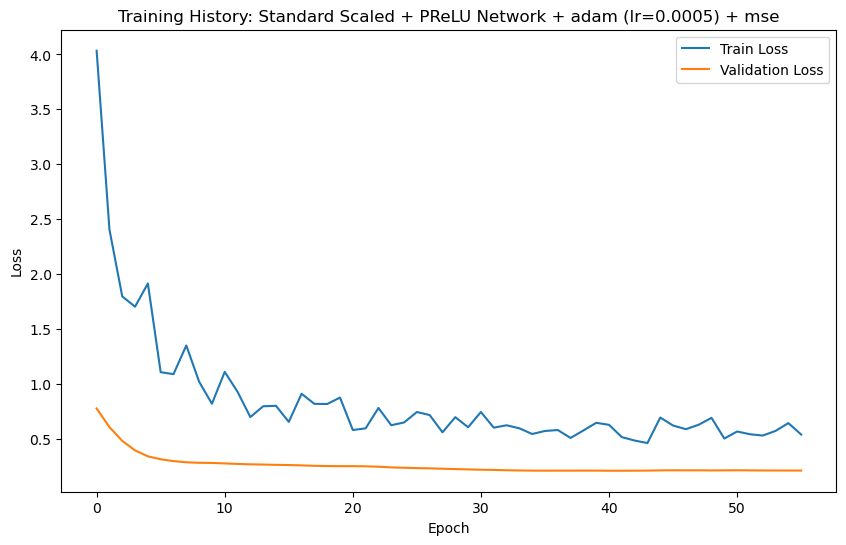



Training: Standard Scaled + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 1.6668 - root_mean_squared_error: 1.2702
Epoch 1: New best val_loss = 0.358738
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 1.4412 - root_mean_squared_error: 1.1757 - val_loss: 0.3587 - val_root_mean_squared_error: 0.5526 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9509 - root_mean_squared_error: 0.9474
Epoch 2: New best val_loss = 0.295044
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8571 - root_mean_squared_error: 0.8960 - val_loss: 0.2950 - val_root_mean_squared_error: 0.4916 - learning_rate: 0.0010
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9480 - root_mean_squared_error: 0.9441 - val_loss: 0.3051 - val_root_mean_squared_error: 0.5016 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7033 - root_mean_squared_error: 0.8062
Epoch 4: New best val_loss = 0.282025
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7080 - root_mean_squared_error: 0.8090 

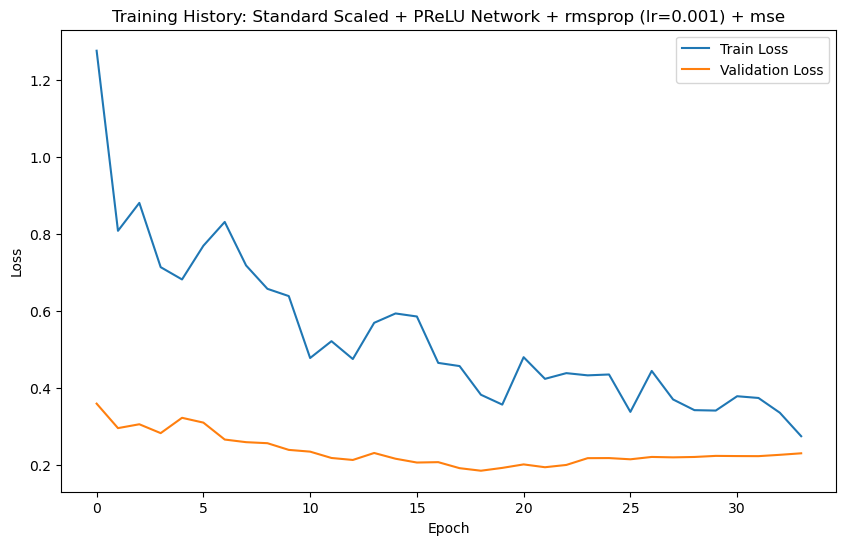



Training: Standard Scaled + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.7154 - root_mean_squared_error: 1.3303
Epoch 1: New best val_loss = 0.379990
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.6978 - root_mean_squared_error: 1.3301 - val_loss: 0.3800 - val_root_mean_squared_error: 0.8217 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3135 - root_mean_squared_error: 0.7988
Epoch 2: New best val_loss = 0.372675
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4280 - root_mean_squared_error: 0.9397 - val_loss: 0.3727 - val_root_mean_squared_error: 0.8057 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3509 - root_mean_squared_error: 0.8351
Epoch 3: New best val_loss = 0.366240
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3719 - root_mean_squared_error: 0.8511 - val_loss: 0.3662 - val_root_mean_squared_error: 0.7984 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3945 - root_mean_squared_error: 1.1014


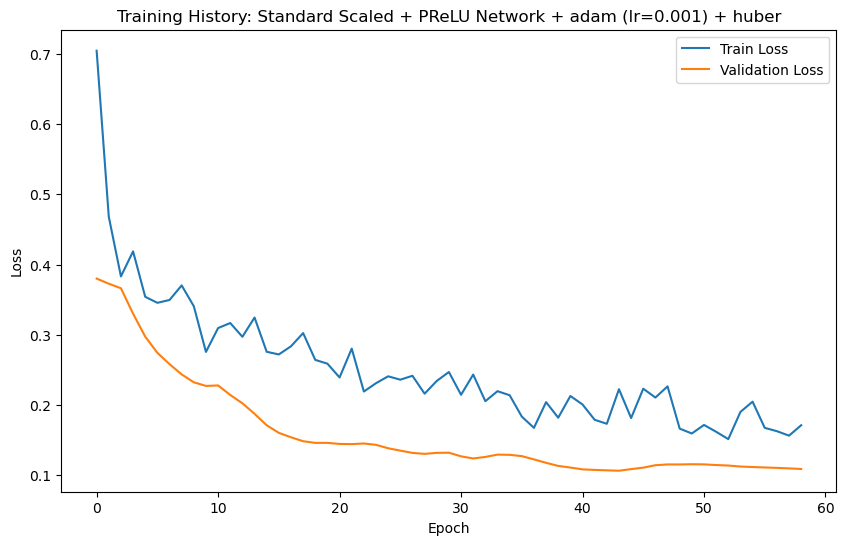



Training: Log Transformed + Small Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 673ms/step - loss: 1.1633 - root_mean_squared_error: 1.0786
Epoch 1: New best val_loss = 0.585865
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.0678 - root_mean_squared_error: 1.0330 - val_loss: 0.5859 - val_root_mean_squared_error: 0.7654 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8318 - root_mean_squared_error: 0.9120
Epoch 2: New best val_loss = 0.444142
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8343 - root_mean_squared_error: 0.9127 - val_loss: 0.4441 - val_root_mean_squared_error: 0.6664 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6692 - root_mean_squared_error: 0.8180
Epoch 3: New best val_loss = 0.356941
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6012 - root_mean_squared_error: 0.7750 - val_loss: 0.3569 - val_root_mean_squared_error: 0.5974 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8692 - root_mean_squared_error: 0.93

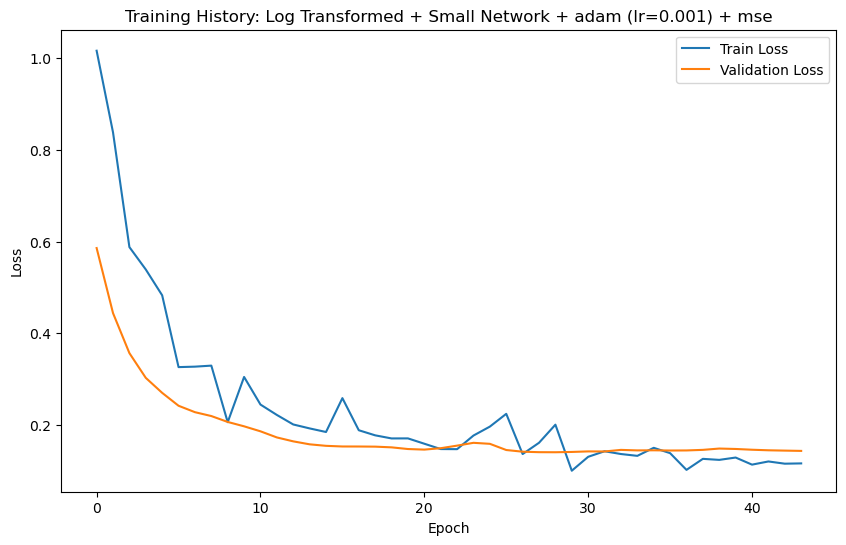



Training: Log Transformed + Small Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step - loss: 2.0990 - root_mean_squared_error: 1.4488
Epoch 1: New best val_loss = 1.113504
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 1.8235 - root_mean_squared_error: 1.3491 - val_loss: 1.1135 - val_root_mean_squared_error: 1.0552 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.2732 - root_mean_squared_error: 1.1284
Epoch 2: New best val_loss = 0.879685
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.3190 - root_mean_squared_error: 1.1484 - val_loss: 0.8797 - val_root_mean_squared_error: 0.9379 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1061 - root_mean_squared_error: 1.0517
Epoch 3: New best val_loss = 0.706778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.2298 - root_mean_squared_error: 1.1085 - val_loss: 0.7068 - val_root_mean_squared_error: 0.8407 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9341 - root_mean_squared

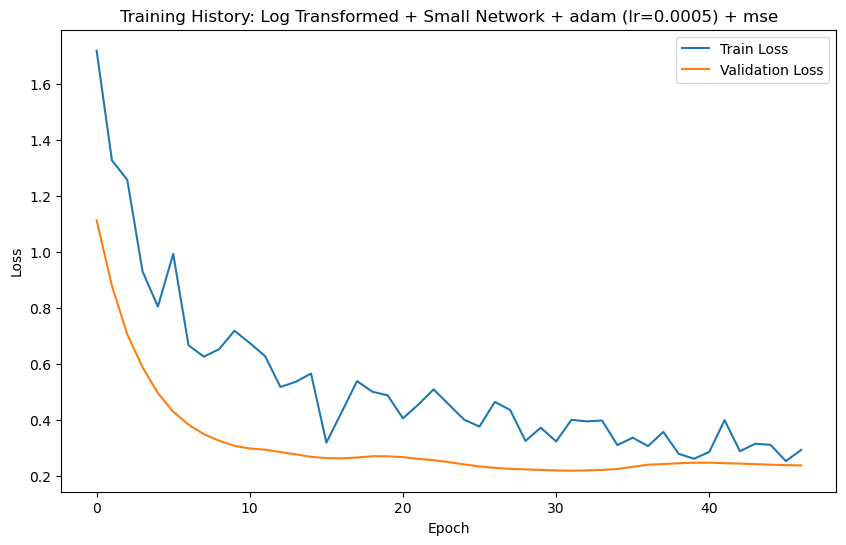



Training: Log Transformed + Small Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 2s 637ms/step - loss: 1.6226 - root_mean_squared_error: 1.2738
Epoch 1: New best val_loss = 0.647607
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 1.3513 - root_mean_squared_error: 1.1605 - val_loss: 0.6476 - val_root_mean_squared_error: 0.8047 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9090 - root_mean_squared_error: 0.9534
Epoch 2: New best val_loss = 0.428003
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7765 - root_mean_squared_error: 0.8803 - val_loss: 0.4280 - val_root_mean_squared_error: 0.6542 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6465 - root_mean_squared_error: 0.8041
Epoch 3: New best val_loss = 0.338534
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5200 - root_mean_squared_error: 0.7197 - val_loss: 0.3385 - val_root_mean_squared_error: 0.5818 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1405 - root_mean_squared_error: 1.06

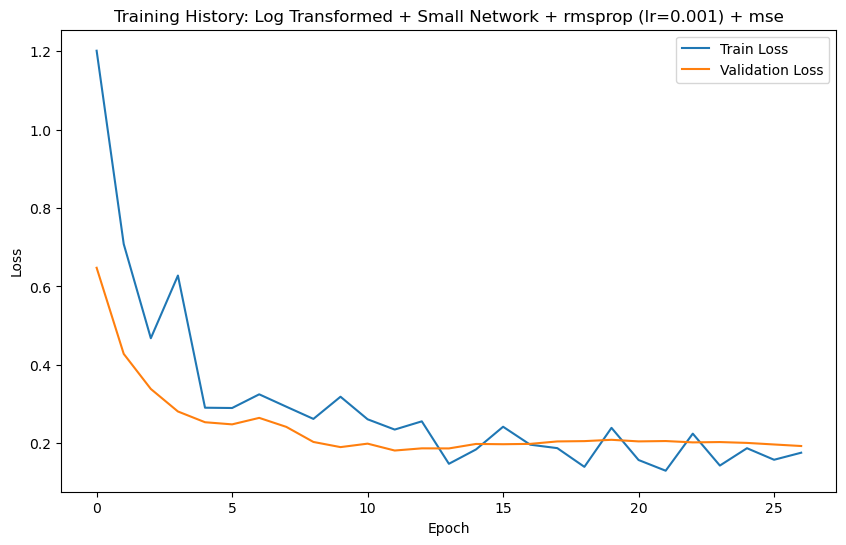



Training: Log Transformed + Small Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 767ms/step - loss: 1.0895 - root_mean_squared_error: 2.0367
Epoch 1: New best val_loss = 0.396162
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.9917 - root_mean_squared_error: 1.8085 - val_loss: 0.3962 - val_root_mean_squared_error: 0.9265 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4933 - root_mean_squared_error: 1.1838
Epoch 2: New best val_loss = 0.255958
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5489 - root_mean_squared_error: 1.1879 - val_loss: 0.2560 - val_root_mean_squared_error: 0.7338 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4237 - root_mean_squared_error: 0.9738
Epoch 3: New best val_loss = 0.175368
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3829 - root_mean_squared_error: 0.9247 - val_loss: 0.1754 - val_root_mean_squared_error: 0.6023 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3780 - root_mean_squared_error: 1.03

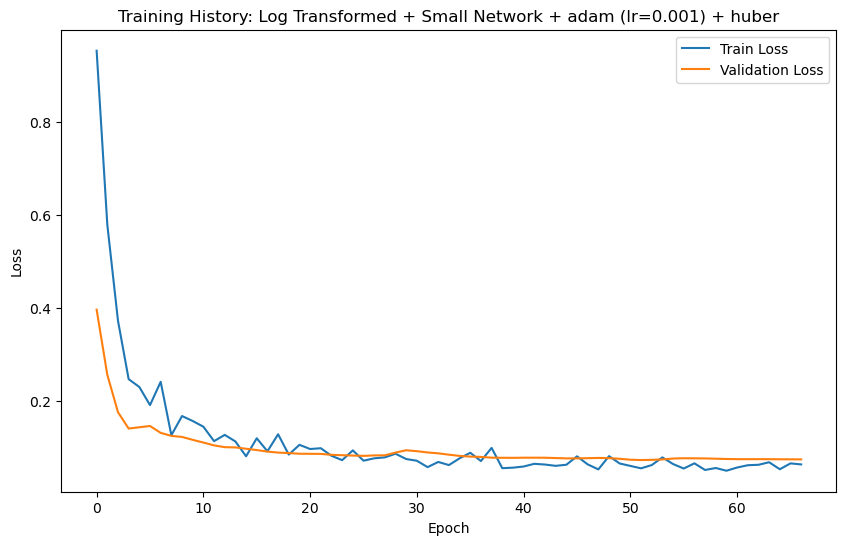



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 2.4298 - root_mean_squared_error: 1.5516
Epoch 1: New best val_loss = 1.225038
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 2.1254 - root_mean_squared_error: 1.4487 - val_loss: 1.2250 - val_root_mean_squared_error: 1.0966 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1994 - root_mean_squared_error: 1.4754
Epoch 2: New best val_loss = 0.952135
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7528 - root_mean_squared_error: 1.3129 - val_loss: 0.9521 - val_root_mean_squared_error: 0.9642 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.4384 - root_mean_squared_error: 1.1899
Epoch 3: New best val_loss = 0.729514
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4278 - root_mean_squared_error: 1.1843 - val_loss: 0.7295 - val_root_mean_squared_error: 0.8408 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5958 - root_mean_squared_error: 1.2543


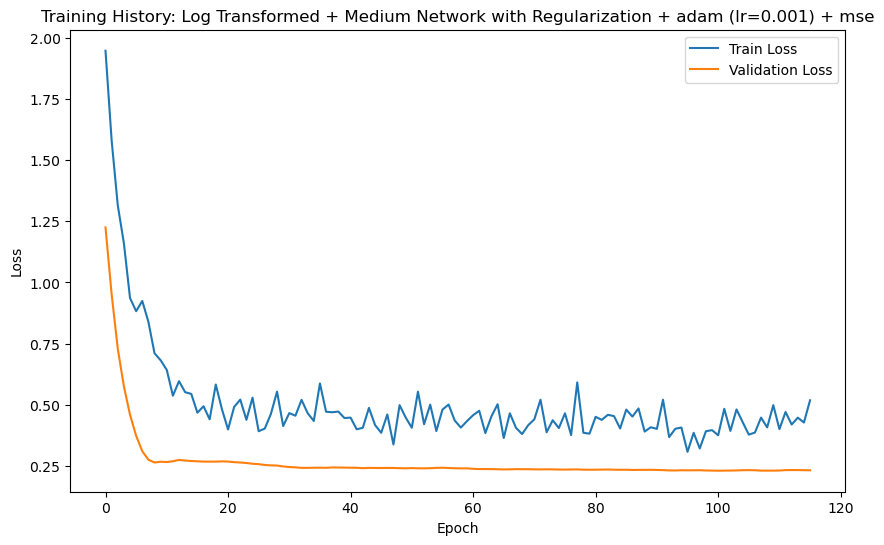



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 1.6874 - root_mean_squared_error: 1.2904
Epoch 1: New best val_loss = 0.640231
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 1.6005 - root_mean_squared_error: 1.2561 - val_loss: 0.6402 - val_root_mean_squared_error: 0.7861 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5522 - root_mean_squared_error: 1.2369
Epoch 2: New best val_loss = 0.600675
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5496 - root_mean_squared_error: 1.2358 - val_loss: 0.6007 - val_root_mean_squared_error: 0.7605 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.9496 - root_mean_squared_error: 1.3883
Epoch 3: New best val_loss = 0.568095
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6623 - root_mean_squared_error: 1.2791 - val_loss: 0.5681 - val_root_mean_squared_error: 0.7388 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4859 - root_mean_squared_e

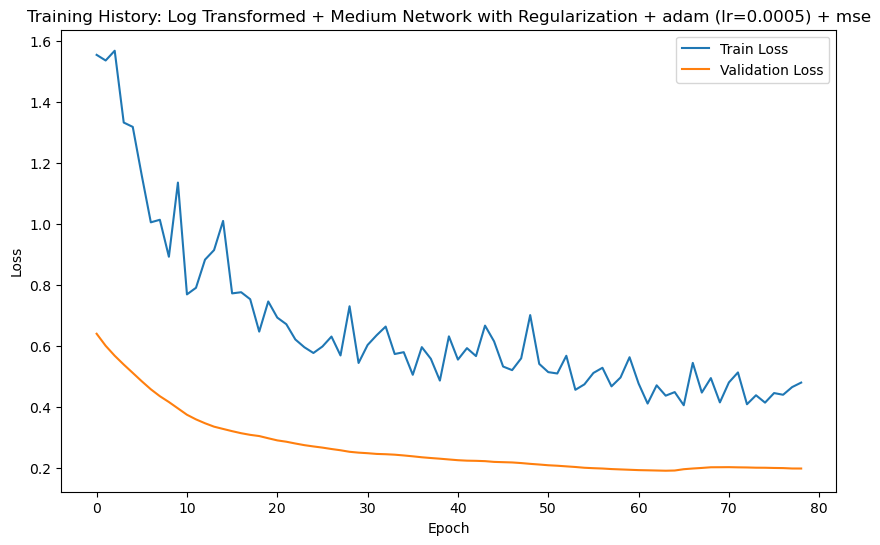



Training: Log Transformed + Medium Network with Regularization + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.4750 - root_mean_squared_error: 1.5660
Epoch 1: New best val_loss = 0.520858
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.6592 - root_mean_squared_error: 1.2708 - val_loss: 0.5209 - val_root_mean_squared_error: 0.7058 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5123 - root_mean_squared_error: 1.2205
Epoch 2: New best val_loss = 0.411888
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2866 - root_mean_squared_error: 1.1217 - val_loss: 0.4119 - val_root_mean_squared_error: 0.6239 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0630 - root_mean_squared_error: 1.0200
Epoch 3: New best val_loss = 0.357041
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9964 - root_mean_squared_error: 0.9864 - val_loss: 0.3570 - val_root_mean_squared_error: 0.5782 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.5099 - root_mean_squared_error: 1.2195


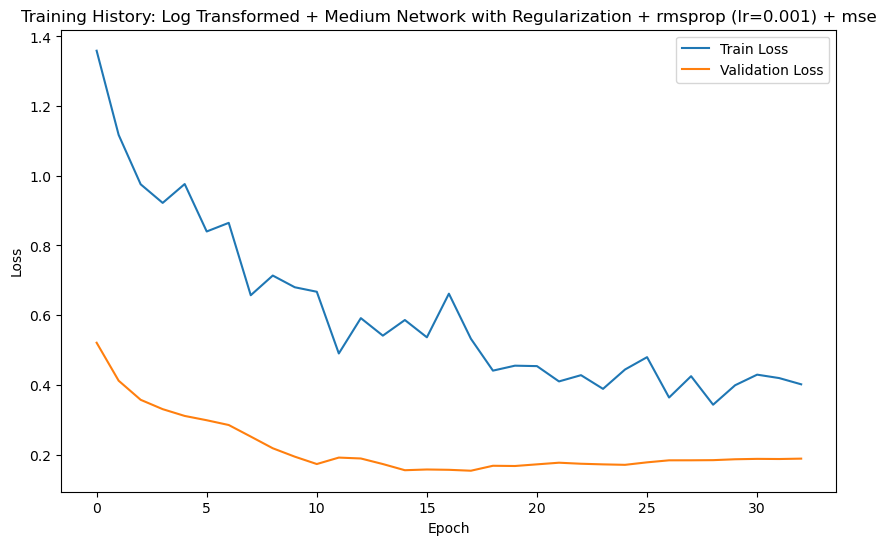



Training: Log Transformed + Medium Network with Regularization + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.5082 - root_mean_squared_error: 1.0895
Epoch 1: New best val_loss = 0.301654
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.7485 - root_mean_squared_error: 1.4949 - val_loss: 0.3017 - val_root_mean_squared_error: 0.7776 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8255 - root_mean_squared_error: 1.7908
Epoch 2: New best val_loss = 0.247077
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7182 - root_mean_squared_error: 1.5697 - val_loss: 0.2471 - val_root_mean_squared_error: 0.6828 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4724 - root_mean_squared_error: 1.0137
Epoch 3: New best val_loss = 0.215053
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5516 - root_mean_squared_error: 1.1941 - val_loss: 0.2151 - val_root_mean_squared_error: 0.6266 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4542 - root_mean_squared_error: 1.0946


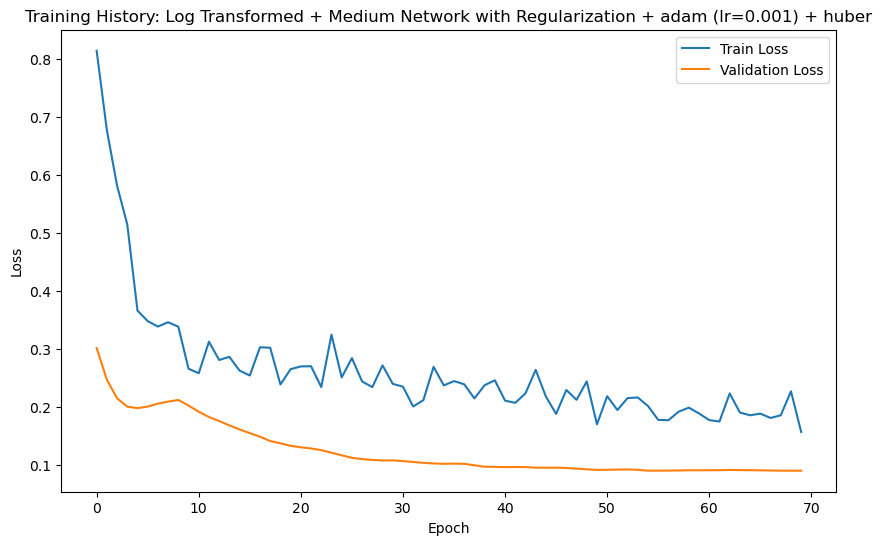



Training: Log Transformed + Deep Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 3.1389 - root_mean_squared_error: 1.7546
Epoch 1: New best val_loss = 0.654109
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 2.4269 - root_mean_squared_error: 1.5327 - val_loss: 0.6541 - val_root_mean_squared_error: 0.7705 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6444 - root_mean_squared_error: 0.7641
Epoch 2: New best val_loss = 0.568458
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0917 - root_mean_squared_error: 1.0079 - val_loss: 0.5685 - val_root_mean_squared_error: 0.7127 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8976 - root_mean_squared_error: 0.9149
Epoch 3: New best val_loss = 0.510073
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0587 - root_mean_squared_error: 0.9975 - val_loss: 0.5101 - val_root_mean_squared_error: 0.6705 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2166 - root_mean_squared_error: 1.0752


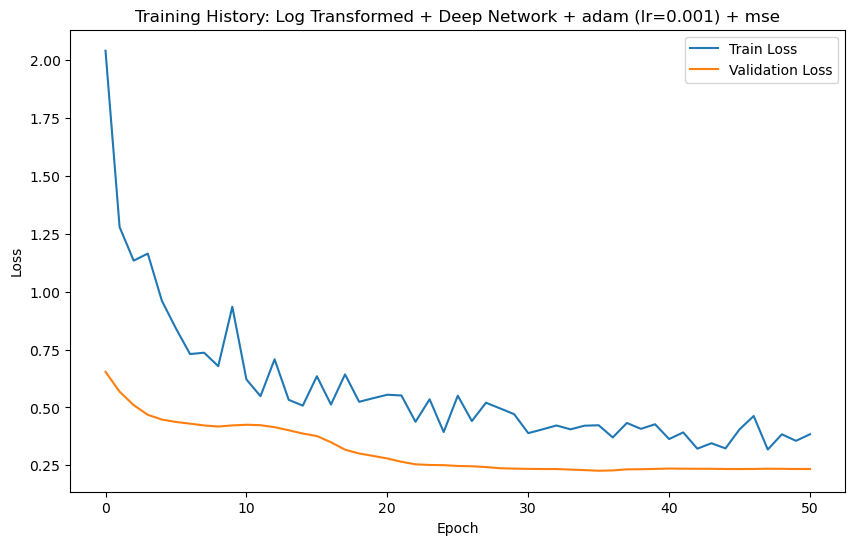



Training: Log Transformed + Deep Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 3.2270 - root_mean_squared_error: 1.7796
Epoch 1: New best val_loss = 0.814497
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 3.0503 - root_mean_squared_error: 1.7289 - val_loss: 0.8145 - val_root_mean_squared_error: 0.8685 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.1603 - root_mean_squared_error: 1.4492
Epoch 2: New best val_loss = 0.742103
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.9437 - root_mean_squared_error: 1.3717 - val_loss: 0.7421 - val_root_mean_squared_error: 0.8258 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.6609 - root_mean_squared_error: 1.2652
Epoch 3: New best val_loss = 0.680383
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.3945 - root_mean_squared_error: 1.1533 - val_loss: 0.6804 - val_root_mean_squared_error: 0.7876 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0633 - root_mean_squared_e

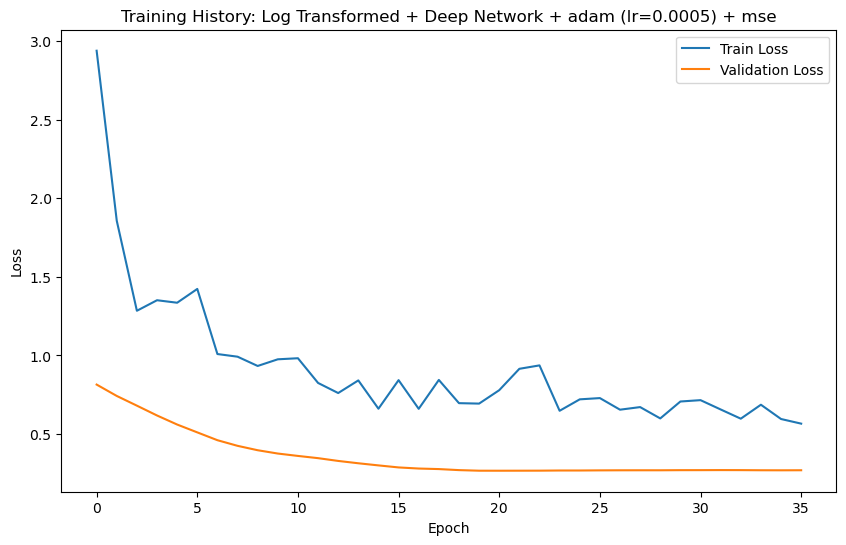



Training: Log Transformed + Deep Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.3088 - root_mean_squared_error: 1.4997
Epoch 1: New best val_loss = 0.556430
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 1.7520 - root_mean_squared_error: 1.2952 - val_loss: 0.5564 - val_root_mean_squared_error: 0.7047 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1553 - root_mean_squared_error: 1.0467
Epoch 2: New best val_loss = 0.505891
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1238 - root_mean_squared_error: 1.0314 - val_loss: 0.5059 - val_root_mean_squared_error: 0.6679 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0313 - root_mean_squared_error: 0.9857
Epoch 3: New best val_loss = 0.492778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9822 - root_mean_squared_error: 0.9601 - val_loss: 0.4928 - val_root_mean_squared_error: 0.6580 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7371 - root_mean_squared_error: 0.8230


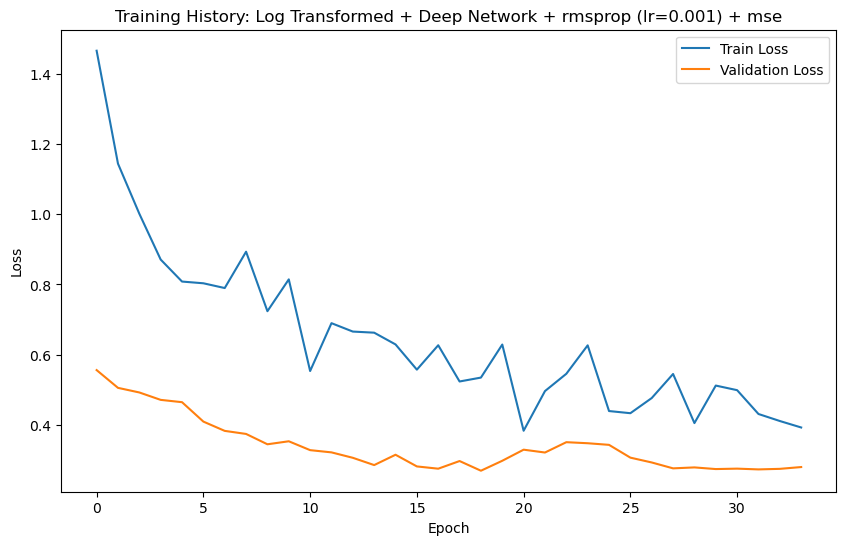



Training: Log Transformed + Deep Network + adam (lr=0.001) + huber


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 1.5209 - root_mean_squared_error: 2.1849
Epoch 1: New best val_loss = 0.659806
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.3543 - root_mean_squared_error: 2.0639 - val_loss: 0.6598 - val_root_mean_squared_error: 1.1732 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3187 - root_mean_squared_error: 2.0673
Epoch 2: New best val_loss = 0.588994
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1589 - root_mean_squared_error: 1.8639 - val_loss: 0.5890 - val_root_mean_squared_error: 1.0841 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0254 - root_mean_squared_error: 1.5831
Epoch 3: New best val_loss = 0.519494
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9407 - root_mean_squared_error: 1.5488 - val_loss: 0.5195 - val_root_mean_squared_error: 0.9965 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8974 - root_mean_squared_er

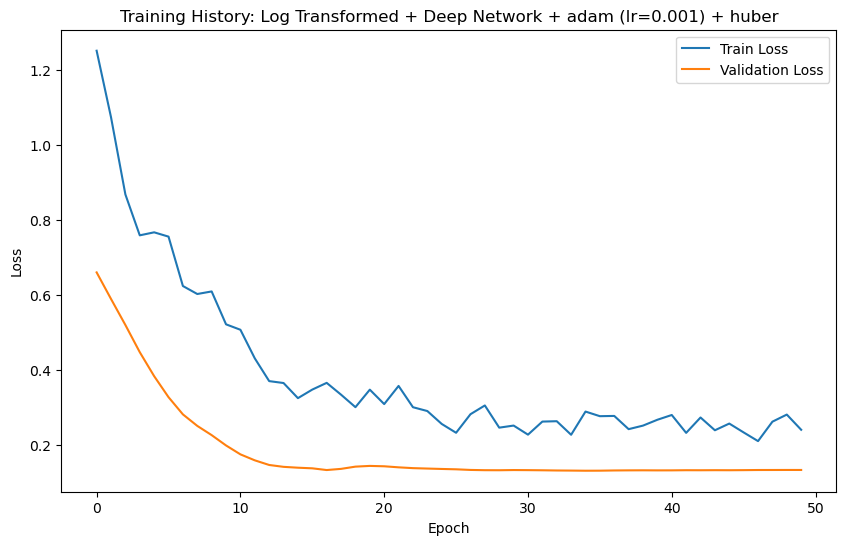



Training: Log Transformed + Wide Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.3482 - root_mean_squared_error: 1.4894
Epoch 1: New best val_loss = 0.668358
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 1.7416 - root_mean_squared_error: 1.2641 - val_loss: 0.6684 - val_root_mean_squared_error: 0.7337 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5055 - root_mean_squared_error: 1.1728
Epoch 2: New best val_loss = 0.477887
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4575 - root_mean_squared_error: 1.1521 - val_loss: 0.4779 - val_root_mean_squared_error: 0.5896 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.2518 - root_mean_squared_error: 1.0590
Epoch 3: New best val_loss = 0.423495
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2176 - root_mean_squared_error: 1.0425 - val_loss: 0.4235 - val_root_mean_squared_error: 0.5414 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2175 - root_mean_squared_error: 1.0426


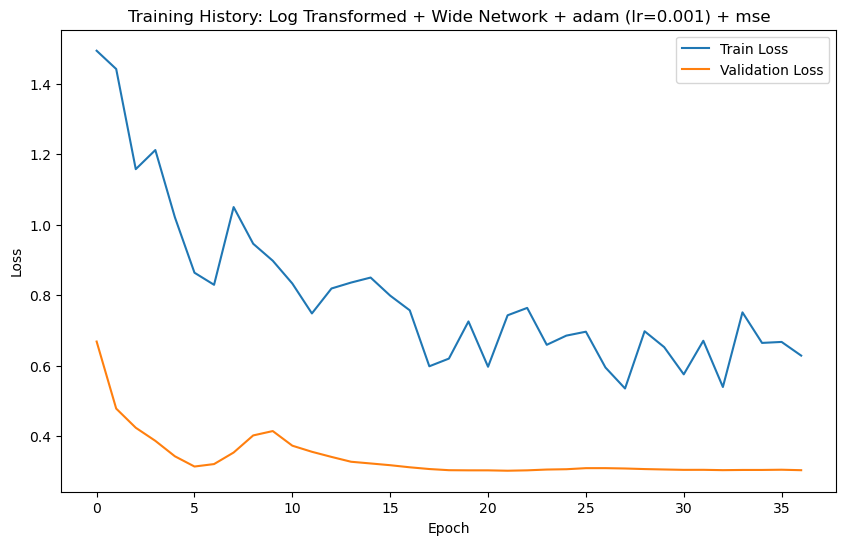



Training: Log Transformed + Wide Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 3.3968 - root_mean_squared_error: 1.8076
Epoch 1: New best val_loss = 0.754824
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 2.9818 - root_mean_squared_error: 1.6874 - val_loss: 0.7548 - val_root_mean_squared_error: 0.7908 - learning_rate: 5.0000e-04
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.2861 - root_mean_squared_error: 1.4686
Epoch 2: New best val_loss = 0.614018
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.9467 - root_mean_squared_error: 1.3461 - val_loss: 0.6140 - val_root_mean_squared_error: 0.6961 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.6077 - root_mean_squared_error: 1.2159
Epoch 3: New best val_loss = 0.527167
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6099 - root_mean_squared_error: 1.2167 - val_loss: 0.5272 - val_root_mean_squared_error: 0.6306 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.5374 - root_mean_squared_e

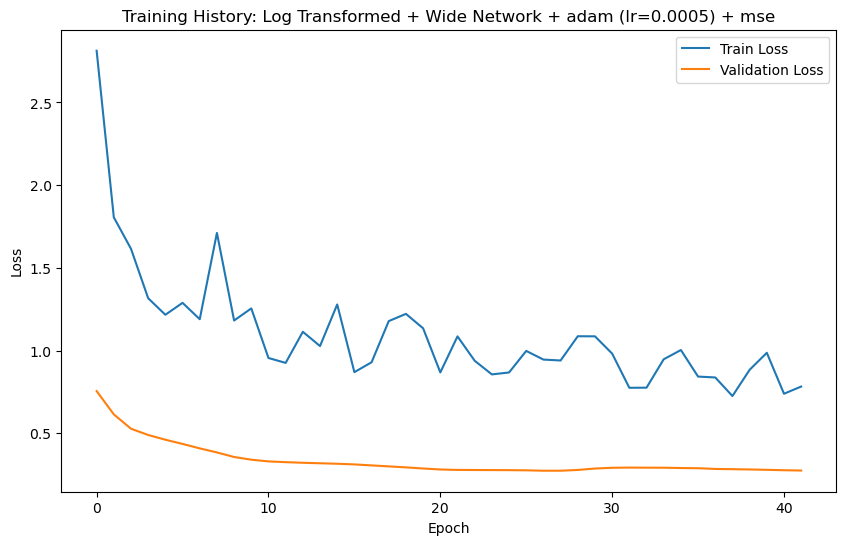



Training: Log Transformed + Wide Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3.0204 - root_mean_squared_error: 1.7002
Epoch 1: New best val_loss = 0.639590
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 1.9931 - root_mean_squared_error: 1.3556 - val_loss: 0.6396 - val_root_mean_squared_error: 0.7137 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.6672 - root_mean_squared_error: 1.2397
Epoch 2: New best val_loss = 0.577202
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3561 - root_mean_squared_error: 1.1055 - val_loss: 0.5772 - val_root_mean_squared_error: 0.6684 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9046 - root_mean_squared_error: 0.8799
Epoch 3: New best val_loss = 0.406161
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9882 - root_mean_squared_error: 0.9254 - val_loss: 0.4062 - val_root_mean_squared_error: 0.5250 - learning_rate: 0.0010
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9224 - root_mean_squared_error: 0.8897 

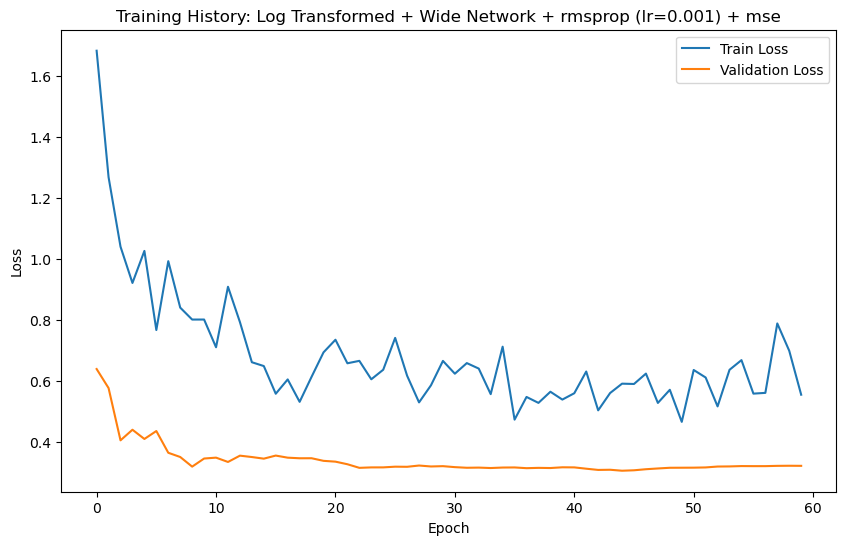



Training: Log Transformed + Wide Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 1.1024 - root_mean_squared_error: 1.7650
Epoch 1: New best val_loss = 0.446947
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.8426 - root_mean_squared_error: 1.4552 - val_loss: 0.4469 - val_root_mean_squared_error: 0.8138 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6886 - root_mean_squared_error: 1.2740
Epoch 2: New best val_loss = 0.367525
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6733 - root_mean_squared_error: 1.2298 - val_loss: 0.3675 - val_root_mean_squared_error: 0.6953 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5535 - root_mean_squared_error: 1.0512
Epoch 3: New best val_loss = 0.311259
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5625 - root_mean_squared_error: 1.0273 - val_loss: 0.3113 - val_root_mean_squared_error: 0.6025 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4586 - root_mean_squared_error: 0.8867


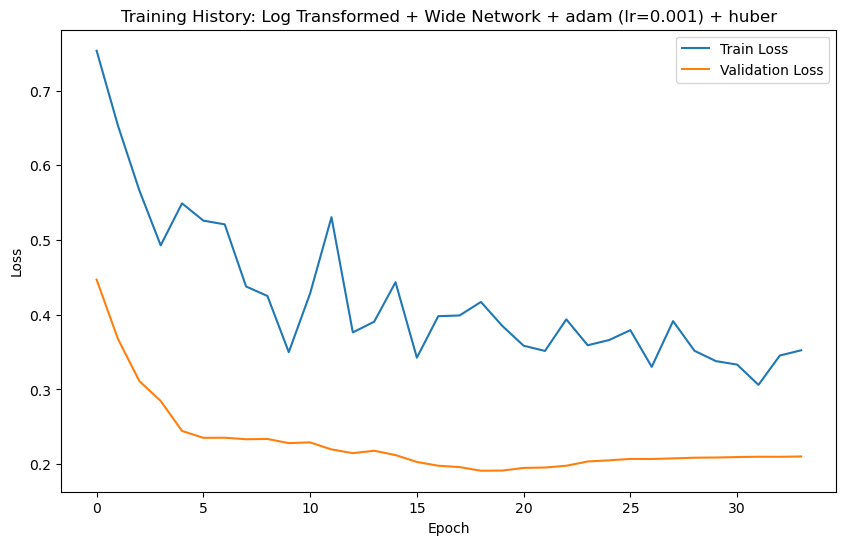



Training: Log Transformed + PReLU Network + adam (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 2.3063 - root_mean_squared_error: 1.5010
Epoch 1: New best val_loss = 0.842331
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 1.6891 - root_mean_squared_error: 1.2727 - val_loss: 0.8423 - val_root_mean_squared_error: 0.8883 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.4489 - root_mean_squared_error: 1.1814
Epoch 2: New best val_loss = 0.717454
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1696 - root_mean_squared_error: 1.0547 - val_loss: 0.7175 - val_root_mean_squared_error: 0.8150 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.3644 - root_mean_squared_error: 1.1450
Epoch 3: New best val_loss = 0.603899
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1133 - root_mean_squared_error: 1.0280 - val_loss: 0.6039 - val_root_mean_squared_error: 0.7420 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0076 - root_mean_squared_error: 0.9769


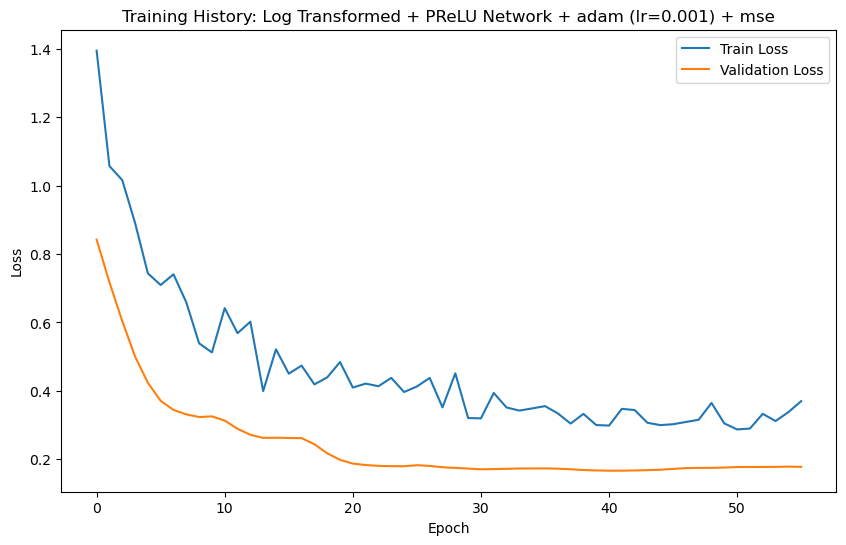



Training: Log Transformed + PReLU Network + adam (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - loss: 1.7284 - root_mean_squared_error: 1.2942
Epoch 1: New best val_loss = 0.937141
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 1.6612 - root_mean_squared_error: 1.2679 - val_loss: 0.9371 - val_root_mean_squared_error: 0.9400 - learning_rate: 5.0000e-04
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3244 - root_mean_squared_error: 1.1271 - val_loss: 0.9388 - val_root_mean_squared_error: 0.9409 - learning_rate: 5.0000e-04
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.2329 - root_mean_squared_error: 1.0860
Epoch 3: New best val_loss = 0.918806
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.1648 - root_mean_squared_error: 1.0540 - val_loss: 0.9188 - val_root_mean_squared_error: 0.9302 - learning_rate: 5.0000e-04
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0726 - root_mean_squared_error: 1.0095
Epoch 4: New best val_loss = 0.892475
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.1296 - root_mean_squared_e

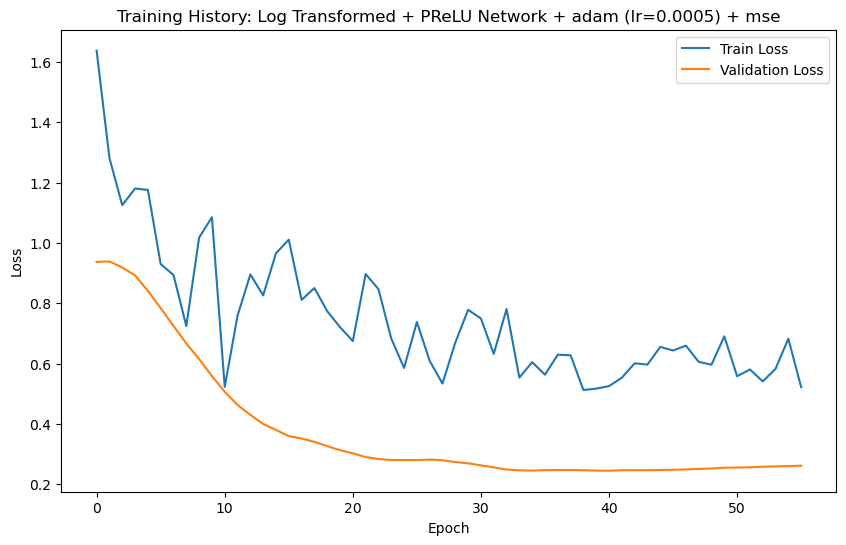



Training: Log Transformed + PReLU Network + rmsprop (lr=0.001) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 2.2445 - root_mean_squared_error: 1.4803
Epoch 1: New best val_loss = 0.458037
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.5919 - root_mean_squared_error: 1.2354 - val_loss: 0.4580 - val_root_mean_squared_error: 0.6361 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7012 - root_mean_squared_error: 0.8048
Epoch 2: New best val_loss = 0.421828
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8822 - root_mean_squared_error: 0.9090 - val_loss: 0.4218 - val_root_mean_squared_error: 0.6069 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6473 - root_mean_squared_error: 0.7706
Epoch 3: New best val_loss = 0.372122
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7123 - root_mean_squared_error: 0.8114 - val_loss: 0.3721 - val_root_mean_squared_error: 0.5645 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5683 - root_mean_squared_error: 0.7175


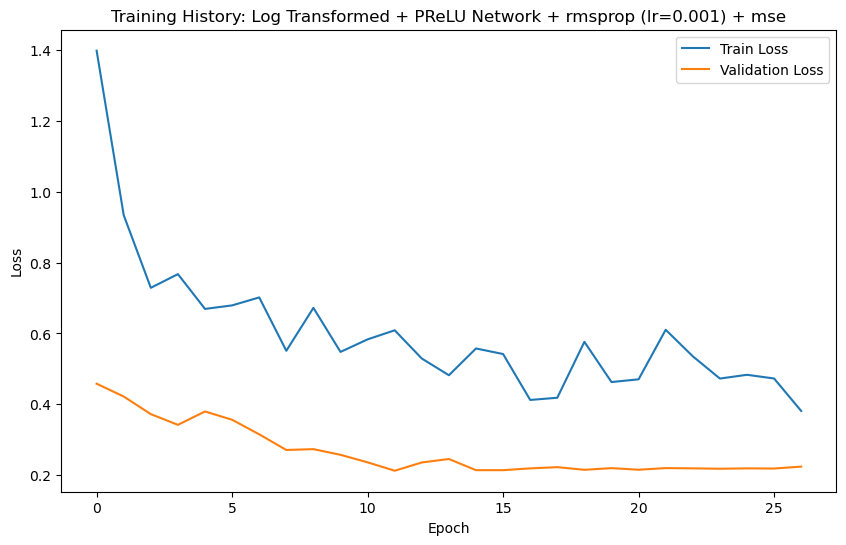



Training: Log Transformed + PReLU Network + adam (lr=0.001) + huber
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - loss: 0.7984 - root_mean_squared_error: 1.4899
Epoch 1: New best val_loss = 0.311294
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.7182 - root_mean_squared_error: 1.3534 - val_loss: 0.3113 - val_root_mean_squared_error: 0.7253 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4619 - root_mean_squared_error: 0.9508
Epoch 2: New best val_loss = 0.311258
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4755 - root_mean_squared_error: 1.0324 - val_loss: 0.3113 - val_root_mean_squared_error: 0.7212 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3035 - root_mean_squared_error: 0.7135
Epoch 3: New best val_loss = 0.297930
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3708 - root_mean_squared_error: 0.8353 - val_loss: 0.2979 - val_root_mean_squared_error: 0.7014 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3219 - root_mean_squared_error: 0.7907


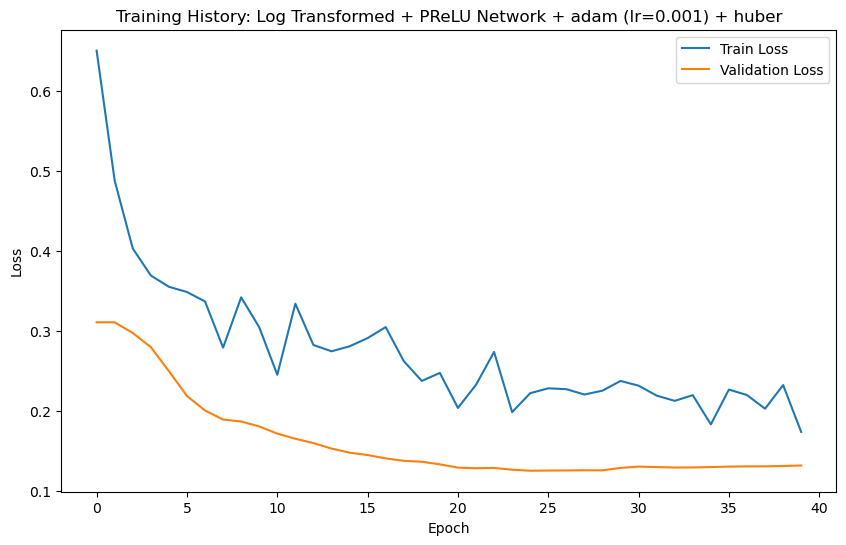

In [7]:
# Store results
search_results = []

# Systematic search through combinations
for target in target_options:
    for arch in architecture_search_space:
        for params in training_params:
            # Create a unique name for this configuration
            config_name = f"{target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
            print(f"\n\nTraining: {config_name}")
            
            # Create model
            model = create_model_architecture(X_train_main.shape[1], arch)
            
            # Train model
            trained_model, history, training_time = train_model(
                target['X_train'], target['y_train'],
                target['X_val'], target['y_val'],
                model=model,
                batch_size=params['batch_size'],
                optimizer=params['optimizer'],
                learning_rate=params['learning_rate'],
                loss=params['loss'],
                patience=15
            )
            
            # Evaluate on test set
            y_pred = trained_model.predict(target['X_test'])
            
            # Convert to original scale
            y_pred_original = target['inverse_func'](y_pred)
            y_test_original = target['inverse_func'](target['y_test'])
            
            # Calculate metrics
            rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
            mae = mean_absolute_error(y_test_original, y_pred_original)
            r2 = r2_score(y_test_original, y_pred_original)
            
            print(f"Results for {config_name}:")
            print(f"RMSE: {rmse:.2f}")
            print(f"MAE: {mae:.2f}")
            print(f"R² Score: {r2:.4f}")
            print(f"Training time: {training_time:.2f} seconds")
            
            # Plot learning curves
            plt.figure(figsize=(10, 6))
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title(f'Training History: {config_name}')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend()
            plt.show()
            
            # Store results
            search_results.append({
                'name': config_name,
                'architecture': arch['name'],
                'target_transformation': target['name'],
                'optimizer': params['optimizer'],
                'learning_rate': params['learning_rate'],
                'loss': params['loss'],
                'batch_size': params['batch_size'],
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'training_time': training_time,
                'model': trained_model,
                'history': history,
                'y_pred': y_pred_original,
                'y_test': y_test_original
            })

## 8. Analyze Architecture Search Results

,Config,Architecture,Target,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
6,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,Standard Scaled,rmsprop,0.0010,mse,3835.118379,2195.063664,0.820559,5.030049
18,Standard Scaled + PReLU Network + rmsprop (lr=...,PReLU Network,Standard Scaled,rmsprop,0.0010,mse,3837.604616,2244.104868,0.820327,4.708141
16,Standard Scaled + PReLU Network + adam (lr=0.0...,PReLU Network,Standard Scaled,adam,0.0010,mse,3846.867951,2165.638359,0.819458,8.997687
10,Standard Scaled + Deep Network + rmsprop (lr=0...,Deep Network,Standard Scaled,rmsprop,0.0010,mse,3876.285791,2300.330529,0.816686,5.289137
4,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,Standard Scaled,adam,0.0010,mse,3878.853504,2037.044534,0.816443,7.240166
9,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,Standard Scaled,adam,0.0005,mse,3881.827212,2300.878981,0.816162,6.803987
12,Standard Scaled + Wide Network + adam (lr=0.00...,Wide Network,Standard Scaled,adam,0.0010,mse,3927.607363,2310.476149,0.811800,5.265754
28,Log Transformed + Deep Network + adam (lr=0.00...,Deep Network,Log Transformed,adam,0.0010,mse,4075.739846,2158.434182,0.797336,5.885653
19,Standard Scaled + PReLU Network + adam (lr=0.0...,PReLU Network,Standard Scaled,adam,0.0010,huber,4161.559271,2227.633551,0.788712,7.683200
11,Standard Scaled + Deep Network + adam (lr=0.00...,Deep Network,Standard Scaled,adam,0.0010,huber,4162.667809,2218.474159,0.788599,9.177656



Best Model: Standard Scaled + Medium Network with Regularization + rmsprop (lr=0.001) + mse
RMSE: 3835.12
MAE: 2195.06
R² Score: 0.8206


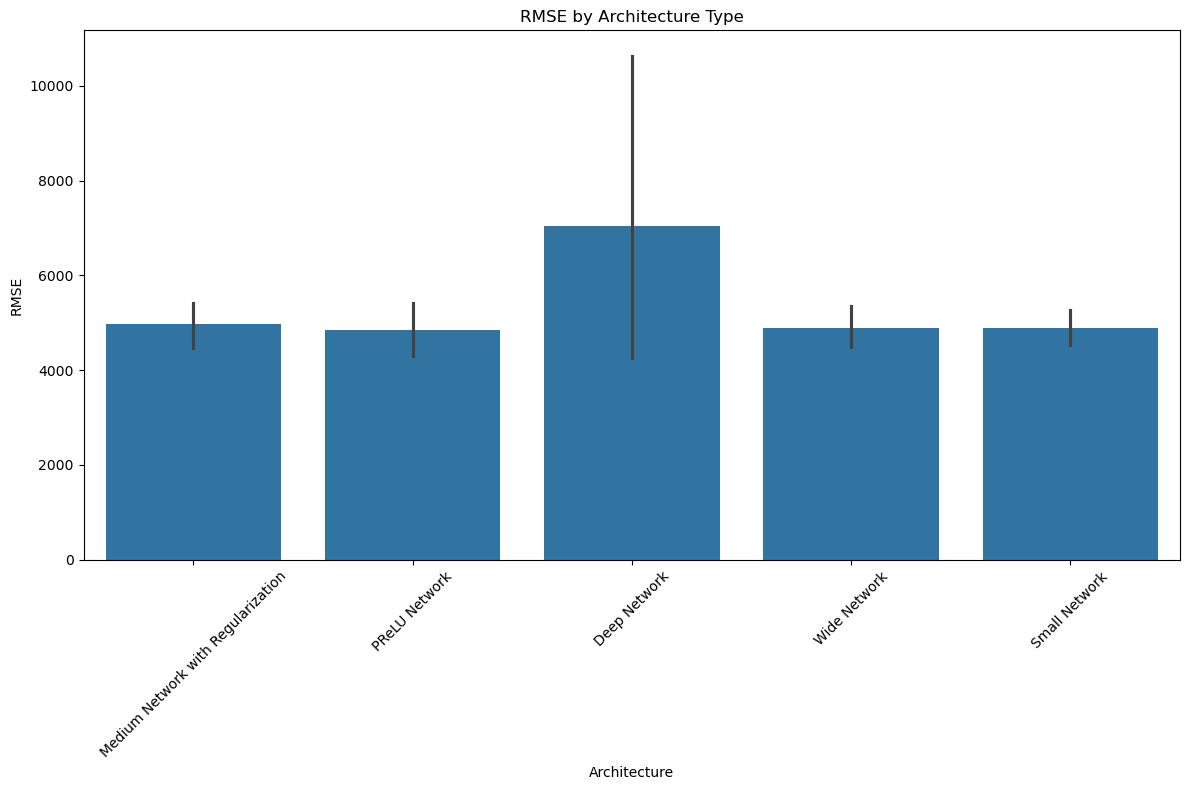

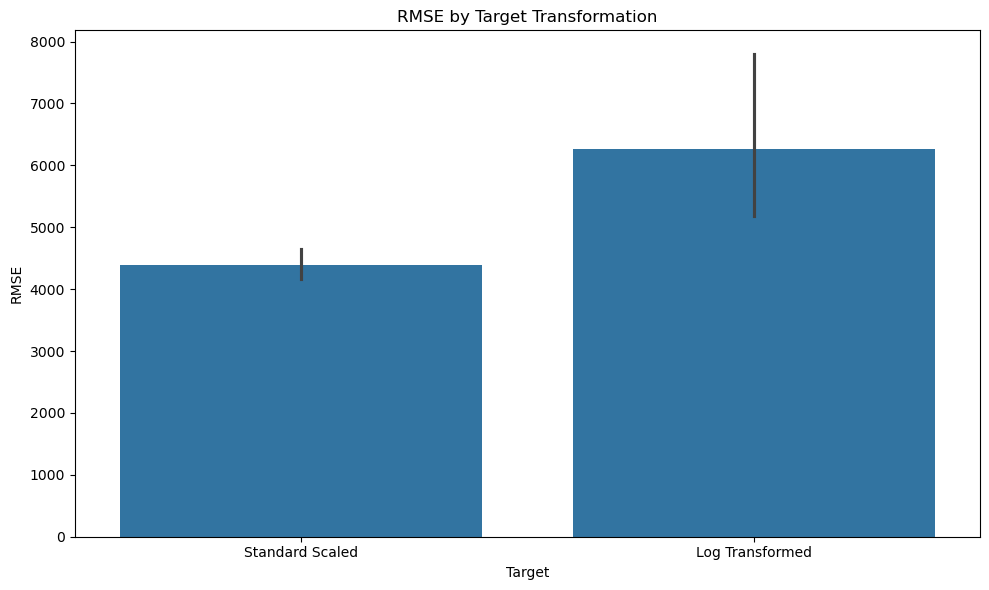

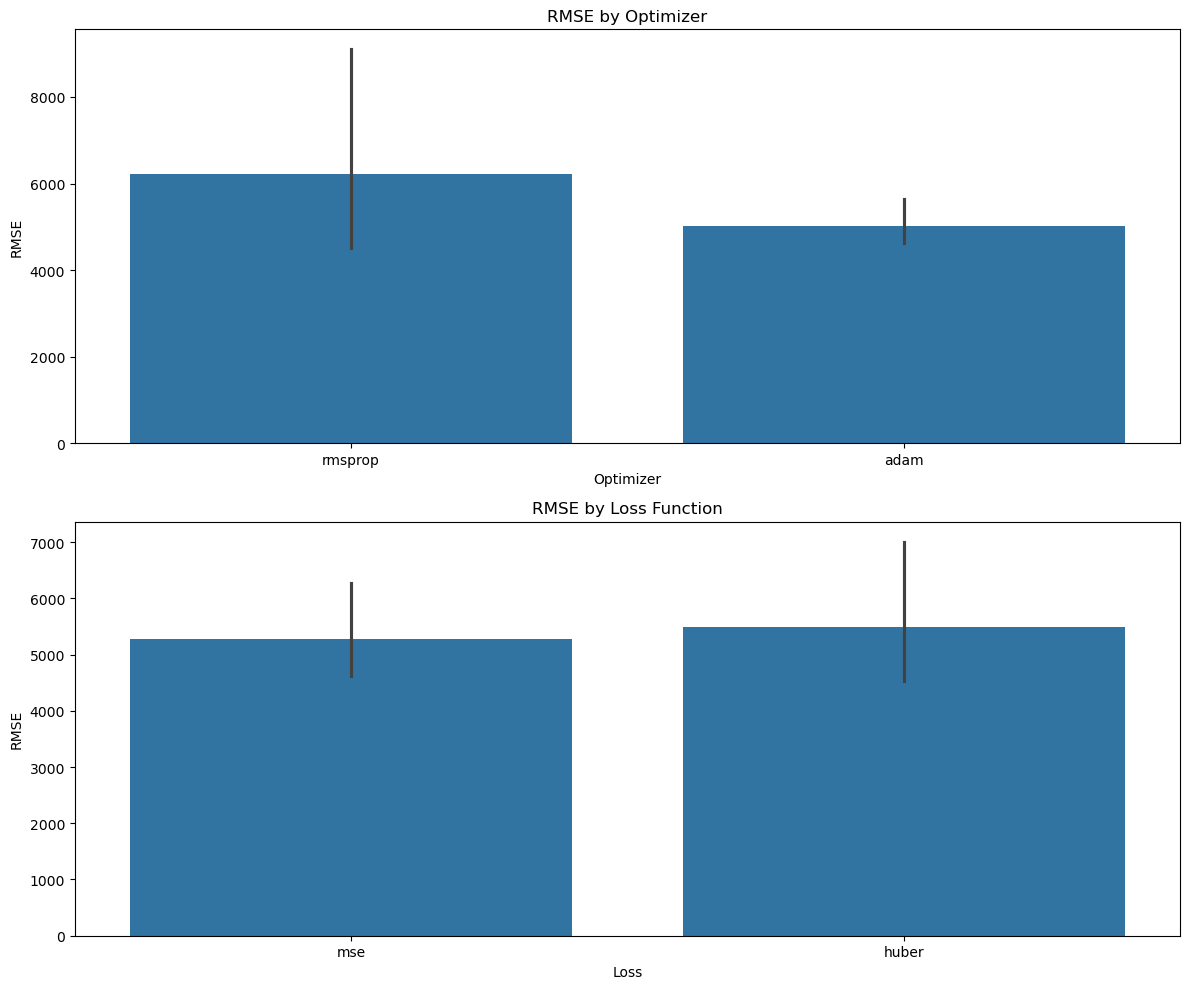

In [8]:
# Create a DataFrame with the results
results_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'], 'Target': r['target_transformation'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in search_results
])

# Sort by RMSE (primary metric)
results_df_sorted = results_df.sort_values('RMSE')
display(results_df_sorted)

# Find best model
best_model_config = search_results[results_df_sorted.index[0]]
print(f"\nBest Model: {best_model_config['name']}")
print(f"RMSE: {best_model_config['rmse']:.2f}")
print(f"MAE: {best_model_config['mae']:.2f}")
print(f"R² Score: {best_model_config['r2']:.4f}")

# Plot comparisons of different architectures
plt.figure(figsize=(12, 8))
sns.barplot(x='Architecture', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Architecture Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot comparisons of target transformations
plt.figure(figsize=(10, 6))
sns.barplot(x='Target', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Target Transformation')
plt.tight_layout()
plt.show()

# Plot comparisons of optimizers and loss functions
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
sns.barplot(x='Optimizer', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Optimizer')

plt.subplot(2, 1, 2)
sns.barplot(x='Loss', y='RMSE', data=results_df_sorted)
plt.title('RMSE by Loss Function')
plt.tight_layout()
plt.show()

## 9. Fine-tuning the Best Model

In [9]:
# Extract information about the best model configuration
best_architecture = next(a for a in architecture_search_space if a['name'] == best_model_config['architecture'])
best_target = next(t for t in target_options if t['name'] == best_model_config['target_transformation'])

# Fine-tune by making small adjustments to the best architecture
fine_tuned_architectures = [
    # Slight variations of the best architecture
    {
        'name': f"Fine-Tuned {best_architecture['name']} v1",
        'layer_sizes': best_architecture['layer_sizes'].copy(),  # Add 20% more neurons
        'dropout_rates': [rate * 0.9 for rate in best_architecture['dropout_rates']],  # Slightly less dropout
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v2",
        'layer_sizes': best_architecture['layer_sizes'] + [16],  # Add one more layer
        'dropout_rates': best_architecture['dropout_rates'] + [0.1],  # Add dropout for the new layer
        'activation': best_architecture['activation'],
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    },
    {
        'name': f"Fine-Tuned {best_architecture['name']} v3",
        'layer_sizes': best_architecture['layer_sizes'],
        'dropout_rates': best_architecture['dropout_rates'],
        'activation': 'prelu' if best_architecture['activation'] != 'prelu' else 'leaky_relu',  # Try different activation
        'use_batch_norm': best_architecture['use_batch_norm'],
        'use_regularization': best_architecture['use_regularization']
    }
]

# Fine-tune training parameters
fine_tuned_params = [
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'] * 0.5,  # Lower learning rate
        'batch_size': best_model_config['batch_size'],
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'] * 2,  # Larger batch size
        'loss': best_model_config['loss']
    },
    {
        'optimizer': best_model_config['optimizer'],
        'learning_rate': best_model_config['learning_rate'],
        'batch_size': best_model_config['batch_size'],
        'loss': 'huber' if best_model_config['loss'] != 'huber' else 'mse'  # Try different loss
    }
]

# Run fine-tuning
fine_tuning_results = []

# Include the original best model for comparison
fine_tuning_results.append(best_model_config)

# Train fine-tuned models
for arch in fine_tuned_architectures:
    for params in fine_tuned_params:
        # Create a unique name for this configuration
        config_name = f"{best_target['name']} + {arch['name']} + {params['optimizer']} (lr={params['learning_rate']}) + {params['loss']}"
        print(f"\n\nFine-Tuning: {config_name}")
        
        # Create model
        model = create_model_architecture(best_target['X_train'].shape[1], arch)
        
        # Train with longer patience for fine-tuning
        trained_model, history, training_time = train_model(
            best_target['X_train'], best_target['y_train'],
            best_target['X_val'], best_target['y_val'],
            model=model,
            batch_size=params['batch_size'],
            optimizer=params['optimizer'],
            learning_rate=params['learning_rate'],
            loss=params['loss'],
            patience=20  # Longer patience for fine-tuning
        )
        
        # Evaluate on test set
        y_pred = trained_model.predict(best_target['X_test'])
        
        # Convert to original scale
        y_pred_original = best_target['inverse_func'](y_pred)
        y_test_original = best_target['inverse_func'](best_target['y_test'])
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        mae = mean_absolute_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)
        
        print(f"Results for fine-tuned model:")
        print(f"RMSE: {rmse:.2f}")
        print(f"MAE: {mae:.2f}")
        print(f"R² Score: {r2:.4f}")
        
        # Store results
        fine_tuning_results.append({
            'name': config_name,
            'architecture': arch['name'],
            'target_transformation': best_target['name'],
            'optimizer': params['optimizer'],
            'learning_rate': params['learning_rate'],
            'loss': params['loss'],
            'batch_size': params['batch_size'],
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'training_time': training_time,
            'model': trained_model,
            'history': history,
            'y_pred': y_pred_original,
            'y_test': y_test_original
        })



Fine-Tuning: Standard Scaled + Fine-Tuned Medium Network with Regularization v1 + rmsprop (lr=0.0005) + mse
Epoch 1/500


/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 2.5785 - root_mean_squared_error: 1.5987
Epoch 1: New best val_loss = 1.794839
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 2.5863 - root_mean_squared_error: 1.6009 - val_loss: 1.7948 - val_root_mean_squared_error: 1.3312 - learning_rate: 5.0000e-04
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.3371 - root_mean_squared_error: 1.5213
Epoch 2: New best val_loss = 1.618934
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3577 - root_mean_squared_error: 1.5263 - val_loss: 1.6189 - val_root_mean_squared_error: 1.2634 - learning_rate: 5.0000e-04
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.9194 - root_mean_squared_error: 1.7020
Epoch 3: New best val_loss = 1.411856
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5291 - root_mean_squared_error: 1.5818 - val_loss: 1.4119 - val_root_mean_squared_error: 1.1786 - learning_rate: 5.0000e-04
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.3446 - root_mean_squared_er

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 1.7323 - root_mean_squared_error: 1.3076
Epoch 1: New best val_loss = 0.504543
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 1.7241 - root_mean_squared_error: 1.3045 - val_loss: 0.5045 - val_root_mean_squared_error: 0.6944 - learning_rate: 0.0010
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7358 - root_mean_squared_error: 0.8446
Epoch 2: New best val_loss = 0.495928
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0775 - root_mean_squared_error: 1.0220 - val_loss: 0.4959 - val_root_mean_squared_error: 0.6882 - learning_rate: 0.0010
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7685 - root_mean_squared_error: 0.8638
Epoch 3: New best val_loss = 0.486750
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8895 - root_mean_squared_error: 0.9304 - val_loss: 0.4868 - val_root_mean_squared_error: 0.6815 - learning_rate: 0.0010
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.7589 - root_mean_squared_error: 0.8577

...

Epoch 1/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - loss: 1.8743 - root_mean_squared_error: 1.3607
Epoch 1: New best val_loss = 0.568326
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 2.0132 - root_mean_squared_error: 1.4105 - val_loss: 0.5683 - val_root_mean_squared_error: 0.7387 - learning_rate: 5.0000e-04
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.7091 - root_mean_squared_error: 1.2986
Epoch 2: New best val_loss = 0.477626
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.6967 - root_mean_squared_error: 1.2936 - val_loss: 0.4776 - val_root_mean_squared_error: 0.6745 - learning_rate: 5.0000e-04
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.7158 - root_mean_squared_error: 1.3012
Epoch 3: New best val_loss = 0.430046
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.4590 - root_mean_squared_error: 1.1975 - val_loss: 0.4300 - val_root_mean_squared_error: 0.6382 - learning_rate: 5.0000e-04
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.3971 - root_mea

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 2.3898 - root_mean_squared_error: 1.5386
Epoch 1: New best val_loss = 0.617600
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 2.0189 - root_mean_squared_error: 1.4110 - val_loss: 0.6176 - val_root_mean_squared_error: 0.7714 - learning_rate: 0.0010
Epoch 2/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.1516 - root_mean_squared_error: 1.0625
Epoch 2: New best val_loss = 0.542029
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0392 - root_mean_squared_error: 1.0078 - val_loss: 0.5420 - val_root_mean_squared_error: 0.7207 - learning_rate: 0.0010
Epoch 3/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.8233 - root_mean_squared_error: 0.8948
Epoch 3: New best val_loss = 0.516743
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9035 - root_mean_squared_error: 0.9382 - val_loss: 0.5167 - val_root_mean_squared_error: 0.7030 - learning_rate: 0.0010
Epoch 4/500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8885 - root_mean_squared_error: 0.9305

/home/lyes/anaconda3/envs/DM_ENV/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 1.0525 - root_mean_squared_error: 1.8088
Epoch 1: New best val_loss = 0.298724
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.7260 - root_mean_squared_error: 1.4313 - val_loss: 0.2987 - val_root_mean_squared_error: 0.7613 - learning_rate: 0.0010
Epoch 2/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7254 - root_mean_squared_error: 1.4313
Epoch 2: New best val_loss = 0.225496
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5636 - root_mean_squared_error: 1.1933 - val_loss: 0.2255 - val_root_mean_squared_error: 0.6493 - learning_rate: 0.0010
Epoch 3/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4757 - root_mean_squared_error: 1.1294
Epoch 3: New best val_loss = 0.172319
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4353 - root_mean_squared_error: 1.0410 - val_loss: 0.1723 - val_root_mean_squared_error: 0.5577 - learning_rate: 0.0010
Epoch 4/500
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4161 - root_mean_squared_error: 0.9855


## 10. Analyze Fine-Tuning Results

In [10]:
# Create a DataFrame with the fine-tuning results
fine_tuning_df = pd.DataFrame([
    {'Config': r['name'], 'Architecture': r['architecture'],
     'Optimizer': r['optimizer'], 'Learning Rate': r['learning_rate'], 'Loss': r['loss'],
     'RMSE': r['rmse'], 'MAE': r['mae'], 'R²': r['r2'], 'Time (s)': r['training_time']}
    for r in fine_tuning_results
])

# Sort by RMSE
fine_tuning_df_sorted = fine_tuning_df.sort_values('RMSE')
display(fine_tuning_df_sorted)

# Find the best fine-tuned model
best_fine_tuned = fine_tuning_results[fine_tuning_df_sorted.index[0]]
print(f"\nBest Fine-Tuned Model: {best_fine_tuned['name']}")
print(f"RMSE: {best_fine_tuned['rmse']:.2f}")
print(f"MAE: {best_fine_tuned['mae']:.2f}")
print(f"R² Score: {best_fine_tuned['r2']:.4f}")

# Show improvement over initial best model
improvement_rmse = ((best_model_config['rmse'] - best_fine_tuned['rmse']) / best_model_config['rmse']) * 100
improvement_r2 = ((best_fine_tuned['r2'] - best_model_config['r2']) / best_model_config['r2']) * 100

print(f"\nImprovement over initial best model:")
print(f"RMSE improvement: {improvement_rmse:.2f}%")
print(f"R² improvement: {improvement_r2:.2f}%")

,Config,Architecture,Optimizer,Learning Rate,Loss,RMSE,MAE,R²,Time (s)
9,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0010,huber,3521.162139,1998.541567,0.848736,5.747686
0,Standard Scaled + Medium Network with Regulari...,Medium Network with Regularization,rmsprop,0.0010,mse,3835.118379,2195.063664,0.820559,5.030049
5,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0010,mse,4145.888432,2273.981458,0.790300,6.942301
4,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0005,mse,4372.132151,2682.513534,0.766789,7.378245
2,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0010,mse,4374.473238,2309.462465,0.766539,7.856984
6,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v2,rmsprop,0.0010,huber,4452.407573,2233.551470,0.758146,7.590398
8,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0010,mse,4474.419057,2289.466834,0.755749,9.822985
1,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0005,mse,4482.688151,2527.873648,0.754845,10.135736
3,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v1,rmsprop,0.0010,huber,4740.358207,2733.127842,0.725852,7.398619
7,Standard Scaled + Fine-Tuned Medium Network wi...,Fine-Tuned Medium Network with Regularization v3,rmsprop,0.0005,mse,4799.036371,3041.670848,0.719023,5.437512



Best Fine-Tuned Model: Standard Scaled + Fine-Tuned Medium Network with Regularization v3 + rmsprop (lr=0.001) + huber
RMSE: 3521.16
MAE: 1998.54
R² Score: 0.8487

Improvement over initial best model:
RMSE improvement: 8.19%
R² improvement: 3.43%


## 11. Final Model Analysis and Visualization

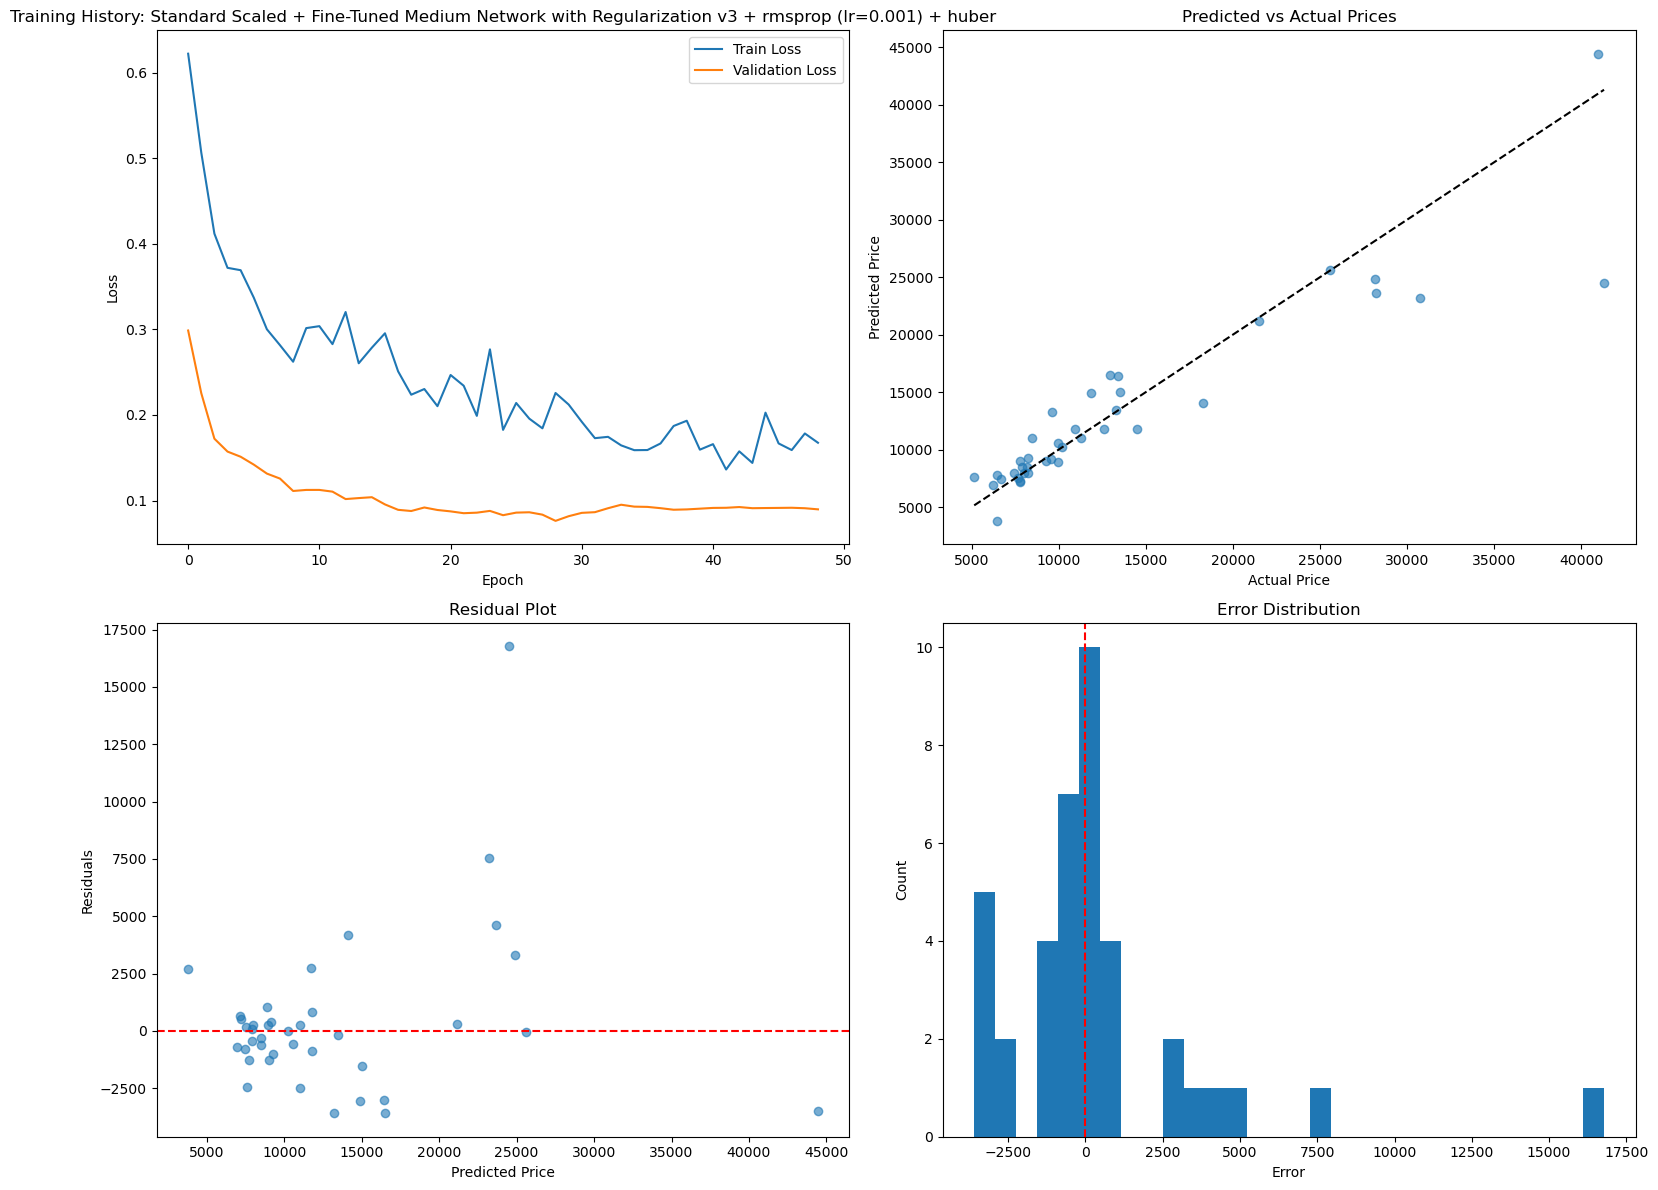

In [11]:
# Select the final best model - either from initial search or fine-tuning
final_model = best_fine_tuned if best_fine_tuned['rmse'] < best_model_config['rmse'] else best_model_config

# Visualize the final model's performance
plt.figure(figsize=(16, 12))

# Plot training & validation loss
plt.subplot(2, 2, 1)
plt.plot(final_model['history'].history['loss'], label='Train Loss')
plt.plot(final_model['history'].history['val_loss'], label='Validation Loss')
plt.title(f'Training History: {final_model["name"]}')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot predictions vs actual
plt.subplot(2, 2, 2)
plt.scatter(final_model['y_test'], final_model['y_pred'], alpha=0.6)
plt.plot([min(final_model['y_test']), max(final_model['y_test'])], 
         [min(final_model['y_test']), max(final_model['y_test'])], 'k--')
plt.title('Predicted vs Actual Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot residuals
residuals = final_model['y_test'] - final_model['y_pred']
plt.subplot(2, 2, 3)
plt.scatter(final_model['y_pred'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')

# Plot error distribution
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Error Distribution')
plt.xlabel('Error')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 12. Error Analysis

Worst Predictions (Highest Errors):


,Actual,Predicted,Error,Abs_Error,Squared_Error,Rel_Error_Pct
24,41315.0,24537.531250,16777.468750,16777.468750,2.814835e+08,40.608662
0,30760.0,23221.337891,7538.662109,7538.662109,5.683143e+07,24.508004
3,28248.0,23640.912109,4607.087891,4607.087891,2.122526e+07,16.309430
11,18280.0,14099.232422,4180.767578,4180.767578,1.747882e+07,22.870720
25,9639.0,13237.600586,-3598.600586,3598.600586,1.294993e+07,37.333754
28,12940.0,16510.710938,-3570.710938,3570.710938,1.274998e+07,27.594366
13,40960.0,44452.117188,-3492.117188,3492.117188,1.219488e+07,8.525677
34,28176.0,24876.970703,3299.029297,3299.029297,1.088359e+07,11.708650
2,11850.0,14916.626953,-3066.626953,3066.626953,9.404201e+06,25.878708
26,13415.0,16418.574219,-3003.574219,3003.574219,9.021458e+06,22.389670



Error Distribution Statistics:
Mean Absolute Error: 1998.54
Median Absolute Error: 877.63
Mean Relative Error: 13.85%
Median Relative Error: 10.53%
90th Percentile Error: 3715.03
95th Percentile Error: 4900.25


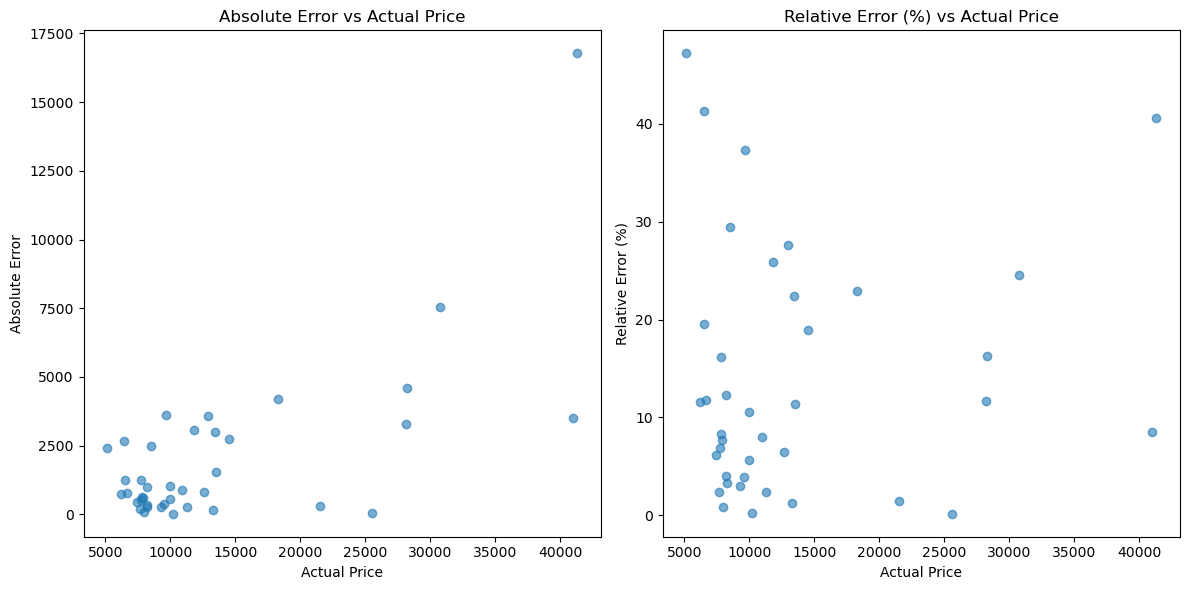

In [12]:
# Create error analysis dataframe
error_df = pd.DataFrame({
    'Actual': final_model['y_test'].flatten(),
    'Predicted': final_model['y_pred'].flatten(),
    'Error': residuals.flatten(),
    'Abs_Error': np.abs(residuals.flatten()),
    'Squared_Error': residuals.flatten() ** 2,
    'Rel_Error_Pct': (np.abs(residuals.flatten()) / final_model['y_test'].flatten()) * 100
})

# Find the worst predictions
print("Worst Predictions (Highest Errors):")
display(error_df.sort_values('Squared_Error', ascending=False).head(10))

# Error statistics
print("\nError Distribution Statistics:")
print(f"Mean Absolute Error: {error_df['Abs_Error'].mean():.2f}")
print(f"Median Absolute Error: {error_df['Abs_Error'].median():.2f}")
print(f"Mean Relative Error: {error_df['Rel_Error_Pct'].mean():.2f}%")
print(f"Median Relative Error: {error_df['Rel_Error_Pct'].median():.2f}%")
print(f"90th Percentile Error: {np.percentile(error_df['Abs_Error'], 90):.2f}")
print(f"95th Percentile Error: {np.percentile(error_df['Abs_Error'], 95):.2f}")

# Check if errors are correlated with price
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(error_df['Actual'], error_df['Abs_Error'], alpha=0.6)
plt.title('Absolute Error vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Absolute Error')

plt.subplot(1, 2, 2)
plt.scatter(error_df['Actual'], error_df['Rel_Error_Pct'], alpha=0.6)
plt.title('Relative Error (%) vs Actual Price')
plt.xlabel('Actual Price')
plt.ylabel('Relative Error (%)')
plt.tight_layout()
plt.show()

# Decision Tree


- Train the model


In [41]:
from sklearn.tree import DecisionTreeRegressor , plot_tree

In [42]:
DecisionTreeModel=DecisionTreeRegressor()
DecisionTreeModel.fit(X_train, y_train)

DecisionTreeRegressor()

plot the decision tree


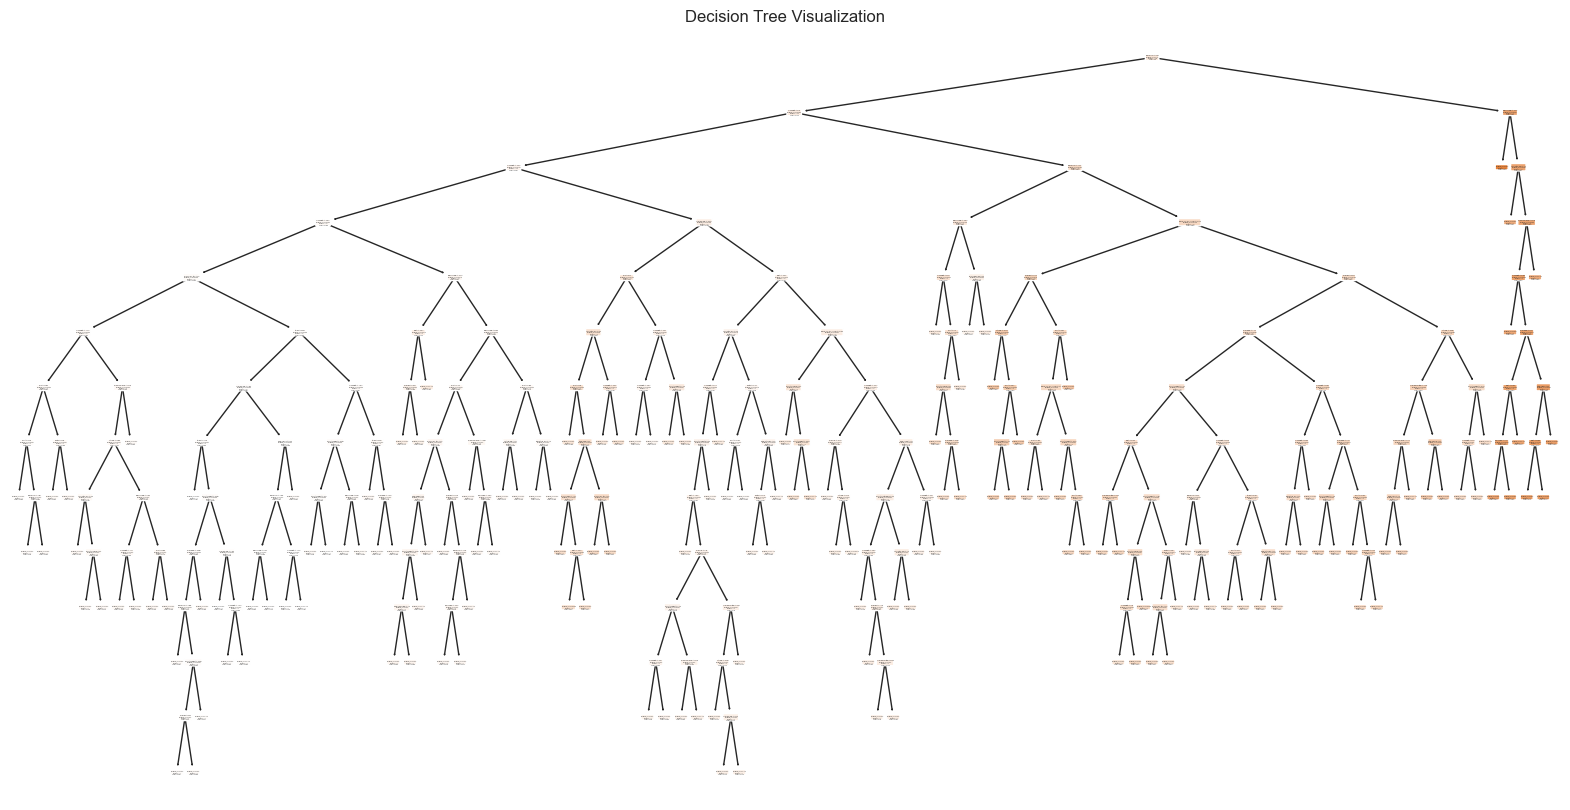

In [44]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(DecisionTreeModel, feature_names=list(X_train.columns), filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [45]:
y_predicted_dt=DecisionTreeModel.predict(X_test)

In [46]:
regression_report(y_predicted_dt,y_test)

NameError: name 'root_mean_squared_error' is not defined

In [47]:
dt_predict1_not_scaled = scaler_y.inverse_transform(y_predicted_dt.reshape(-1, 1)).flatten()

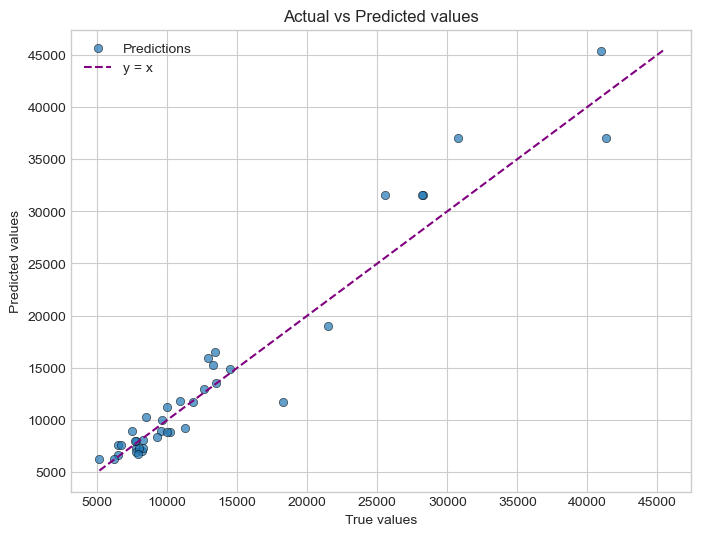

In [48]:
plot_actual_predicted(y_test_original_scale,dt_predict1_not_scaled)

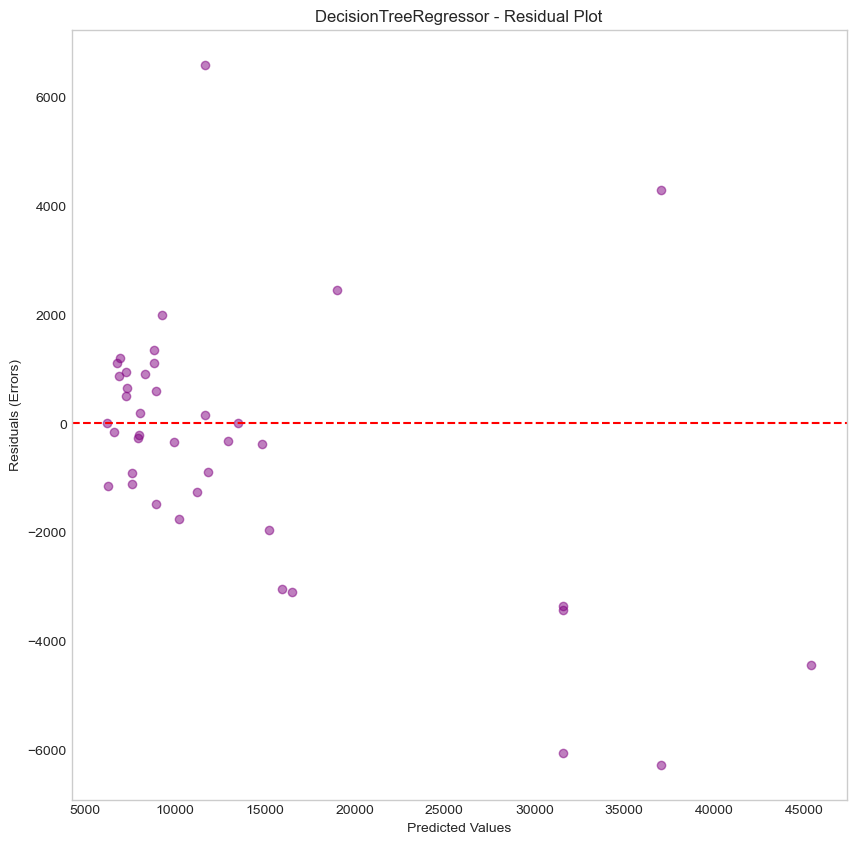

In [49]:
plot_residuals(y_test_original_scale,dt_predict1_not_scaled,"DecisionTreeRegressor")

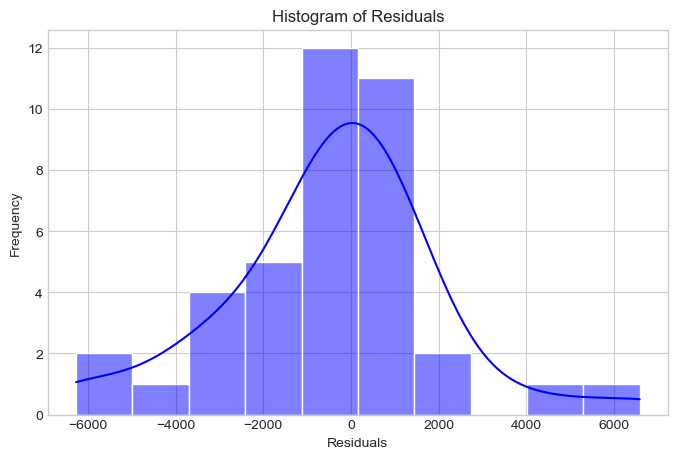

In [50]:

histogram_residuals(y_test_original_scale,dt_predict1_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     63.7476      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     27.5734      │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      1.65245     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      1.19342     │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │      1.14471     │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │      0.900149    │
├──────────────────────────┼──────────────────┤
│ bore                     │      0.673574    │
├──────────────────────────┼──────────────────┤
│ height                   │      0.532822    │
├──────────────────────────┼──────────────────┤
│ horsepower               │      0.467061    │
├──────────────────────────┼────────────

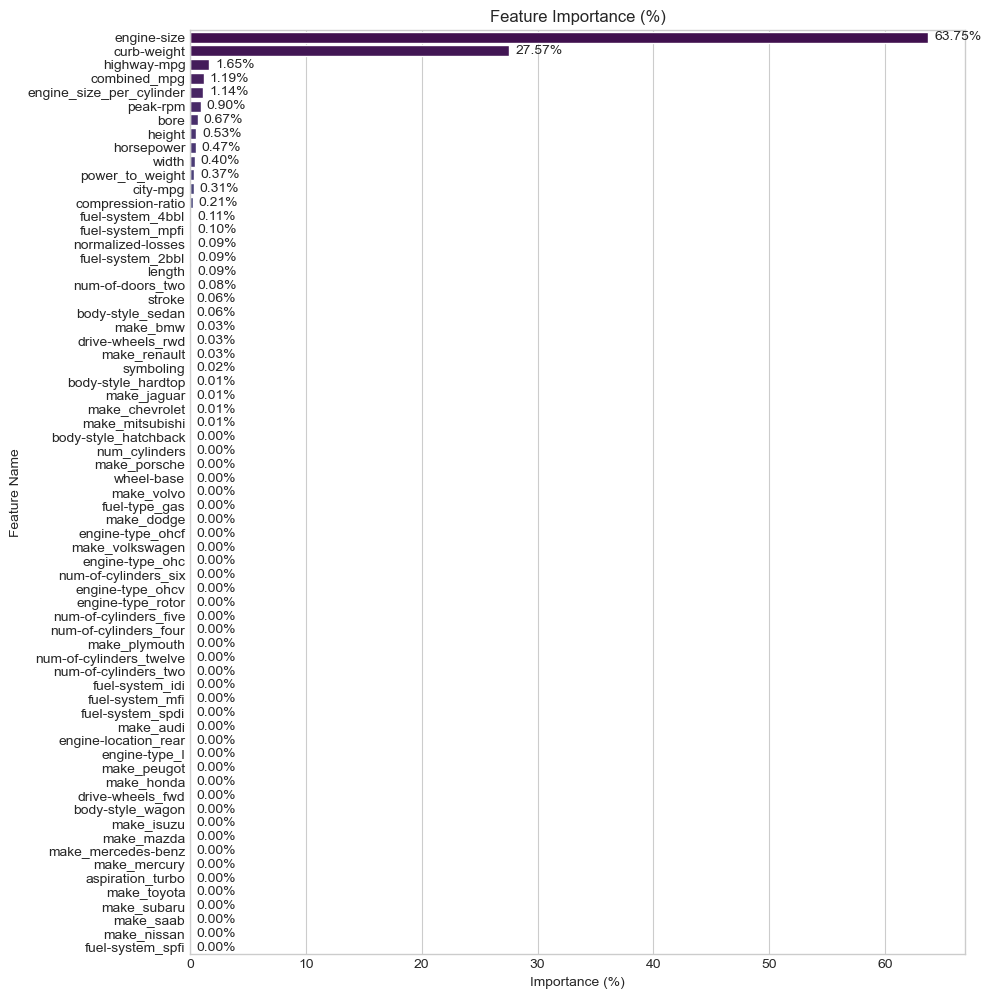

In [51]:
important_feature=plot_feature_importance(DecisionTreeModel,X_train.columns)

In [52]:
print(important_feature)
print(len(important_feature))

['engine-size', 'curb-weight', 'highway-mpg', 'combined_mpg', 'engine_size_per_cylinder', 'peak-rpm', 'bore', 'height', 'horsepower', 'width', 'power_to_weight', 'city-mpg', 'compression-ratio', 'fuel-system_4bbl', 'fuel-system_mpfi', 'normalized-losses', 'fuel-system_2bbl', 'length', 'num-of-doors_two', 'stroke', 'body-style_sedan', 'make_bmw', 'drive-wheels_rwd', 'make_renault', 'symboling', 'body-style_hardtop', 'make_jaguar', 'make_chevrolet', 'make_mitsubishi', 'body-style_hatchback', 'num_cylinders', 'make_porsche', 'wheel-base', 'make_volvo', 'fuel-type_gas', 'make_dodge', 'engine-type_ohcf', 'make_volkswagen', 'engine-type_ohc']
39


- cross validation of untuned decision tree


In [61]:
from sklearn.model_selection import cross_val_score
dt = DecisionTreeRegressor(random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=10, scoring="neg_mean_squared_error")  #10-fold CV
mse_scores = -cv_scores  
rmse_scores = np.sqrt(mse_scores)  
std_mse = np.std(mse_scores)
print("Cross-Validation MSE Scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.mean(rmse_scores))


Cross-Validation MSE Scores: [0.0761997  0.15111093 0.04207536 0.10764887 0.45755938 0.22786001
 0.16298591 0.11893213 0.17640186 0.23471804]
Mean MSE: 0.17554921966771428
MSE Standard Deviation: 0.11046467459176663
Mean RMSE: 0.40048325087207653


The Decision Tree model has a Mean MSE of 0.1755 and RMSE of 0.4005 indicating a reasonable but not optimal error rate

- High Variance Across Folds  indicates that the model is not very stable and may not generalize well to unseen data ( the model may be overfitting to some training subsets)  
  Need for improvement we may see hyparameter tuning or random forest (it can help reduce the variance and improve the model's stability)


- hyparameter tuning (Grid Search)


In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#  Select only important features
X_train_selected = X_train[important_feature]  
X_test_selected = X_test[important_feature]    

dt = DecisionTreeRegressor(random_state=42)

# define hyperparameter grid
param_grid = {
    "max_depth": np.arange(1, 15),  # 1 to 14 
    "min_samples_split": np.arange(2, 17, 2),  # even numbers from 2 to 16 (~10% OF total samples)
    "min_samples_leaf": np.arange(1, 9, 2)  # odd numbers from 1 to 7 (~5% of total samples)
}

# prform Grid Search with Cross Validation
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train_selected, y_train)  

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Model:", best_model)


Best Parameters: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best Model: DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)


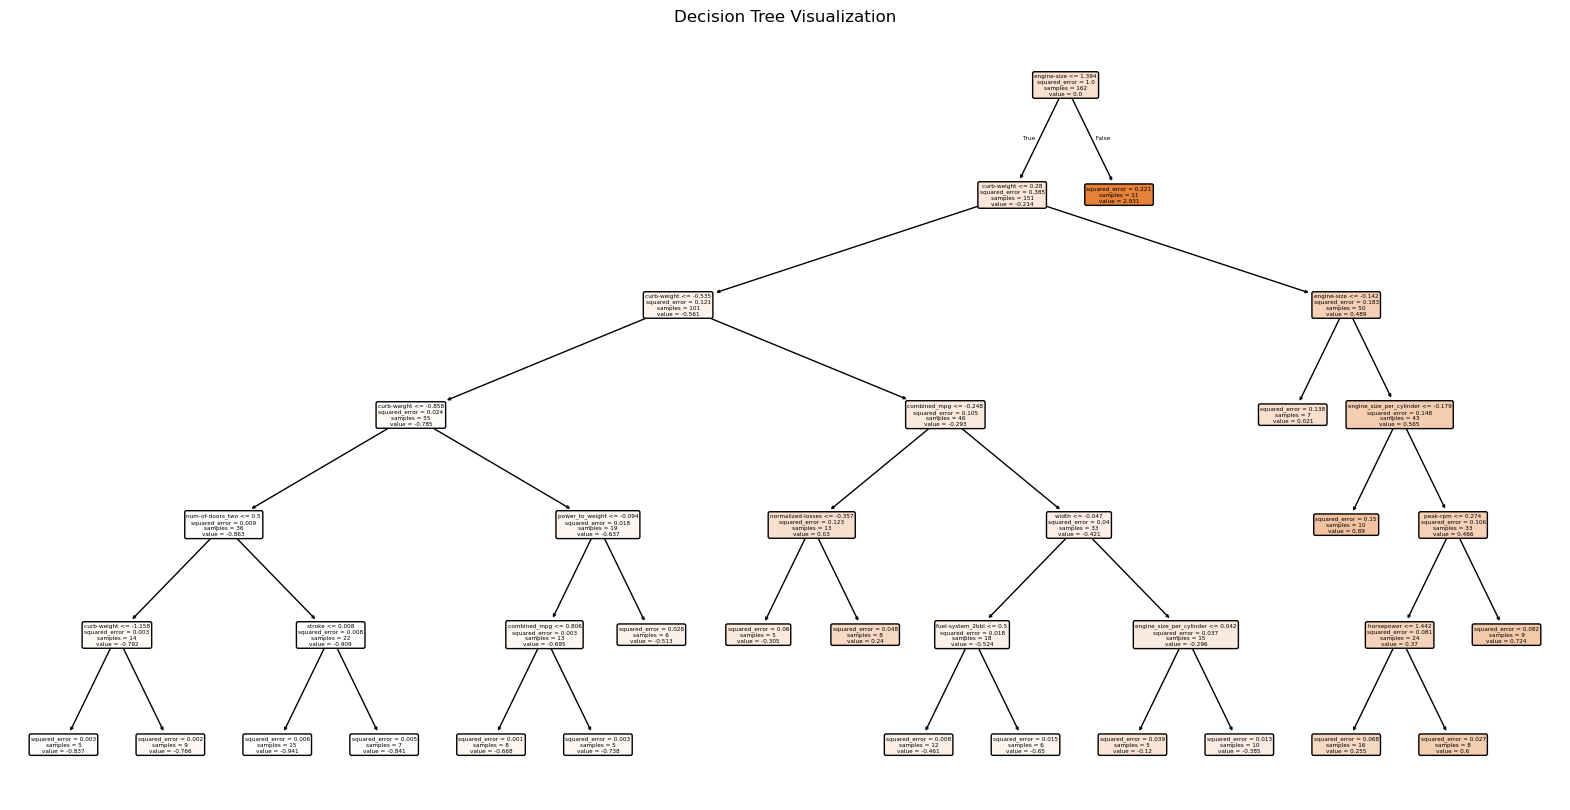

In [78]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(best_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [58]:
best_model=DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)
best_model.fit(X_train_selected, y_train)  

DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)

In [59]:
y_predicted_dt_hyp=best_model.predict(X_test[important_feature])

In [ ]:

regression_report(y_test,y_predicted_dt_hyp)


Model: DecisionTreeRegressor with hyparameter tuning {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12} and important features
MAE: 0.28118293271300254
MSE: 0.17569078308465155
R² Score: 0.8752242991470398
Root Mean Squared Error (RMSE): 0.419154843804353


In [60]:
y_predicted_dt_hyp_not_scaled = scaler_y.inverse_transform(y_predicted_dt_hyp.reshape(-1, 1)).flatten()

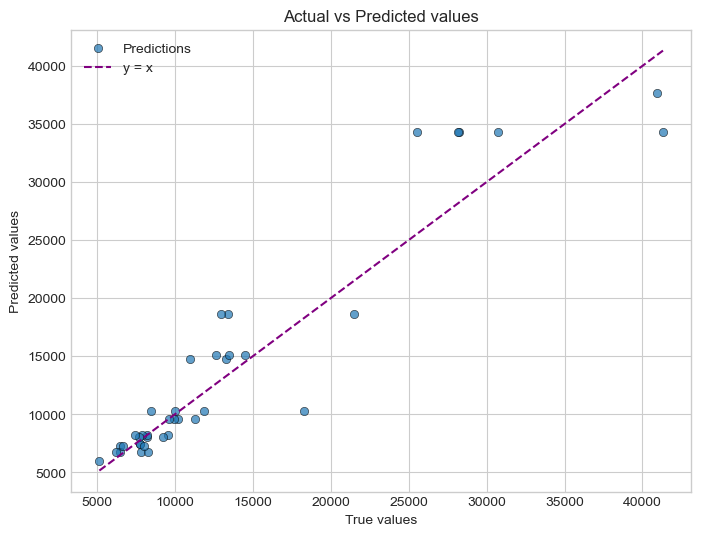

In [61]:
plot_actual_predicted(y_test_original_scale,y_predicted_dt_hyp_not_scaled)

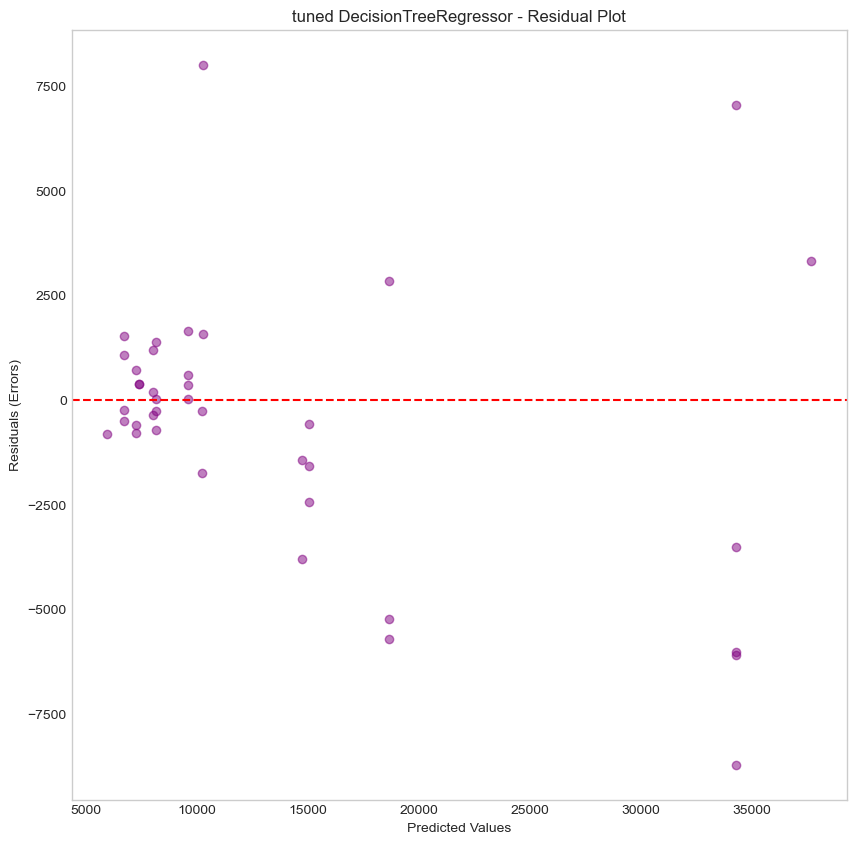

In [62]:
plot_residuals(y_test_original_scale,y_predicted_dt_hyp_not_scaled,"tuned DecisionTreeRegressor")

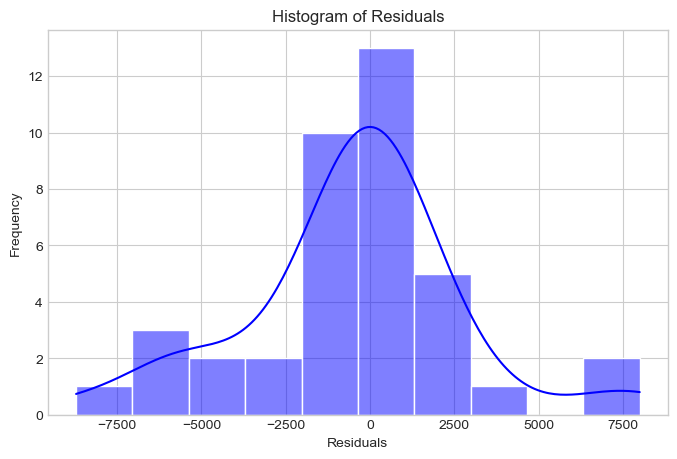

In [63]:

histogram_residuals(y_test_original_scale,y_predicted_dt_hyp_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │       67.2026    │
├──────────────────────────┼──────────────────┤
│ curb-weight              │       28.3905    │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │        1.24529   │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │        1.05205   │
├──────────────────────────┼──────────────────┤
│ normalized-losses        │        0.594678  │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │        0.535058  │
├──────────────────────────┼──────────────────┤
│ horsepower               │        0.414578  │
├──────────────────────────┼──────────────────┤
│ width                    │        0.27655   │
├──────────────────────────┼──────────────────┤
│ fuel-system_2bbl         │        0.0929132 │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


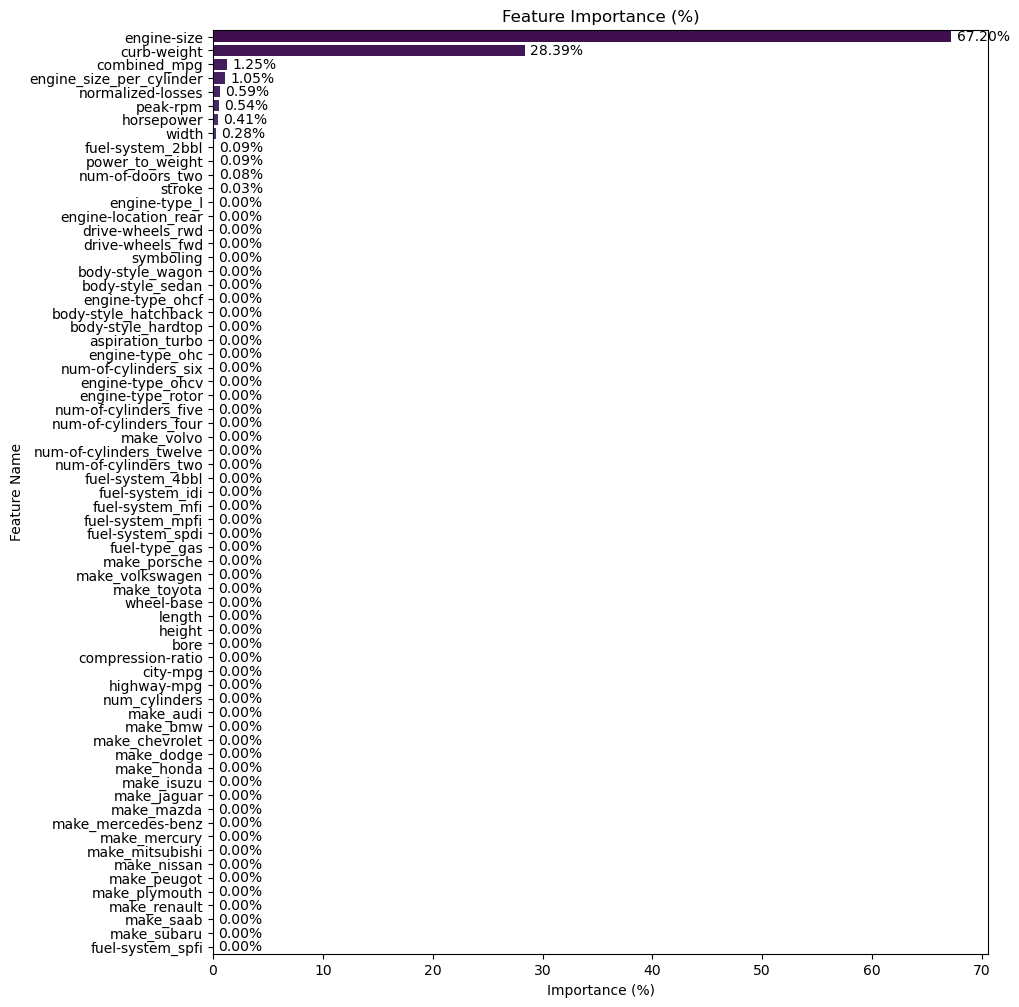

In [84]:
important_feature_tuned=plot_feature_importance(best_model,X_train.columns)

In [90]:
print(important_feature_tuned)
print(len(important_feature_tuned))

['engine-size', 'curb-weight', 'combined_mpg', 'engine_size_per_cylinder', 'normalized-losses', 'peak-rpm', 'horsepower', 'width', 'fuel-system_2bbl', 'power_to_weight', 'num-of-doors_two', 'stroke']
12


- cross validation for the tuned model


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-Fold Cross-Validation on the best model
cv_mse_scores = -cross_val_score(best_model, X_train_selected, y_train, cv=10, scoring="neg_mean_squared_error")

# Compute the mean and standard deviation of MSE
mean_mse = np.mean(cv_mse_scores)
std_mse = np.std(cv_mse_scores)
print("Cross-Validation MSE Scores:", cv_mse_scores)
print("Mean MSE:", mean_mse)
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.sqrt(mean_mse))



Cross-Validation MSE Scores: [0.10999258 0.05461189 0.06450426 0.08398421 0.32782119 0.1998309
 0.0808003  0.14246641 0.09733924 0.23159116]
Mean MSE: 0.1392942121792864
MSE Standard Deviation: 0.08342665922047936
Mean RMSE: 0.3732213983405646


Conclusion:  
The first model, without tuning, performs better in terms of accuracy,but it exhibits overfitting, as indicated by its higher variance across cross-validation folds  
On the other hand, the tuned DecisionTreeRegressor with feature selection is more stable and generalizes better, even though its accuracy is slightly lower  
Since stability is crucial for real-world applications, the tuned model is preferred  
Further improvements could be made by using ensemble methods to find a balance between accuracy and stability


# Random Forest


- train the model


In [64]:
RandomForestModel=RandomForestRegressor()
RandomForestModel.fit(X_train,y_train)

RandomForestRegressor()

visualize some trees from the random forest model


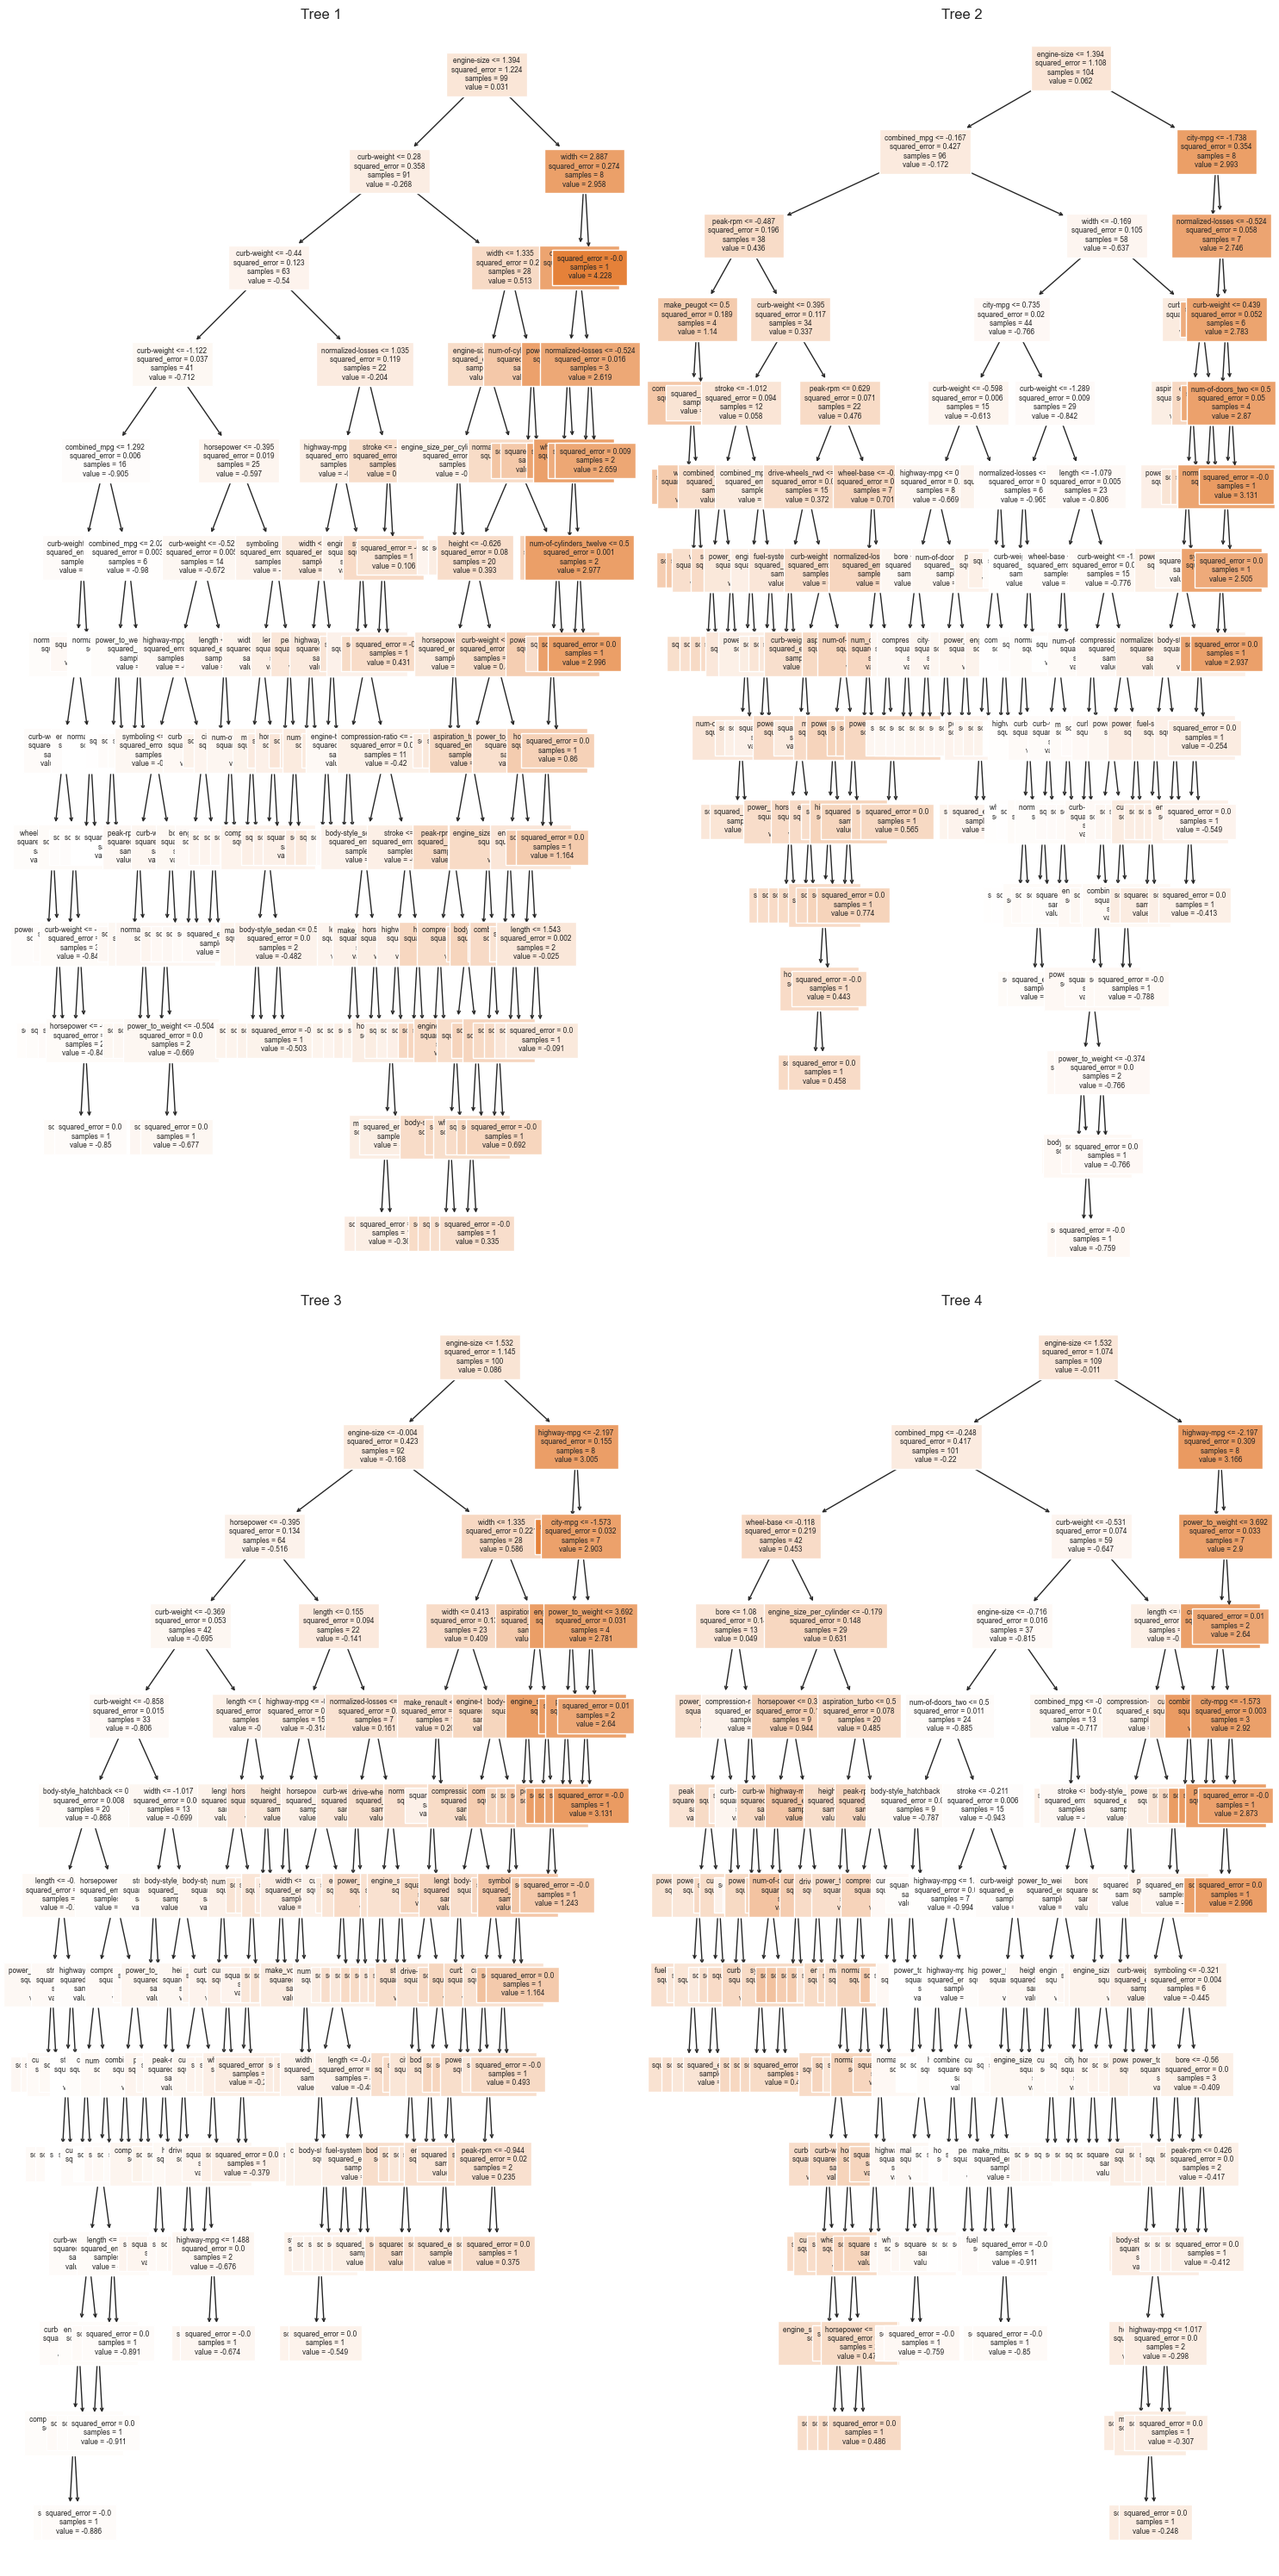

In [65]:
n_trees=4
fig,axes=plt.subplots(2, 2, figsize=(15, 30))
for i , ax in enumerate(axes.flat):
    plot_tree(RandomForestModel.estimators_[i],filled=True, feature_names=list(X_train.columns), ax=ax, fontsize=6)
    ax.set_title(f"Tree {i+1}")
plt.tight_layout()
plt.show()

In [67]:
max_depth = max(tree.get_depth() for tree in RandomForestModel.estimators_)
print("Maximum Tree Depth:", max_depth)


Maximum Tree Depth: 17


- prediction


In [68]:
y_predicted_rf=RandomForestModel.predict(X_test)

- Evaluation of the model


In [ ]:
regression_report(y_test,y_predicted_rf )

Model: RandomForestRegressor
MAE: 0.1737888786571339
MSE: 0.05940423316524063
R² Score: 0.9578110775267351
Root Mean Squared Error (RMSE): 0.24372983642804305


In [69]:
y_predicted_rf_not_scaled = scaler_y.inverse_transform(y_predicted_rf.reshape(-1, 1)).flatten()

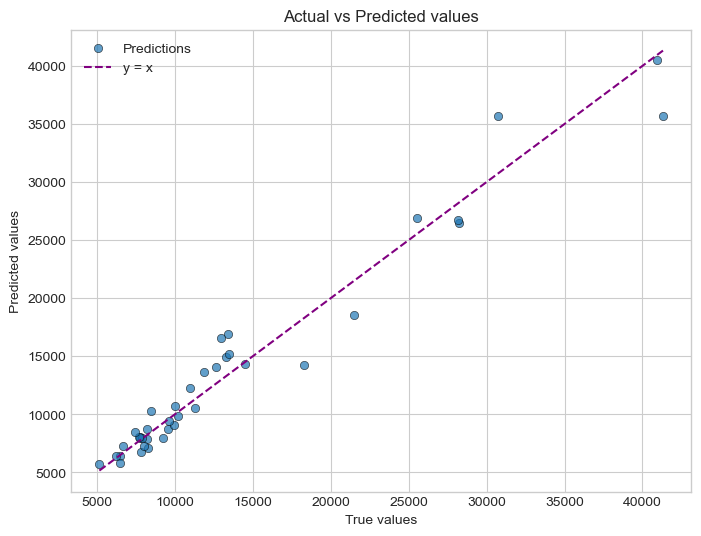

In [70]:
plot_actual_predicted(y_test_original_scale,y_predicted_rf_not_scaled)

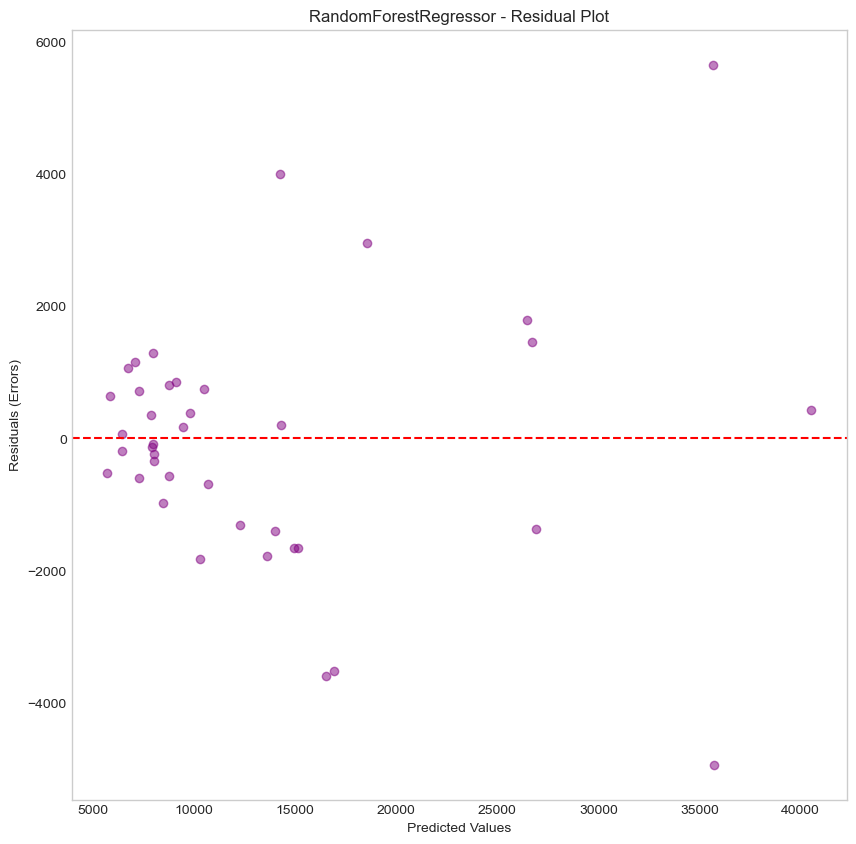

In [71]:
plot_residuals(y_test_original_scale,y_predicted_rf_not_scaled,"RandomForestRegressor")

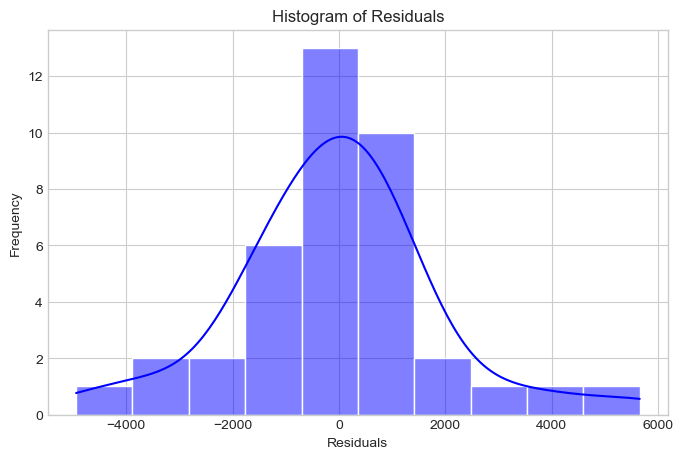

In [72]:

histogram_residuals(y_test_original_scale,y_predicted_rf_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     56.0418      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     27.2973      │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      3.46986     │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      3.25741     │
├──────────────────────────┼──────────────────┤
│ horsepower               │      1.44077     │
├──────────────────────────┼──────────────────┤
│ width                    │      1.43118     │
├──────────────────────────┼──────────────────┤
│ wheel-base               │      0.784581    │
├──────────────────────────┼──────────────────┤
│ make_bmw                 │      0.618112    │
├──────────────────────────┼──────────────────┤
│ power_to_weight          │      0.595736    │
├──────────────────────────┼────────────

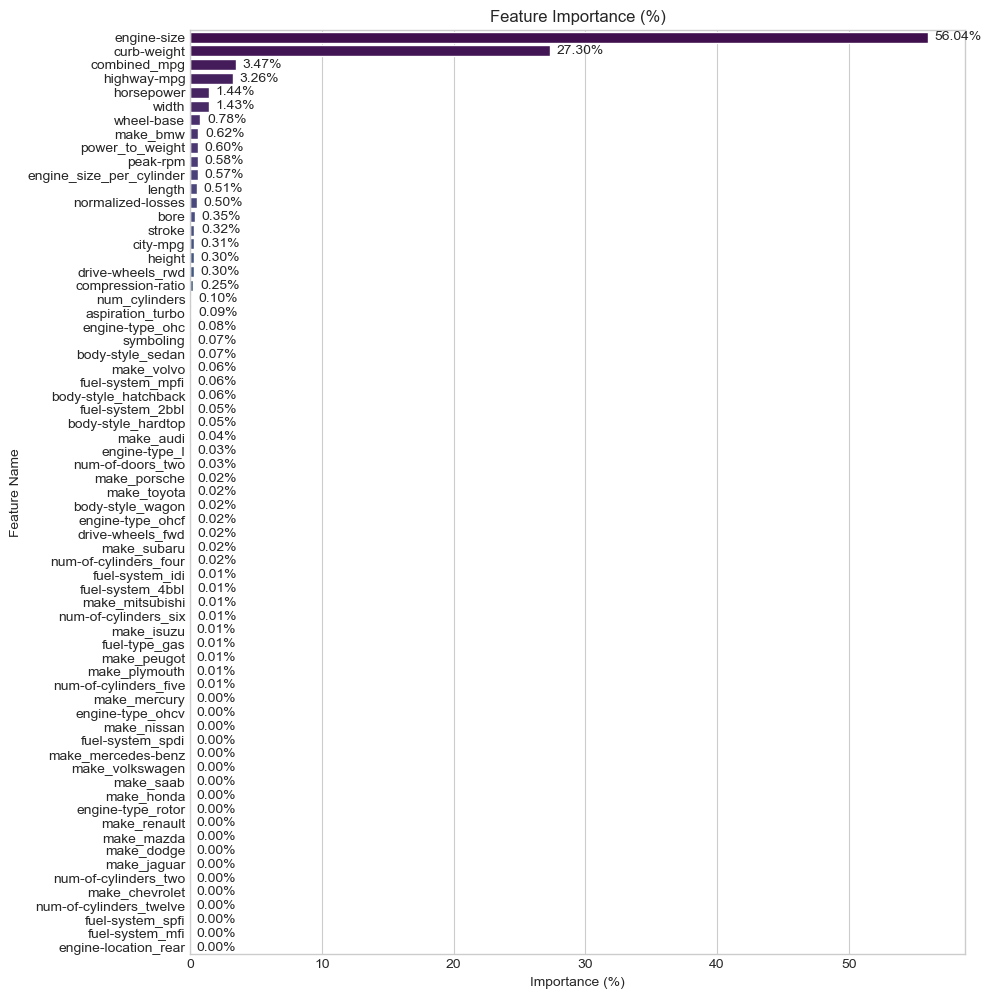

In [73]:
important_feature_rf=plot_feature_importance(RandomForestModel,X_train.columns)

In [91]:
for i in range(0, len(important_feature_rf), 5):  # Adjust chunk size
    print(", ".join(important_feature_rf[i:i+5]))


engine-size, curb-weight, highway-mpg, combined_mpg, width
horsepower, wheel-base, engine_size_per_cylinder, length, num_cylinders
make_bmw, power_to_weight, peak-rpm, normalized-losses, bore
city-mpg, height, compression-ratio, stroke, engine-type_ohc
body-style_sedan, drive-wheels_rwd, fuel-system_mpfi, aspiration_turbo, make_audi
symboling, make_volvo, fuel-system_2bbl, drive-wheels_fwd, num-of-doors_two
body-style_hardtop, body-style_hatchback, fuel-system_idi, engine-type_ohcf, make_toyota
body-style_wagon, num-of-cylinders_six, make_plymouth, num-of-cylinders_four, make_mazda
num-of-cylinders_two, fuel-type_gas, make_mercedes-benz, make_volkswagen, fuel-system_4bbl
make_mitsubishi, make_saab, fuel-system_spdi, make_nissan, engine-type_ohcv
engine-type_rotor, make_porsche, make_renault, make_subaru, num-of-cylinders_five
make_jaguar, engine-type_l, make_mercury, make_isuzu, engine-location_rear
make_honda, num-of-cylinders_twelve, make_dodge, make_peugot, fuel-system_spfi
make_che

In [74]:

print(len(important_feature_rf))


67


- cross validation


In [75]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation with 5 folds
cv_mse = -cross_val_score(RandomForestModel, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

# Print cross-validation results
print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.06201583 0.0946287  0.03426113 0.03320019 0.27731834 0.14093062
 0.05884576 0.07218977 0.05259059 0.24945469]
MSE standard deviation  0.08357927677444014
Mean MSE: 0.10754356123995137
Mean RMSE: 0.327938349754876


we can see that the accuracy of random forest regressor is better than untuned and tuned decision tree and more stable than both


- hyparameter tuning


In [94]:
param_grid = {
    'n_estimators': [10, 50, 100],  
    'max_depth': list(range(1, 18)),  
    'min_samples_split': [2, 4, 8],  
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2']  
}
"""
max_features="sqrt" (default for Random Forest regression) : uses √(total features) per split reducing correlation between trees and improving generalization.
max_features="log2" : uses log2(total features) per split  increasing randomness and preventing overfitting
"""

rf=RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid,cv=10,scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Parameters:", best_rf_params)
print("Best Model:", best_rf_model)

Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Model: RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)


c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [76]:
best_rf_model = RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)
best_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)

In [77]:
y_pred_rf_tuned=best_rf_model.predict(X_test)

- evaluate the tuned random forest


In [ ]:
regression_report(y_test,y_pred_rf_tuned)

Model:  Tuned RandomForestRegressor 
MAE: 0.2033071855492788
MSE: 0.11294485956983714
R² Score: 0.919786492136156
Root Mean Squared Error (RMSE): 0.33607269982823235


In [78]:
y_pred_rf_tuned_not_scaled = scaler_y.inverse_transform(y_pred_rf_tuned.reshape(-1, 1)).flatten()

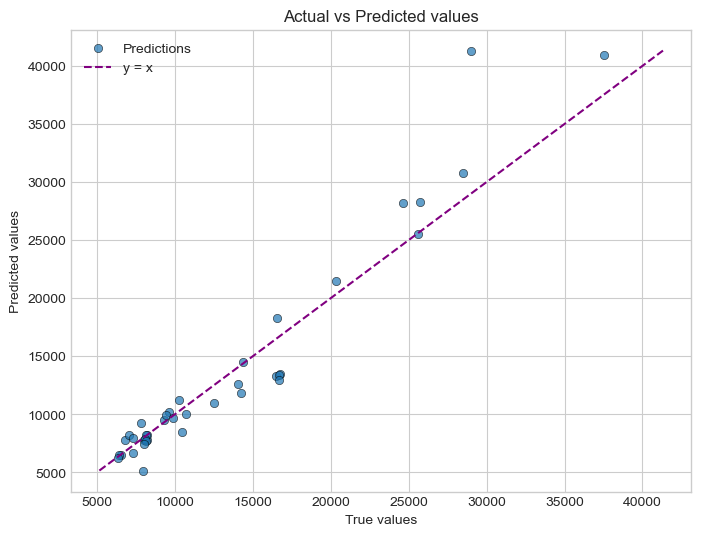

In [79]:
plot_actual_predicted(y_pred_rf_tuned_not_scaled,y_test_original_scale)

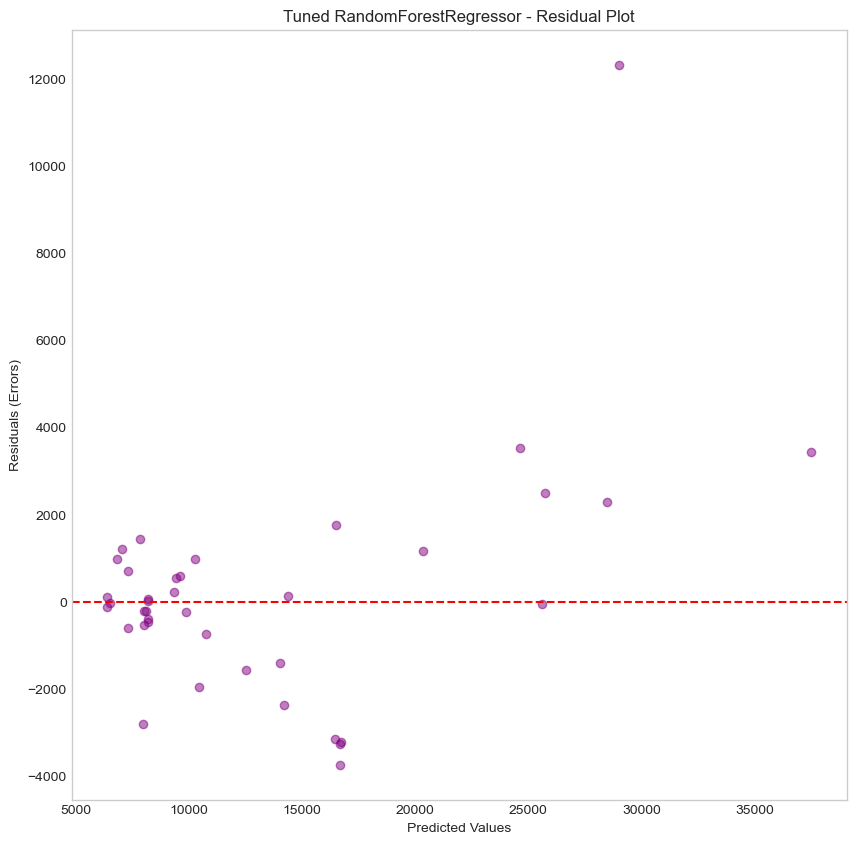

In [80]:
plot_residuals(y_test_original_scale,y_pred_rf_tuned_not_scaled,"Tuned RandomForestRegressor")

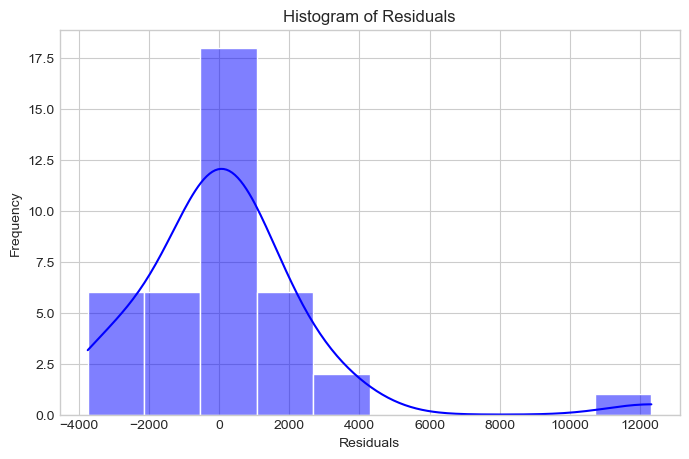

In [81]:

histogram_residuals(y_test_original_scale,y_pred_rf_tuned_not_scaled)

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     11.6368      │
├──────────────────────────┼──────────────────┤
│ horsepower               │      9.15449     │
├──────────────────────────┼──────────────────┤
│ city-mpg                 │      8.85416     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      8.08315     │
├──────────────────────────┼──────────────────┤
│ num-of-cylinders_four    │      7.82997     │
├──────────────────────────┼──────────────────┤
│ curb-weight              │      6.68519     │
├──────────────────────────┼──────────────────┤
│ num_cylinders            │      6.07726     │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      6.0699      │
├──────────────────────────┼──────────────────┤
│ wheel-base               │      5.08397     │
├──────────────────────────┼────────────

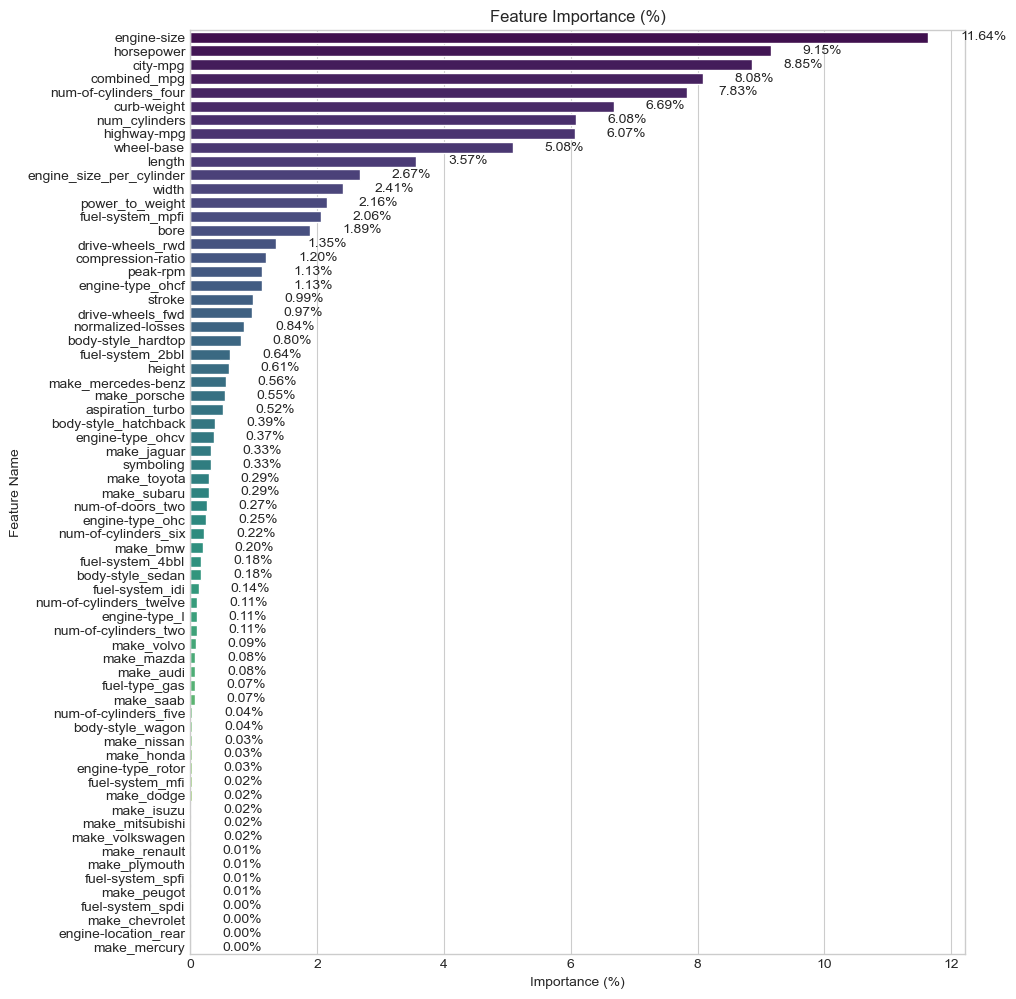

In [82]:
important_feature_rf=plot_feature_importance(best_rf_model,X_train.columns)

- Cross validation for tuned random forest


In [97]:
from sklearn.model_selection import cross_val_score

cv_mse = -cross_val_score(best_rf_model, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.06225874 0.0997847  0.04455089 0.03054124 0.12974158 0.08594429
 0.04381038 0.10196157 0.03188747 0.26813018]
MSE standard deviation  0.06741358901952416
Mean MSE: 0.08986110619621676
Mean RMSE: 0.2997684209455972


In [83]:
import pandas as pd


y_test_array = y_test.to_numpy().flatten() if hasattr(y_test, "to_numpy") else y_test.flatten()
y_pred_array = y_pred_rf_tuned.to_numpy().flatten() if hasattr(y_pred_rf_tuned, "to_numpy") else y_pred_rf_tuned.flatten()


df_comparison = pd.DataFrame({
    'Actual': y_test_original_scale,
    'Predicted': y_pred_rf_tuned_not_scaled
})

print(df_comparison)



     Actual     Predicted
0   30760.0  28474.120000
1    9549.0   9321.389333
2   11850.0  14212.730000
3   28248.0  25752.780000
4    7799.0   6820.236641
5    7788.0   8196.151111
6    9258.0   7831.047024
7   10198.0   9614.228000
8    7775.0   7995.320000
9   13295.0  16454.501818
10   8238.0   8177.780000
11  18280.0  16518.145152
12   9988.0  10740.610667
13  40960.0  37520.460000
14   6488.0   6518.859167
15   5151.0   7970.000000
16  12629.0  14041.304000
17   8189.0   8169.446667
18   9960.0   9420.468000
19   8495.0  10449.814667
20  13499.0  16720.100000
21   8249.0   7042.223308
22   6479.0   6385.066667
23   6692.0   7310.366667
24  41315.0  28997.900000
25   9639.0   9868.121905
26  13415.0  16682.330000
27   7999.0   7298.856245
28  12940.0  16680.130000
29  25552.0  25613.830000
30   6229.0   6357.150000
31   7898.0   8107.480000
32  21485.0  20322.900000
33   7689.0   8166.348000
34  28176.0  24644.570000
35  11259.0  10281.388000
36  10945.0  12523.106667
37  14489.0 

### Conclusion: Choosing the Best Model

#### **Notes**

- The **default RandomForest model** has **lower training MSE & higher R²**, but it **overfits** (performs worse in cross-validation).
- The **tuned RandomForest model** has **higher training error** but **better cross-validation results** (lower mean MSE, RMSE, and standard deviation).
- **Lower MSE standard deviation** in the tuned model means it is **more stable** across different dataset splits.
- **Compared to Decision Trees (both untuned and tuned), Random Forest achieved better accuracy and stability** in all cases.

**Final Choice**:  
The **Tuned RandomForestRegressor** is the best model as it balances performance and stability, making it **more reliable for real-world use**.
